# Market-Wide Liquidity Stress and Return Predictability in Cryptocurrency Markets

This notebook contains the final empirical analysis for the thesis. It implements the final cleaned analysis sample, constructs liquidity measures and stress labels, estimates market-wide liquidity factors, tests the relationship between liquidity stress and crash days, evaluates next-day stress and return-direction prediction, and translates predicted stress probabilities into an early-warning liquidity-risk framework.

The notebook is organized according to the thesis research questions:
- RQ1: Liquidity measurement and market-wide liquidity stress
- RQ2: Liquidity stress and large negative return events
- RQ3: Prediction, early-warning use, and managerial relevance

---
## 0. Imports & Global Settings

In [4]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    roc_auc_score,)
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import statsmodels.api as sm

try:
    from xgboost import XGBClassifier
    USE_XGB = True
except ImportError:
    XGBClassifier = None
    USE_XGB = False

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,})


# ===== CONFIG =====
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'processed' / 'analysis_panel.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'processed'
FIG_DIR = PROJECT_ROOT / 'notebooks'
DATA_PATH = PROCESSED / 'analysis_panel.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find analysis_panel.csv at {DATA_PATH}. '
        'Run this notebook from the project root or notebooks directory.'
    )
FIG_DIR.mkdir(exist_ok=True)

print('Settings loaded.')
print(f'Project root: {PROJECT_ROOT}')
if not USE_XGB:
    print('xgboost is not installed; using RandomForestClassifier for tree models.')

Settings loaded.
Project root: c:\Users\P.Gocheva\Desktop\thesis


---
## 1. Data Inspection

In [5]:
# Load pre-built analysis panel
raw = pd.read_csv(DATA_PATH, parse_dates=['date'], low_memory=False)
raw['cmc_id'] = pd.to_numeric(raw['cmc_id'], errors='coerce').astype('Int64')

required_raw_cols = ['date', 'cmc_id', 'category', 'in_sample', 'raised_usd']
missing_raw_cols = [c for c in required_raw_cols if c not in raw.columns]
if missing_raw_cols:
    raise KeyError(f'analysis_panel.csv is missing required columns: {missing_raw_cols}')

print(f'Raw shape : {raw.shape}')
print(f'Date range: {raw["date"].min().date()} -> {raw["date"].max().date()}')
print(f'Assets    : {raw["cmc_id"].nunique()} unique cmc_id')

# Filter to in-sample observations
df_clean = raw[raw['in_sample'] == 1].copy()
df_clean = df_clean.sort_values(['cmc_id', 'date']).reset_index(drop=True)

print(f'In-sample rows: {len(df_clean):,} | {df_clean["cmc_id"].nunique()} assets')

# Compatibility aliases
df_clean['symbol'] = df_clean['cmc_id'].astype(str)
df_clean['cat'] = df_clean['category'].str.strip().str.lower()
df_clean['cat'] = df_clean['cat'].where(df_clean['cat'].isin(['coin', 'token']), 'other')

n_before_cat = len(df_clean)
df_clean = df_clean[df_clean['cat'].isin(['coin', 'token'])].copy()
print(f'Rows dropped (no CMC category): {n_before_cat - len(df_clean):,}')
print(f'Final sample: {len(df_clean):,} rows | {df_clean["cmc_id"].nunique()} assets')
print(f'Date range  : {df_clean["date"].min().date()} -> {df_clean["date"].max().date()}')


# Category breakdown: what tokens were excluded at Stage 4?
_pre_cat = raw[raw['in_sample'] == 1].drop_duplicates('cmc_id')[['cmc_id', 'category']].copy()
_pre_cat['_cat'] = _pre_cat['category'].fillna('(missing)').str.strip().str.lower()
_excl = _pre_cat.loc[~_pre_cat['_cat'].isin(['coin', 'token']), '_cat'].value_counts()
if len(_excl) > 0:
    print('Category breakdown -- tokens excluded at Stage 4 (not coin or token):')
    print(_excl.to_string())
else:
    print('All in-sample tokens are classified as coin or token.')
print()

df_clean['amihud_raw'] = df_clean['amihud_med30']
df_clean['turnover'] = df_clean['turnover_med30']
df_clean['vol20'] = df_clean['volatility_20d']
df_clean['stress_strict'] = df_clean['stress_amihud_strict']

# Corwin-Schultz spread, falling back to the older range-based proxy if needed.
if 'cs_spread_30d' in df_clean.columns and df_clean['cs_spread_30d'].notna().mean() > 0.05:
    df_clean['spread_proxy'] = df_clean['cs_spread_30d']
    _spread_note = 'cs_spread_30d (Corwin-Schultz 2012)'
else:
    df_clean['spread_proxy'] = df_clean['spread_med30']
    _spread_note = 'spread_med30 (range-based fallback; rebuild panel for CS)'

# Amivest and Pastor-Stambaugh gamma are optional Phase 2 columns.
df_clean['amivest'] = df_clean['amivest_30d'] if 'amivest_30d' in df_clean.columns else np.nan
df_clean['ps_gamma'] = df_clean['ps_gamma'] if 'ps_gamma' in df_clean.columns else np.nan

# Prefer the PCA market factor when available; otherwise use the Amihud z-score factor.
if 'mkt_illiq_pc1' in df_clean.columns and df_clean['mkt_illiq_pc1'].notna().mean() > 0.05:
    df_clean['mkt_factor_pc1'] = df_clean['mkt_illiq_pc1']
    _pc1_note = 'mkt_illiq_pc1 (PCA factor, Phase 2 F)'
    _mkt_factor_name = 'PCA market illiquidity factor'
else:
    df_clean['mkt_factor_pc1'] = df_clean['mkt_illiq_factor']
    _pc1_note = 'mkt_illiq_factor (Amihud fallback; rebuild panel for PCA)'
    _mkt_factor_name = 'Amihud z-score market illiquidity factor'

# Flag observations where market cap was not reported by CoinMarketCap.
# 18.4% of in-sample obs have market_cap=0; log_mcap=log1p(0)=0 for these.
# The flag separates the 'unreported market cap' signal from the size signal.
df_clean['mcap_unknown'] = (df_clean['market_cap'] == 0).astype(float)
print(f'mcap_unknown: {df_clean["mcap_unknown"].mean()*100:.1f}% of obs have market_cap=0')

df_clean['log_raised_usd'] = np.log1p(
    pd.to_numeric(df_clean['raised_usd'], errors='coerce').clip(lower=0).fillna(0)
)

mkt_factor = (
    df_clean[['date', 'mkt_factor_pc1']]
    .dropna(subset=['mkt_factor_pc1'])
    .drop_duplicates('date')
    .sort_values('date')
    .rename(columns={'mkt_factor_pc1': 'mkt_factor'})
    .reset_index(drop=True)
)

print('\nColumn aliases:')
print(f'  spread_proxy   <- {_spread_note}')
print(f'  mkt_factor_pc1 <- {_pc1_note}')
print('Column coverage (% non-NaN):')
for col in ['amihud_raw', 'turnover', 'spread_proxy', 'vol20', 'stress_strict',
            'amivest', 'ps_gamma', 'mkt_factor_pc1']:
    pct = df_clean[col].notna().mean() * 100 if col in df_clean.columns else 0.0
    print(f'  {col:<22}: {pct:.1f}%')
print(f'  mkt_factor: {len(mkt_factor)} daily observations ({_mkt_factor_name})')

Raw shape : (319174, 66)
Date range: 2024-02-13 -> 2026-03-30
Assets    : 531 unique cmc_id
In-sample rows: 231,354 | 420 assets
Rows dropped (no CMC category): 38,784
Final sample: 192,570 rows | 295 assets
Date range  : 2024-04-02 -> 2026-03-30
Category breakdown -- tokens excluded at Stage 4 (not coin or token):
_cat
(missing)    125

mcap_unknown: 18.4% of obs have market_cap=0

Column aliases:
  spread_proxy   <- cs_spread_30d (Corwin-Schultz 2012)
  mkt_factor_pc1 <- mkt_illiq_pc1 (PCA factor, Phase 2 F)
Column coverage (% non-NaN):
  amihud_raw            : 99.9%
  turnover              : 81.7%
  spread_proxy          : 100.0%
  vol20                 : 100.0%
  stress_strict         : 74.3%
  amivest               : 99.9%
  ps_gamma              : 81.5%
  mkt_factor_pc1        : 100.0%
  mkt_factor: 727 daily observations (PCA market illiquidity factor)


In [6]:
# ------ Panel coverage check --------
key_cols = ['date','cmc_id','symbol','category','open','high','low','close','volume','market_cap']
miss = df_clean[key_cols].isnull().sum().rename('missing')
miss_pct = (miss / len(df_clean) * 100).rename('missing_%')
print('=== Core column missingness (in-sample) ===')
print(pd.concat([miss, miss_pct], axis=1).to_string())

print()
print('Observations by category:')
print(df_clean.groupby('cat').agg(obs=('cmc_id','count'), assets=('cmc_id','nunique')))
print()
print('Stress / crash label prevalence:')
print(f'  stress_amihud        : {df_clean["stress_amihud"].mean()*100:.2f}%')
print(f'  stress_amihud_strict : {df_clean["stress_strict"].mean()*100:.2f}%')
print(f'  crash                : {df_clean["crash"].mean()*100:.2f}%')

=== Core column missingness (in-sample) ===
            missing  missing_%
date              0        0.0
cmc_id            0        0.0
symbol            0        0.0
category          0        0.0
open              0        0.0
high              0        0.0
low               0        0.0
close             0        0.0
volume            0        0.0
market_cap        0        0.0

Observations by category:
          obs  assets
cat                  
coin    56868      83
token  135702     212

Stress / crash label prevalence:
  stress_amihud        : 27.28%
  stress_amihud_strict : 11.40%
  crash                : 10.41%


---
## 2. Variable Construction

> All variables were pre-computed in `05_build_analysis_panel.ipynb` using
> expanding-window quantiles (no look-ahead bias) and saved to `analysis_panel.csv`.
> The cells above load the panel and create backward-compatible column aliases.
> The sections below proceed directly to analysis.

Monthly in-sample coverage:
     ym  obs  assets
2024-04 7983     278
2024-05 8595     281
2024-06 8423     282
2024-07 8681     284
2024-08 8790     286
2024-09 8565     286
2024-10 8815     286
2024-11 8485     286
2024-12 8871     288
2025-01 8723     285
2025-02 7858     285
2025-03 8528     283
2025-04 7954     270
2025-05 8089     266
2025-06 7688     262
2025-07 7840     255
2025-08 7834     257
2025-09 7504     253
2025-10 7718     252
2025-11 7377     252
2025-12 7503     247
2026-01 7459     244
2026-02 6581     241
2026-03 6706     238


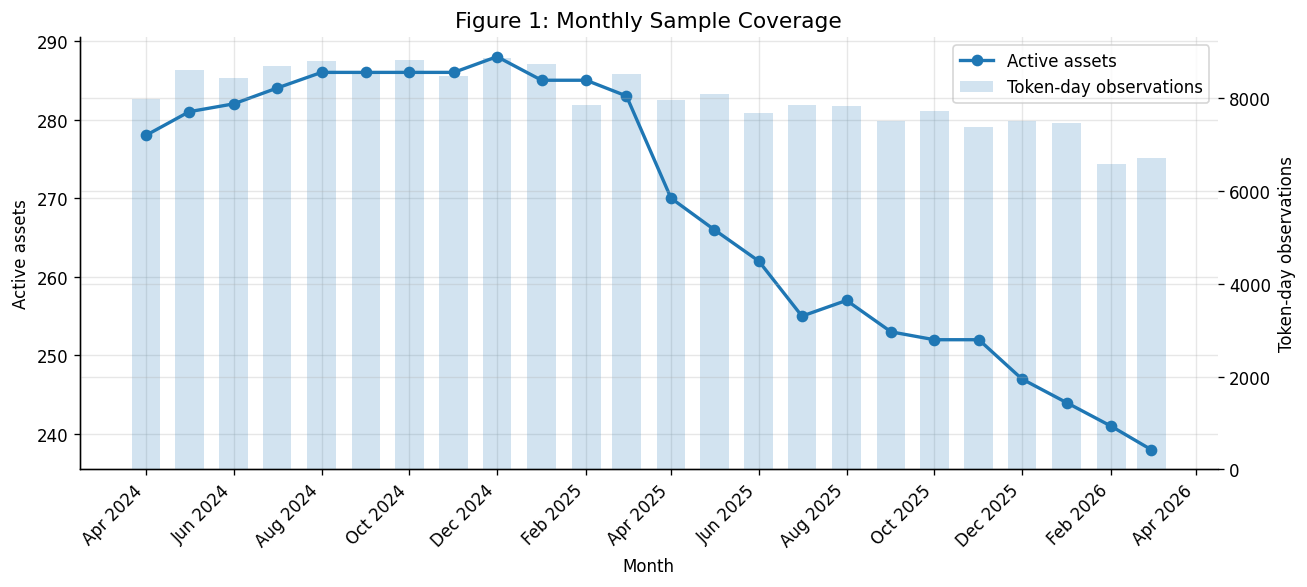

Saved: fig1_monthly_sample_coverage.png


In [7]:
# ---------------------------------------------------------------------
# Figure 1: Monthly Sample Coverage
# ---------------------------------------------------------------------
# Recreate monthly coverage from the final cleaned estimation sample
source_df = globals().get('df_clean')
if source_df is None:
    raise NameError("df_clean is not defined. Run the data-loading / cleaning cell first.")

monthly = (
    source_df
    .assign(ym=source_df["date"].dt.to_period("M"))
    .groupby("ym")
    .agg(obs=("cmc_id", "count"), assets=("cmc_id", "nunique"))
    .reset_index()
)

# Convert monthly period to timestamp for plotting
monthly["month"] = monthly["ym"].dt.to_timestamp()

# Print table for verification
print("Monthly in-sample coverage:")
print(monthly[["ym", "obs", "assets"]].to_string(index=False))

# Plot active assets over time
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    monthly["month"],
    monthly["assets"],
    marker="o",
    linewidth=2,
    label="Active assets"
)

ax1.set_title("Figure 1: Monthly Sample Coverage", fontsize=13)
ax1.set_xlabel("Month")
ax1.set_ylabel("Active assets")
ax1.grid(True, alpha=0.3)

# Second axis for observations
ax2 = ax1.twinx()
ax2.bar(
    monthly["month"],
    monthly["obs"],
    width=20,
    alpha=0.20,
    label="Token-day observations"
)
ax2.set_ylabel("Token-day observations")

# Format x-axis
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()

# Save figure
plt.savefig(FIG_DIR / "fig1_monthly_sample_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig1_monthly_sample_coverage.png")

---
## 3. RQ1 Results --- Liquidity Measurement & Market-Wide Factor

### RQ1.1 --- Proxy Distributions, Time-Series, and Category Comparisons

In [8]:
# ------ Table 1: Summary statistics --- main continuous variables --------
# Winsorise ret and vol20 at 1/99 pct for display (same bounds as liquidity proxies).
# df_clean is not modified --- this is display-only.
_disp = df_clean[['ret','log_mcap','amihud_raw','turnover','spread_proxy','vol20']].copy()
for _col in ['ret', 'vol20']:
    _lo = _disp[_col].quantile(0.01)
    _hi = _disp[_col].quantile(0.99)
    _disp[_col] = _disp[_col].clip(_lo, _hi)

_labels = {
    'ret':          'Daily Return',
    'log_mcap':     'Log Market Cap',
    'amihud_raw':   'Amihud Illiquidity',
    'turnover':     'Turnover',
    'spread_proxy': 'CS Spread (Corwin-Schultz 2012)',
    'vol20':        'Volatility (20-day std)',
}

_pcts = [0.10, 0.25, 0.50, 0.75, 0.90]
rows = []
for col, lbl in _labels.items():
    s = _disp[col].dropna()
    rows.append({
        'Variable':   lbl,
        'Obs':        f'{len(s):,}',
        'Mean':       s.mean(),
        'Std Dev':    s.std(),
        'p10':        s.quantile(0.10),
        'p25':        s.quantile(0.25),
        'Median':     s.median(),
        'p75':        s.quantile(0.75),
        'p90':        s.quantile(0.90),
    })

import pandas as _pd
_tbl = _pd.DataFrame(rows).set_index('Variable')

# per-variable decimal places
_dp = {
    'Daily Return':              4,
    'Log Market Cap':            2,
    'Amihud Illiquidity':        6,
    'Turnover':                  4,
    'CS Spread (Corwin-Schultz 2012)':4,
    'Volatility (20-day std)':   4,
}
for _lbl, _dec in _dp.items():
    for _stat in ['Mean','Std Dev','p10','p25','Median','p75','p90']:
        _tbl.loc[_lbl, _stat] = round(float(_tbl.loc[_lbl, _stat]), _dec)

print('=== Table 1: Summary Statistics --- Main Continuous Variables ===')
print(f'Sample: {len(df_clean):,} obs, {df_clean["symbol"].nunique()} assets, '
      f'{df_clean["date"].min().date()} to {df_clean["date"].max().date()}')
print('(Daily Return and Volatility winsorised at 1st/99th pct for display.)')
print()
print(_tbl.to_string())
print()
print('Notes: Amihud = |ret|/USD volume. Turnover = USD volume/market cap.')
print('CS Spread = Corwin-Schultz (2012) estimator from consecutive OHLC pairs. All liquidity variables winsorised at 1st/99th pct.')
print('Volatility = 20-day rolling std of daily returns (min 10 obs).')

=== Table 1: Summary Statistics --- Main Continuous Variables ===
Sample: 192,570 obs, 295 assets, 2024-04-02 to 2026-03-30
(Daily Return and Volatility winsorised at 1st/99th pct for display.)

                                     Obs       Mean   Std Dev     p10      p25   Median        p75        p90
Variable                                                                                                     
Daily Return                     192,570  -0.000500  0.072700 -0.0644  -0.0285  -0.0014   0.021000   0.060100
Log Market Cap                   192,570  13.830000  7.070000  0.0000  13.0900  16.2400  18.350000  20.000000
Amihud Illiquidity               192,398   0.000205  0.001106  0.0000   0.0000   0.0000   0.000002   0.000119
Turnover                         157,278   0.095800  0.179100  0.0018   0.0128   0.0430   0.102400   0.209900
CS Spread (Corwin-Schultz 2012)  192,567   0.018000  0.032100  0.0005   0.0047   0.0105   0.018400   0.033000
Volatility (20-day std)          19

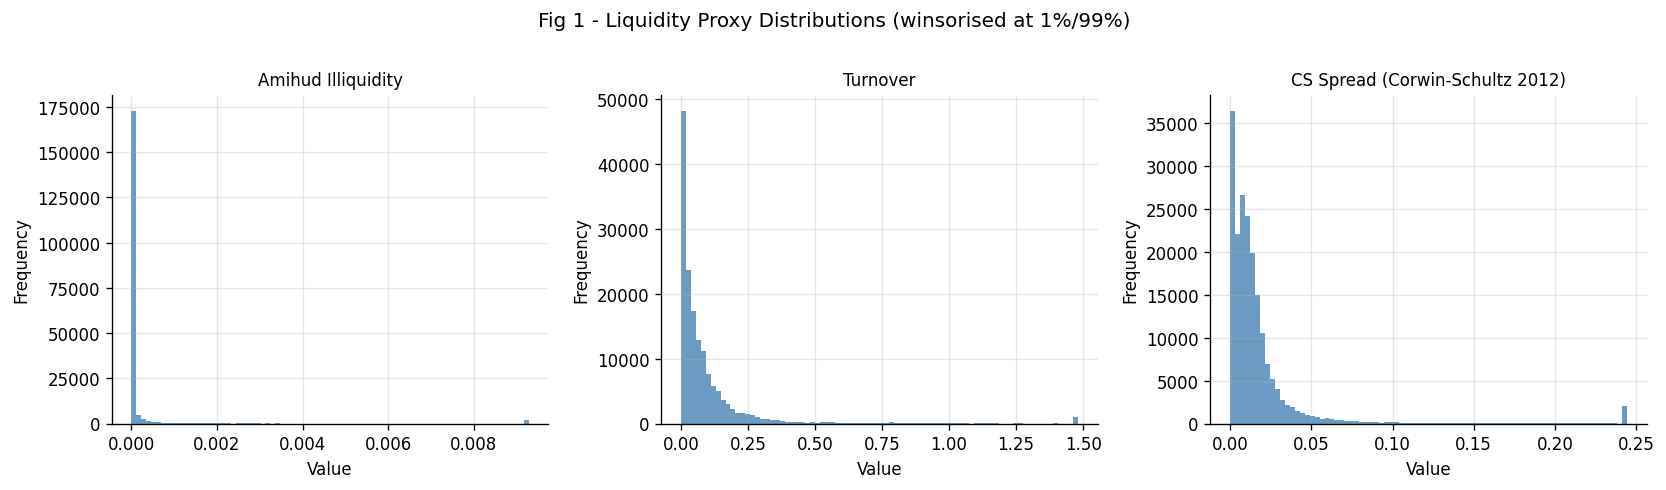

Saved: fig1_proxy_distributions.png


In [9]:
# ------ Histograms (liquidity proxies only) --------
liq_cols = ['amihud_raw', 'turnover', 'spread_proxy']
liq_labels = ['Amihud Illiquidity', 'Turnover', 'CS Spread (Corwin-Schultz 2012)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes, liq_cols, liq_labels):
    df_clean[col].dropna().hist(bins=80, ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
fig.suptitle('Fig 1 - Liquidity Proxy Distributions (winsorised at 1%/99%)', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_proxy_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: fig1_proxy_distributions.png')

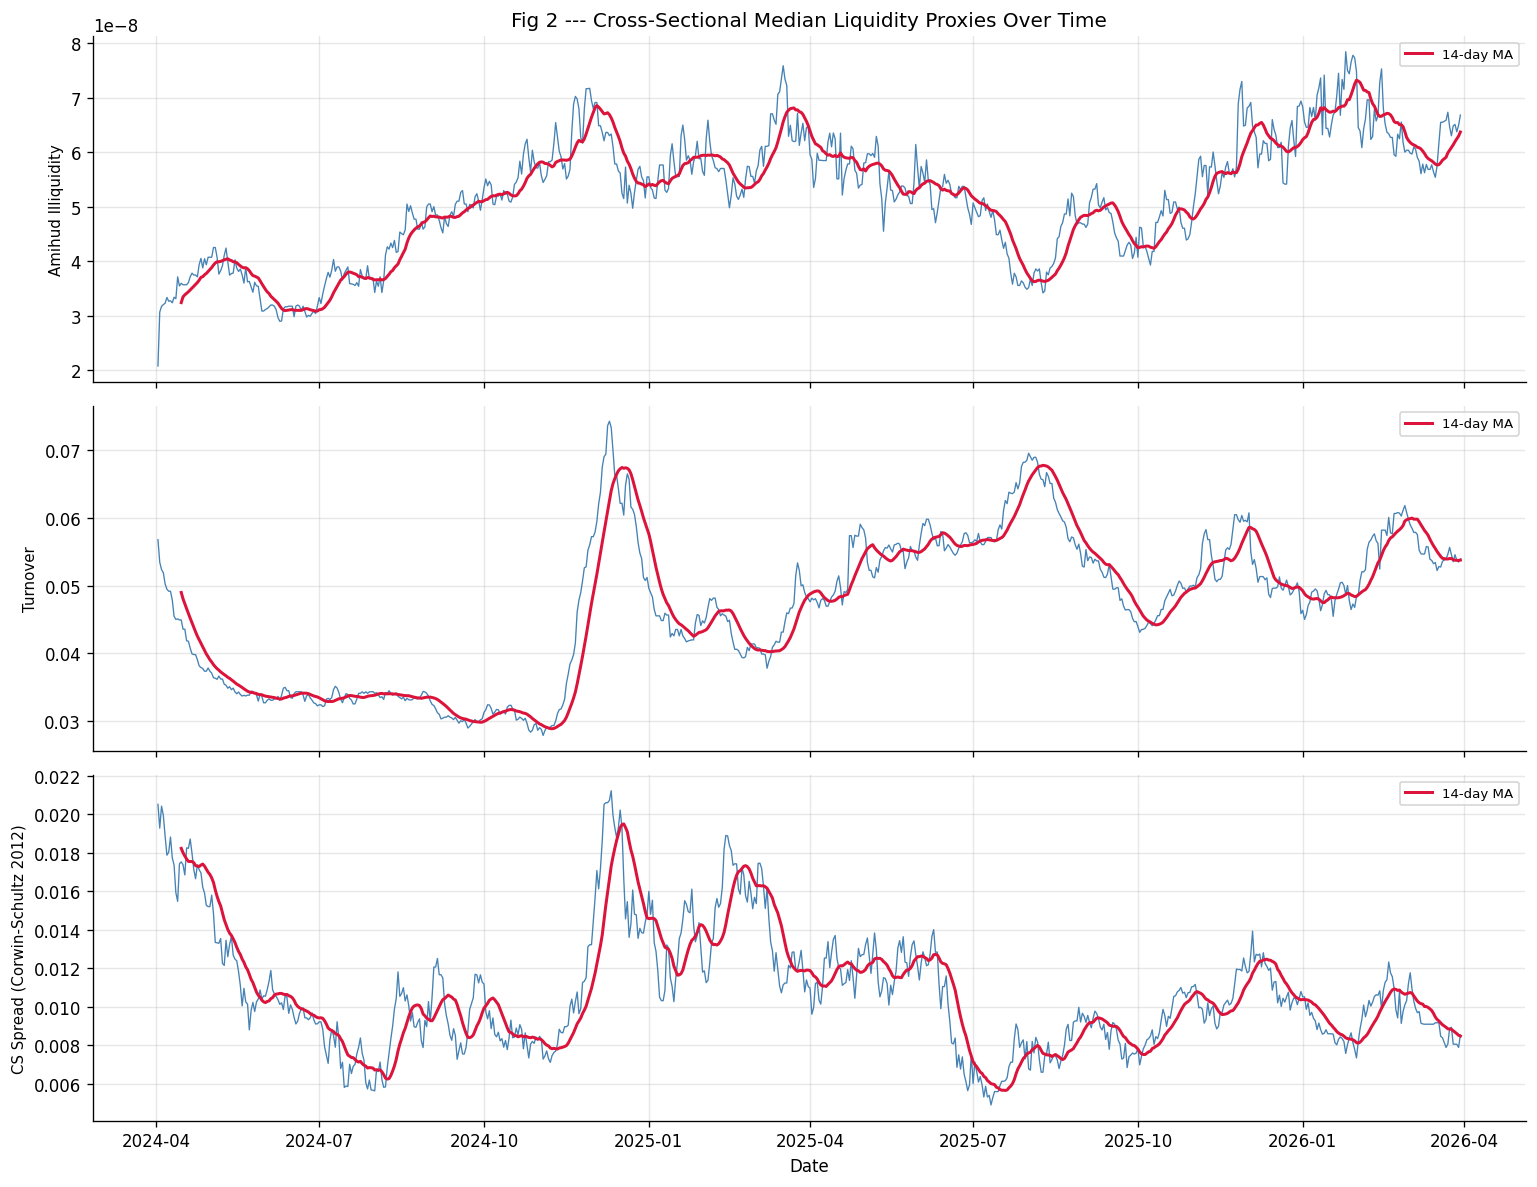

Saved: fig2_ts_medians.png


In [10]:
# ------ Time-series of cross-sectional medians --------
ts = (df_clean.groupby('date')[liq_cols]
              .median()
              .reset_index())

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, col, label in zip(axes, liq_cols, liq_labels):
    ax.plot(ts['date'], ts[col], lw=0.8, color='steelblue')
    # smooth trend
    ax.plot(ts['date'], ts[col].rolling(14).mean(), lw=1.8, color='crimson', label='14-day MA')
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
axes[0].set_title('Fig 2 --- Cross-Sectional Median Liquidity Proxies Over Time')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_ts_medians.png', bbox_inches='tight')
plt.show()
print('Saved: fig2_ts_medians.png')

In [62]:
# ------ Category-level comparison --------
cat_table = (df_clean.groupby('cat')[liq_cols]
                     .agg(['median','mean','std'])
                     .round(6))
print('=== Table 2: Liquidity Proxies by Category ===')
print(cat_table.to_string())


df_clean["market_cap_pos"] = df_clean["market_cap"].where(df_clean["market_cap"] > 0)

mcap_final_sample = (
    df_clean
    .groupby("cat")
    .agg(
        token_days=("cmc_id", "count"),
        assets=("cmc_id", "nunique"),
        obs_with_mcap=("market_cap_pos", "count"),
        mean_mcap=("market_cap_pos", "mean"),
        median_mcap=("market_cap_pos", "median"),
        p25_mcap=("market_cap_pos", lambda x: x.quantile(0.25)),
        p75_mcap=("market_cap_pos", lambda x: x.quantile(0.75)),
    )
)

print(mcap_final_sample.round(0).to_string())


# ------ Appendix F, Table F.2: Coin vs Token Liquidity Proxy Comparison --------
rows = []

for col, label in zip(liq_cols, liq_labels):
    coin_vals = df_clean.loc[df_clean["cat"] == "coin", col].dropna()
    token_vals = df_clean.loc[df_clean["cat"] == "token", col].dropna()

    t_stat, p_val = stats.ttest_ind(token_vals, coin_vals, equal_var=False)

    rows.append({
        "Variable": label,
        "Coin mean": coin_vals.mean(),
        "Token mean": token_vals.mean(),
        "Coin median": coin_vals.median(),
        "Token median": token_vals.median(),
        "Difference: Token - Coin": token_vals.mean() - coin_vals.mean(),
        "Welch t-stat": t_stat,
        "p-value": p_val,
        "N coin": len(coin_vals),
        "N token": len(token_vals),
    })

table_f2 = pd.DataFrame(rows).set_index("Variable")

print("=== Appendix F, Table F.2: Liquidity Proxies by Asset Category ===")
print(table_f2.round(6).to_string())


# ------ Appendix F, Table F.2: Coin vs Token Liquidity Proxy Comparison --------
rows = []

for col, label in zip(liq_cols, liq_labels):
    coin_vals = df_clean.loc[df_clean["cat"] == "coin", col].dropna()
    token_vals = df_clean.loc[df_clean["cat"] == "token", col].dropna()

    t_stat, p_val = stats.ttest_ind(token_vals, coin_vals, equal_var=False)

    rows.append({
        "Variable": label,
        "Coin mean": coin_vals.mean(),
        "Token mean": token_vals.mean(),
        "Coin median": coin_vals.median(),
        "Token median": token_vals.median(),
        "Difference: Token - Coin": token_vals.mean() - coin_vals.mean(),
        "Welch t-stat": t_stat,
        "p-value": p_val,
        "N coin": len(coin_vals),
        "N token": len(token_vals),
    })

table_f2 = pd.DataFrame(rows).set_index("Variable")

print("=== Appendix F, Table F.2: Liquidity Proxies by Asset Category ===")
print(table_f2.round(6).to_string())

=== Table 2: Liquidity Proxies by Category ===
      amihud_raw                      turnover                     spread_proxy                    
          median      mean       std    median      mean       std       median      mean       std
cat                                                                                                
coin         0.0  0.000162  0.001127  0.046854  0.087527  0.144158     0.009919  0.016455  0.030448
token        0.0  0.000224  0.001096  0.040078  0.099826  0.193849     0.010777  0.018605  0.032794
       token_days  assets  obs_with_mcap     mean_mcap  median_mcap   p25_mcap     p75_mcap
cat                                                                                        
coin        56868      83          51826  8.531330e+09   57498214.0  6507516.0  548252467.0
token      135702     212         105400  1.737578e+08   18187503.0  2387519.0   85823323.0
=== Appendix F, Table F.2: Liquidity Proxies by Asset Category ===
                  

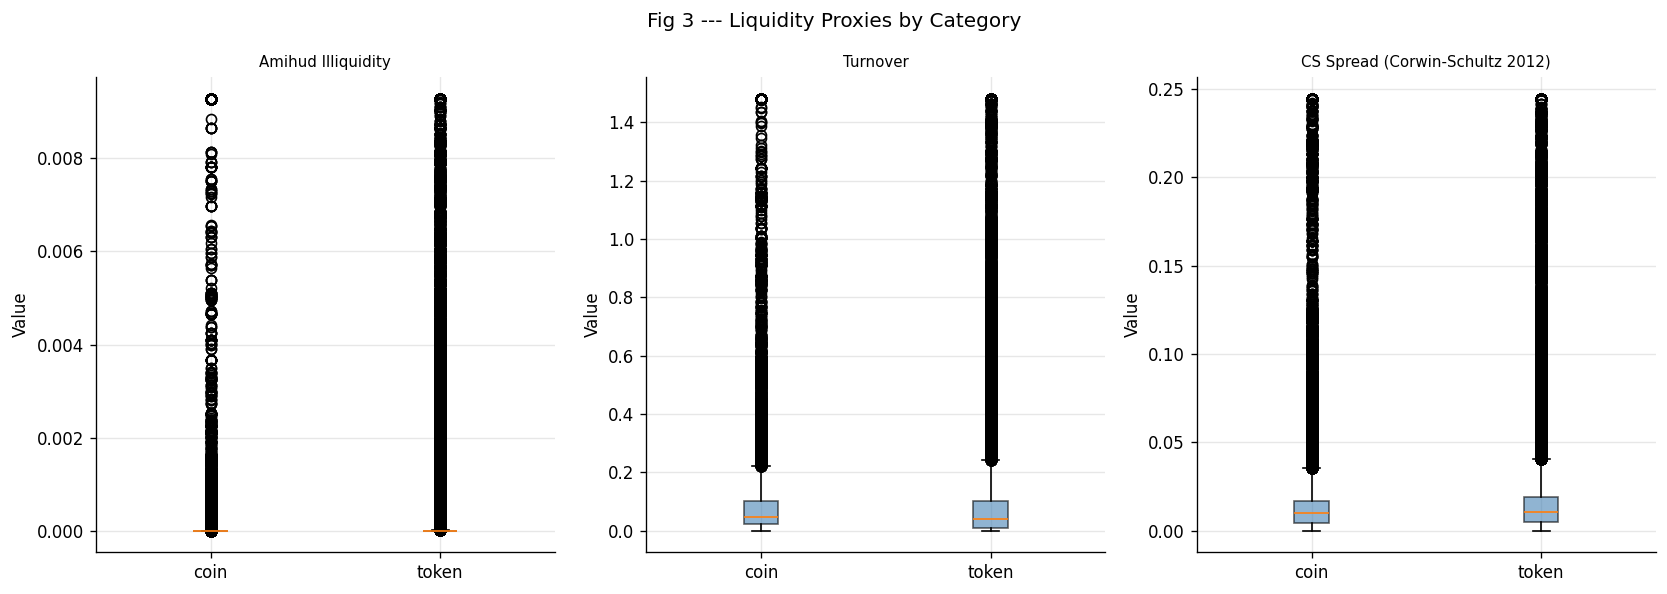

Saved: fig3_category_boxplots.png


In [12]:
# ------ Boxplots by category --------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, label in zip(axes, liq_cols, liq_labels):
    groups = [df_clean.loc[df_clean['cat'] == c, col].dropna() for c in ['coin','token']]
    groups = [g for g in groups if len(g) > 0]
    cats_present = [c for c in ['coin','token'] if df_clean.loc[df_clean['cat']==c, col].notna().any()]
    ax.boxplot(groups, labels=cats_present, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('Value')
fig.suptitle('Fig 3 --- Liquidity Proxies by Category')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_category_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: fig3_category_boxplots.png')

### RQ1.2 --- Liquidity Stress Label

In [13]:
# ------ Overall stress frequency --------
print('=== Table 3: Stress Frequency ===')
print(f'stress_amihud  (top-10% Amihud)              : {df_clean["stress_amihud"].mean()*100:.2f}%')
if df_clean['stress_strict'].notna().sum() > 0:
    print(f'stress_strict  (top-10% Amihud & bot-10% TO) : {df_clean["stress_strict"].mean()*100:.2f}%')
print()
print('Stress frequency by category:')
print(df_clean.groupby('cat')['stress_strict'].mean().mul(100).round(2).rename('stress_strict_%').to_frame())

=== Table 3: Stress Frequency ===
stress_amihud  (top-10% Amihud)              : 27.28%
stress_strict  (top-10% Amihud & bot-10% TO) : 11.40%

Stress frequency by category:
       stress_strict_%
cat                   
coin              9.41
token            12.39


In [ ]:
# Stressed vs non-stressed comparison
compare_cols = ['log_mcap', 'turnover', 'vol20', 'ret', 'spread_proxy']
compare_labels = ['Log Market Cap', 'Turnover', 'Volatility (20d)', 'Return', 'Spread Proxy']

rows = []
for col, lbl in zip(compare_cols, compare_labels):
    stressed = df_clean.loc[df_clean['stress_strict'] == 1, col].dropna()
    not_stressed = df_clean.loc[df_clean['stress_strict'] == 0, col].dropna()
    if len(stressed) > 1 and len(not_stressed) > 1:
        t_stat, p_val = stats.ttest_ind(stressed, not_stressed, equal_var=False)
    else:
        t_stat, p_val = np.nan, np.nan
    rows.append({
        'Variable': lbl,
        'Not Stressed (mean)': not_stressed.mean(),
        'Stressed (mean)': stressed.mean(),
        'Diff': stressed.mean() - not_stressed.mean(),
        't-stat': t_stat,
        'p-value': p_val,
    })

compare_tbl = pd.DataFrame(rows).set_index('Variable')
print('=== Table 4: Stressed vs Non-Stressed Days (Welch t-test) ===')
print(compare_tbl.round(4).to_string())



=== Table 4: Stressed vs Non-Stressed Days (Welch t-test) ===
                  Not Stressed (mean)  Stressed (mean)    Diff   t-stat  p-value
Variable                                                                        
Log Market Cap                17.0123          15.7720 -1.2403 -55.9062   0.0000
Turnover                       0.1047           0.0340 -0.0707 -70.3568   0.0000
Volatility (20d)               0.0685           0.0939  0.0254  22.4414   0.0000
Return                        -0.0008           0.0007  0.0015   2.0458   0.0408
Spread Proxy                   0.0156           0.0222  0.0066  21.2966   0.0000


In [15]:
# ------ Diagnostic: distribution of ret and vol20 by stress group --------

for col, label in [('ret', 'Daily Return (raw panel, decimal)'),
                   ('vol20', 'Volatility 20d (alias for volatility_20d)')]:
    s  = df_clean.loc[df_clean['stress_strict'] == 1,  col].dropna()
    ns = df_clean.loc[df_clean['stress_strict'] == 0,  col].dropna()
    print(f"=== {label} ===")
    print(f"  Non-stressed  n={len(ns):,}  mean={ns.mean():.6f}  "
          f"median={ns.median():.6f}  std={ns.std():.6f}")
    print(f"  Stressed      n={len(s):,}   mean={s.mean():.6f}  "
          f"median={s.median():.6f}  std={s.std():.6f}")
    pcts = [0, 1, 5, 25, 50, 75, 95, 99, 100]
    print(f"  {'Pct':>5}  {'Non-stressed':>15}  {'Stressed':>15}")
    for p in pcts:
        print(f"  {p:>5}  {ns.quantile(p/100):>15.6f}  {s.quantile(p/100):>15.6f}")
    print()

print("=== volatility_20d (raw panel column, before alias) ===")
for label, mask in [('Non-stressed', df_clean['stress_strict'] == 0),
                    ('Stressed',     df_clean['stress_strict'] == 1)]:
    v = df_clean.loc[mask, 'volatility_20d'].dropna()
    print(f"  {label:15s}  n={len(v):,}  mean={v.mean():.6f}  "
          f"p01={v.quantile(0.01):.6f}  p50={v.median():.6f}  "
          f"p99={v.quantile(0.99):.6f}  max={v.max():.6f}")

=== Daily Return (raw panel, decimal) ===
  Non-stressed  n=126,776  mean=-0.000797  median=-0.001960  std=0.070974
  Stressed      n=16,316   mean=0.000722  median=-0.001852  std=0.091342
    Pct     Non-stressed         Stressed
      0        -0.291304        -0.291304
      1        -0.210146        -0.291304
      5        -0.092116        -0.122697
     25        -0.028891        -0.032186
     50        -0.001960        -0.001852
     75         0.021253         0.024122
     95         0.094868         0.136895
     99         0.293606         0.404163
    100         0.404163         0.404163

=== Volatility 20d (alias for volatility_20d) ===
  Non-stressed  n=126,776  mean=0.068468  median=0.046405  std=0.092314
  Stressed      n=16,316   mean=0.093879  median=0.048940  std=0.140797
    Pct     Non-stressed         Stressed
      0         0.001330         0.001330
      1         0.004935         0.009715
      5         0.018487         0.020179
     25         0.033709    

Correlation: stress_rate vs log_mcap = -0.3317  (p=1.9233e-07)
Interpretation: r = -0.3317 (negative --- smaller assets are stressed more often)


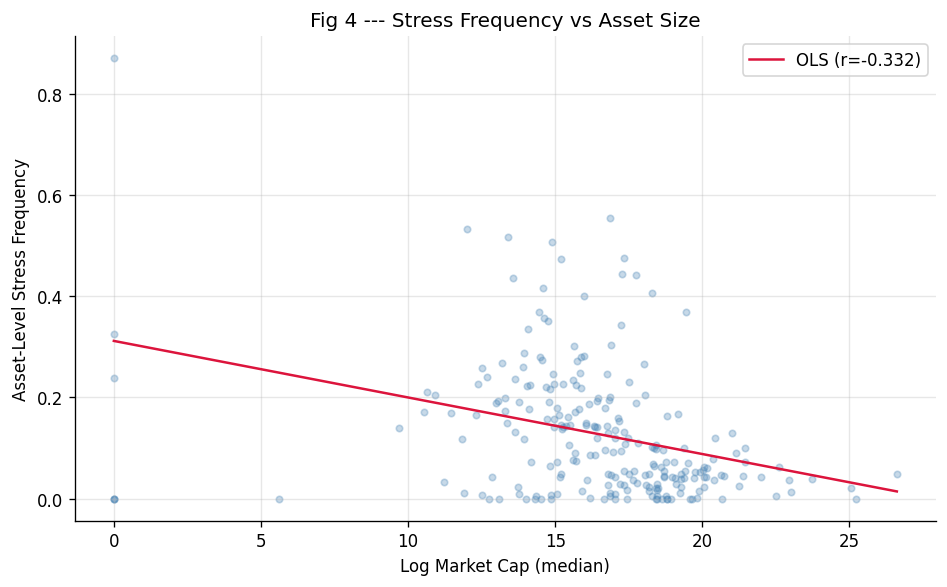

In [16]:
# ------ Does asset size predict stress frequency? --------
asset_stress_freq = (df_clean.groupby('symbol')
                             .agg(stress_rate=('stress_strict','mean'),
                                  log_mcap=('log_mcap','median'))
                             .dropna())

r, p = stats.pearsonr(asset_stress_freq['log_mcap'], asset_stress_freq['stress_rate'])
print(f'Correlation: stress_rate vs log_mcap = {r:.4f}  (p={p:.4e})')
interp = 'negative --- smaller assets are stressed more often' if r < -0.05 else ('positive --- larger assets are stressed more often' if r > 0.05 else 'near zero --- no clear size effect')
print(f'Interpretation: r = {r:.4f} ({interp})')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(asset_stress_freq['log_mcap'], asset_stress_freq['stress_rate'],
           alpha=0.3, s=15, color='steelblue')
# OLS trend line
m, b = np.polyfit(asset_stress_freq['log_mcap'], asset_stress_freq['stress_rate'], 1)
xr = np.linspace(asset_stress_freq['log_mcap'].min(), asset_stress_freq['log_mcap'].max(), 100)
ax.plot(xr, m*xr + b, color='crimson', lw=1.5, label=f'OLS (r={r:.3f})')
ax.set_xlabel('Log Market Cap (median)')
ax.set_ylabel('Asset-Level Stress Frequency')
ax.set_title('Fig 4 --- Stress Frequency vs Asset Size')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_stress_vs_size.png', bbox_inches='tight')
plt.show()

In [17]:
# ------ ICO-era features: stress frequency and size by project characteristics --------
# PILOT NOTE: ICO columns are static asset-level metadata from token_day_panel.
# We use them to describe cross-sectional heterogeneity, not as time-varying signals.

ico_feature_cols = [c for c in ['is_ico','has_github','has_whitepaper','log_raised_usd']
                    if c in df_clean.columns]

if ico_feature_cols:
    # asset-level summary: stress rate, log_mcap by ICO flag groups
    asset_ico = (df_clean.groupby('symbol')
                         .agg(stress_rate=('stress_strict','mean'),
                              log_mcap=('log_mcap','median'),
                              **{c: (c,'first') for c in ico_feature_cols})
                         .dropna(subset=['stress_rate']))

    print('=== Table 4b: Asset Characteristics by ICO-Era Features ===')
    for flag in [c for c in ['is_ico','has_github','has_whitepaper'] if c in asset_ico.columns]:
        grp = asset_ico.groupby(flag)[['stress_rate','log_mcap']].mean().round(4)
        grp.index = grp.index.map({0: f'No {flag}', 1: f'Has {flag}'})
        print(f'\n  {flag}:')
        print(grp.to_string())

    if 'log_raised_usd' in asset_ico.columns:
        r_ico, p_ico = stats.pearsonr(
            asset_ico['log_raised_usd'], asset_ico['stress_rate'])
        print(f'\n  Correlation: stress_rate vs log_raised_usd = {r_ico:.4f}  (p={p_ico:.4e})')
        if abs(r_ico) < 0.05:
            print(f'  Interpretation: r={r_ico:.4f} (p={p_ico:.4e}) --- essentially zero, no meaningful relationship.')
        elif r_ico < 0:
            print(f'  Interpretation: r={r_ico:.4f} (p={p_ico:.4e}) --- assets that raised more are stressed less.')
        else:
            print(f'  Interpretation: r={r_ico:.4f} (p={p_ico:.4e}) --- The correlation is negative but small and statistically insignificant; the analysis does not provide evidence that funds raised meaningfully predict stress frequency.')
else:
    print('ICO static features not found in df_clean --- skipping ICO breakdown.')

=== Table 4b: Asset Characteristics by ICO-Era Features ===

  is_ico:
            stress_rate  log_mcap
is_ico                           
No is_ico        0.1324   16.0656
Has is_ico       0.1278   16.4415

  has_github:
                stress_rate  log_mcap
has_github                           
No has_github        0.1178   16.9202
Has has_github       0.1352   16.0520

  has_whitepaper:
                    stress_rate  log_mcap
has_whitepaper                           
No has_whitepaper        0.0932   17.5462
Has has_whitepaper       0.1337   16.2165

  Correlation: stress_rate vs log_raised_usd = -0.0607  (p=3.5460e-01)
  Interpretation: r=-0.0607 (p=3.5460e-01) --- assets that raised more are stressed less.


### RQ1.3 --- Market-Wide Liquidity Factor

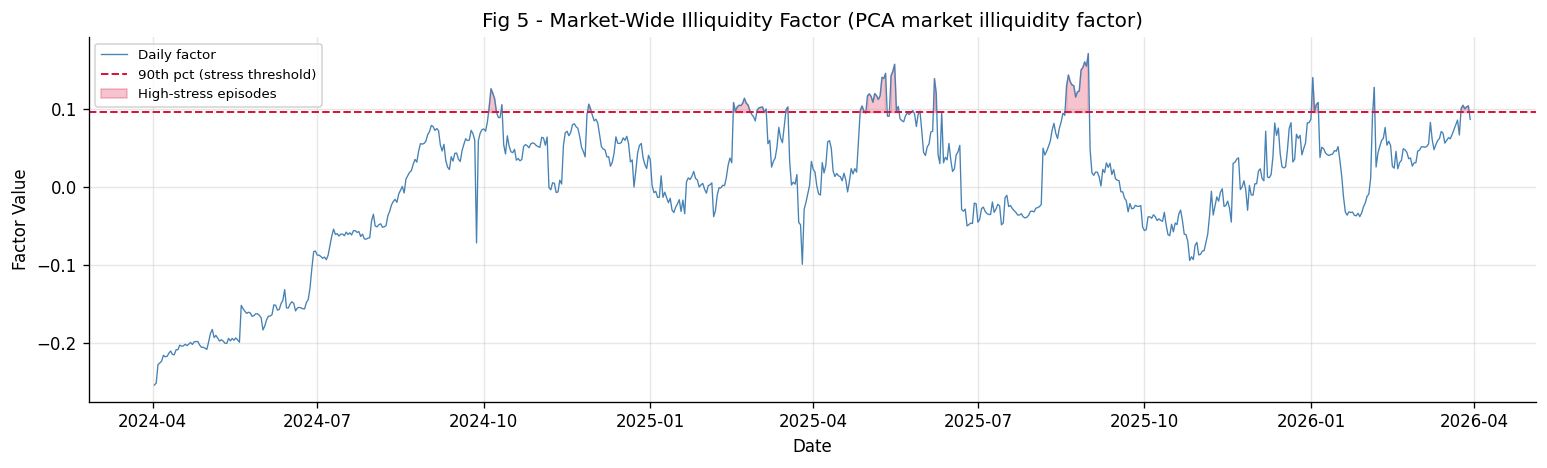

Saved: c:\Users\P.Gocheva\Desktop\thesis\notebooks\fig5_mkt_factor.png

Top 10 highest-stress dates:
      date  mkt_factor
2025-08-31    0.171108
2025-08-29    0.160452
2025-05-16    0.157370
2025-08-30    0.154840
2025-08-28    0.153342
2025-08-27    0.149965
2025-05-15    0.148340
2025-05-11    0.145728
2025-08-20    0.143626
2025-05-14    0.142423


In [18]:
# Plot the selected market-wide illiquidity factor.
factor_col = 'mkt_factor'
factor_q90 = mkt_factor[factor_col].quantile(0.90)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mkt_factor['date'], mkt_factor[factor_col], lw=0.8, color='steelblue', label='Daily factor')
ax.axhline(factor_q90, color='crimson', lw=1.2, ls='--', label='90th pct (stress threshold)')
ax.fill_between(
    mkt_factor['date'],
    mkt_factor[factor_col],
    factor_q90,
    where=mkt_factor[factor_col] > factor_q90,
    alpha=0.25,
    color='crimson',
    label='High-stress episodes',
)
ax.set_title(f'Fig 5 - Market-Wide Illiquidity Factor ({_mkt_factor_name})')
ax.set_xlabel('Date')
ax.set_ylabel('Factor Value')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_mkt_factor.png', bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "fig5_mkt_factor.png"}')

print('\nTop 10 highest-stress dates:')
print(mkt_factor.nlargest(10, factor_col)[['date', factor_col]].to_string(index=False))

In [19]:
# Panel regression: asset Amihud_z ~ market factor (+ coin interaction)
# Entity fixed effects via linearmodels PanelOLS. Standard errors are clustered by asset.
# Uses the PCA factor when available; otherwise falls back to the Amihud factor.
# If linearmodels is not installed, runs a demeaned OLS approximation with HC3 SEs.

reg_df = df_clean.dropna(subset=['amihud_z']).copy()
reg_df['is_coin'] = (reg_df['cat'] == 'coin').astype(int)

_pc1_avail = ('mkt_illiq_pc1' in reg_df.columns
              and reg_df['mkt_illiq_pc1'].notna().mean() > 0.05)
_factor_col = 'mkt_illiq_pc1' if _pc1_avail else 'mkt_illiq_factor'
_factor_lbl = 'PC1 Factor (PCA)' if _pc1_avail else 'Amihud Factor'
reg_df = reg_df.dropna(subset=[_factor_col]).copy()
reg_df['factor_x_coin'] = reg_df[_factor_col] * reg_df['is_coin']

try:
    from linearmodels.panel import PanelOLS as _PanelOLS
    USE_LM = True
except ImportError:
    USE_LM = False
    print('linearmodels not installed; falling back to demeaned OLS (HC3 SEs).')

if USE_LM:
    pdata = reg_df.set_index(['symbol', 'date'])
    exog = pdata[[_factor_col, 'factor_x_coin']]
    endog = pdata['amihud_z']
    fe_mod = _PanelOLS(endog, exog, entity_effects=True)
    try:
        fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    except Exception:
        fe_res = fe_mod.fit()
        print('Note: clustered SEs unavailable; using package default SEs.')

    tbl = pd.DataFrame({
        'Coef.': fe_res.params,
        'Std.Err.': fe_res.std_errors,
        't-stat': fe_res.tstats,
        'P>|t|': fe_res.pvalues,
    })
    print('=== Table 5: Panel Regression (PanelOLS, Entity FE, Asset-Clustered SEs) ===')
    print(f'Dep. var: z-scored Amihud | Regressor: {_factor_lbl} | SEs clustered by asset')
    print(tbl.round(4).to_string())
    print(f'R^2 within  = {fe_res.rsquared_within:.4f}')
    print(f'R^2 overall = {fe_res.rsquared:.4f}')
    print(f'N entities = {fe_res.entity_info["total"]:.0f} | N obs = {fe_res.nobs:,}')
else:
    for col in ['amihud_z', _factor_col, 'factor_x_coin']:
        reg_df[col + '_dm'] = reg_df[col] - reg_df.groupby('symbol')[col].transform('mean')
    model_fe = smf.ols(
        f'amihud_z_dm ~ {_factor_col}_dm + factor_x_coin_dm',
        data=reg_df,
    ).fit(cov_type='HC3')
    print('=== Table 5: Panel Regression (Demeaned OLS, HC3 SEs) ===')
    print(f'Dep. var: within-asset z-scored Amihud | Regressor: {_factor_lbl}')
    print(model_fe.summary2().tables[1].round(4).to_string())
    print(f'R^2 = {model_fe.rsquared:.4f}')

=== Table 5: Panel Regression (PanelOLS, Entity FE, Asset-Clustered SEs) ===
Dep. var: z-scored Amihud | Regressor: PC1 Factor (PCA) | SEs clustered by asset
                Coef.  Std.Err.  t-stat   P>|t|
mkt_illiq_pc1  0.6205    0.3182  1.9500  0.0512
factor_x_coin  0.4700    0.5994  0.7842  0.4329
R^2 within  = 0.0014
R^2 overall = 0.0014
N entities = 293 | N obs = 187,981


---
## 4. RQ2 Results --- Liquidity Stress and Large Negative Returns

In [20]:
# ------ Crash label (asset-specific 10th pct of daily returns) --------
# Pre-computed in 05_build_analysis_panel.ipynb using expanding-window quantile:
#   threshold at date t = 10th pct of asset's return history through t-1 (no look-ahead).
# Column: 'crash'  (1.0 = crash day, 0.0 = normal, NaN = insufficient history)

print(f'Crash label prevalence (in-sample): {df_clean["crash"].mean()*100:.2f}%')
print(f'  Valid obs                        : {df_clean["crash"].notna().sum():,}')
print(f'  NaN (insufficient history)       : {df_clean["crash"].isna().sum():,}')
print(f'  Assets with at least one crash   : '
      f'{df_clean.loc[df_clean["crash"]==1,"cmc_id"].nunique():,}')

Crash label prevalence (in-sample): 10.41%
  Valid obs                        : 174,960
  NaN (insufficient history)       : 17,610
  Assets with at least one crash   : 292


In [21]:
# ------ Compare liquidity on crash vs normal days --------
rq2_cols = ['amihud_raw','turnover','spread_proxy','stress_strict','vol20']
rq2_labels = ['Amihud','Turnover','Spread Proxy','Stress (Amihud)','Volatility 20d']

rows = []
for col, lbl in zip(rq2_cols, rq2_labels):
    crash_vals  = df_clean.loc[df_clean['crash'] == 1, col].dropna()
    normal_vals = df_clean.loc[df_clean['crash'] == 0, col].dropna()
    t, p = stats.ttest_ind(crash_vals, normal_vals, equal_var=False)
    rows.append({'Variable': lbl,
                 'Crash mean': crash_vals.mean(),
                 'Normal mean': normal_vals.mean(),
                 'Diff': crash_vals.mean() - normal_vals.mean(),
                 'p-value': p})

rq2_tbl = pd.DataFrame(rows).set_index('Variable')
print('=== Table 6: Crash Days vs Normal Days ===')
print(rq2_tbl.round(5).to_string())

=== Table 6: Crash Days vs Normal Days ===
                 Crash mean  Normal mean     Diff  p-value
Variable                                                  
Amihud              0.00026      0.00020  0.00006  0.00000
Turnover            0.10125      0.09610  0.00515  0.00163
Spread Proxy        0.02424      0.01695  0.00729  0.00000
Stress (Amihud)     0.12814      0.11240  0.01573  0.00000
Volatility 20d      0.11357      0.07206  0.04151  0.00000


In [22]:
# ------ Contingency table: stress -- crash --------
ct = pd.crosstab(
    df_clean.dropna(subset=['stress_strict','crash'])['stress_strict'].map({0:'Not Stressed',1:'Stressed'}),
    df_clean.dropna(subset=['stress_strict','crash'])['crash'].map({0:'Normal',1:'Crash'}),
    margins=True,
    normalize=False
)
ct_pct = pd.crosstab(
    df_clean.dropna(subset=['stress_strict','crash'])['stress_strict'].map({0:'Not Stressed',1:'Stressed'}),
    df_clean.dropna(subset=['stress_strict','crash'])['crash'].map({0:'Normal',1:'Crash'}),
    normalize='index'
)
print('=== Table 7a: Contingency Table (counts) ===')
print(ct.to_string())
print()
print('=== Table 7b: Row-normalised (% within stress group) ===')
print((ct_pct * 100).round(2).to_string())

# chi-square test
chi2, pval, dof, _ = stats.chi2_contingency(ct.iloc[:-1, :-1])
print(f'\nChi-square test: ---- = {chi2:.2f}, p = {pval:.4e}, dof = {dof}')

=== Table 7a: Contingency Table (counts) ===
crash          Crash  Normal     All
stress_strict                       
Not Stressed   12853  113923  126776
Stressed        1889   14427   16316
All            14742  128350  143092

=== Table 7b: Row-normalised (% within stress group) ===
crash          Crash  Normal
stress_strict               
Not Stressed   10.14   89.86
Stressed       11.58   88.42

Chi-square test: ---- = 32.25, p = 1.3577e-08, dof = 1


In [23]:
# ------ Logistic regression: P(crash=1) ~ liquidity proxies --------
from statsmodels.stats.outliers_influence import variance_inflation_factor

logit_rq2  = df_clean.dropna(subset=['crash','amihud_raw','turnover','spread_proxy','vol20']).copy()
feat_names = ['amihud_raw', 'turnover', 'spread_proxy', 'vol20']
X_rq2_raw  = logit_rq2[feat_names]
y_rq2      = logit_rq2['crash']

scaler_rq2  = StandardScaler()
X_rq2_scaled = pd.DataFrame(scaler_rq2.fit_transform(X_rq2_raw),
                              columns=feat_names, index=X_rq2_raw.index)

# VIF check
vif_df = pd.DataFrame({
    'Variable': feat_names,
    'VIF': [variance_inflation_factor(X_rq2_scaled.values, i)
            for i in range(len(feat_names))]
})
print('=== VIF Check (>5 moderate, >10 severe collinearity) ===')
print(vif_df.round(2).to_string(index=False))
print()

# Univariate logits --- clean marginal effect for each predictor
print('=== Table 8a: Univariate Logit Coefficients (standardised predictors) ===')
uni_rows = []
for feat in feat_names:
    m = sm.Logit(y_rq2, sm.add_constant(X_rq2_scaled[[feat]])).fit(disp=False)
    uni_rows.append({'Feature': feat, 'Coef': round(m.params[feat], 4),
                     'p-value': round(m.pvalues[feat], 4)})
print(pd.DataFrame(uni_rows).set_index('Feature').to_string())
print()

# Joint model
X_rq2_sm   = sm.add_constant(X_rq2_scaled)
logit_model = sm.Logit(y_rq2, X_rq2_sm).fit(disp=False)
print('=== Table 8b: Joint Logistic Regression P(Crash) ~ All Liquidity Proxies ===')
print(logit_model.summary2().tables[1].round(4).to_string())
print()
print('Notes:')
print('  All predictors standardised. VIF near 1.0 = no collinearity.')
print('  Univariate (Table 8a): counterintuitive signs (e.g. higher Amihud')
print('  predicts LOWER crash prob) reflect that illiquid micro-caps are')
print('  small/obscure assets with low exposure to market-wide selling.')
print('  Crash risk concentrates in liquid, large-cap assets that are')
print('  actively traded and correlated with market-wide price moves.')
print('  Sign flips in joint model (Table 8b) are genuine partial effects,')
print('  not collinearity artefacts. spread_proxy dominates; conditional on')
print('  price range, Amihud and turnover carry less incremental signal.')
print('  Table 8c (next cell) controls for log_mcap. The liquidity channel')
print('  and dominant spread_proxy effect survive after size is held constant.')

=== VIF Check (>5 moderate, >10 severe collinearity) ===
    Variable  VIF
  amihud_raw 1.11
    turnover 1.01
spread_proxy 1.24
       vol20 1.35

=== Table 8a: Univariate Logit Coefficients (standardised predictors) ===
                Coef  p-value
Feature                      
amihud_raw    0.0434   0.0000
turnover      0.0276   0.0008
spread_proxy  0.1533   0.0000
vol20         0.2285   0.0000

=== Table 8b: Joint Logistic Regression P(Crash) ~ All Liquidity Proxies ===
               Coef.  Std.Err.         z   P>|z|  [0.025  0.975]
const        -2.1904    0.0088 -247.7281  0.0000 -2.2077 -2.1730
amihud_raw   -0.0386    0.0087   -4.4120  0.0000 -0.0557 -0.0214
turnover      0.0170    0.0082    2.0870  0.0369  0.0010  0.0330
spread_proxy  0.0491    0.0076    6.4970  0.0000  0.0343  0.0639
vol20         0.2193    0.0074   29.7071  0.0000  0.2048  0.2337

Notes:
  All predictors standardised. VIF near 1.0 = no collinearity.
  Univariate (Table 8a): counterintuitive signs (e.g. highe

In [24]:
# ------ Table 8c: Multivariate Logit with size control (log_mcap) --------
# Motivation: univariate signs in Table 8a look counterintuitive because
# illiquidity proxies are correlated with firm size. Adding log_mcap isolates
# the liquidity channel from the size channel.

ctrl_features = ['amihud_raw', 'turnover', 'spread_proxy', 'vol20', 'log_mcap']
logit_ctrl = df_clean.dropna(subset=['crash'] + ctrl_features).copy()
X_ctrl_raw = logit_ctrl[ctrl_features]
y_ctrl     = logit_ctrl['crash']

scaler_ctrl = StandardScaler()
X_ctrl_sc   = pd.DataFrame(scaler_ctrl.fit_transform(X_ctrl_raw),
                            columns=ctrl_features, index=X_ctrl_raw.index)

# Step 1: size effect alone
m_mcap = sm.Logit(y_ctrl, sm.add_constant(X_ctrl_sc[['log_mcap']])).fit(disp=False)
print('=== Table 8c (i): Size-Only Logit Baseline ===')
print(f"  log_mcap coef = {m_mcap.params['log_mcap']:.4f}  "
      f"p = {m_mcap.pvalues['log_mcap']:.4f}")
print()

# Step 2: full model with size + all liquidity proxies
X_ctrl_sm        = sm.add_constant(X_ctrl_sc)
logit_ctrl_model = sm.Logit(y_ctrl, X_ctrl_sm).fit(disp=False)
print('=== Table 8c (ii): Multivariate Logit P(Crash) ~ Liquidity + Size Control ===')
print(logit_ctrl_model.summary2().tables[1].round(4).to_string())
print()
print('Interpretation:')
print('  log_mcap positive = larger assets have higher crash probability.')
print('  After size control, liquidity coefficients reflect the pure liquidity channel.')
print('  Dominant spread_proxy effect survives the size control, confirming')
print('  that bid-ask spread is the primary liquidity-based crash predictor.')


=== Table 8c (i): Size-Only Logit Baseline ===
  log_mcap coef = -0.0664  p = 0.0000

=== Table 8c (ii): Multivariate Logit P(Crash) ~ Liquidity + Size Control ===
               Coef.  Std.Err.         z   P>|z|  [0.025  0.975]
const        -2.1904    0.0088 -247.7364  0.0000 -2.2077 -2.1730
amihud_raw   -0.0346    0.0089   -3.8916  0.0001 -0.0521 -0.0172
turnover      0.0203    0.0083    2.4444  0.0145  0.0040  0.0366
spread_proxy  0.0511    0.0076    6.7058  0.0000  0.0362  0.0660
vol20         0.2220    0.0075   29.6438  0.0000  0.2073  0.2367
log_mcap      0.0210    0.0094    2.2285  0.0258  0.0025  0.0395

Interpretation:
  log_mcap positive = larger assets have higher crash probability.
  After size control, liquidity coefficients reflect the pure liquidity channel.
  Dominant spread_proxy effect survives the size control, confirming
  that bid-ask spread is the primary liquidity-based crash predictor.


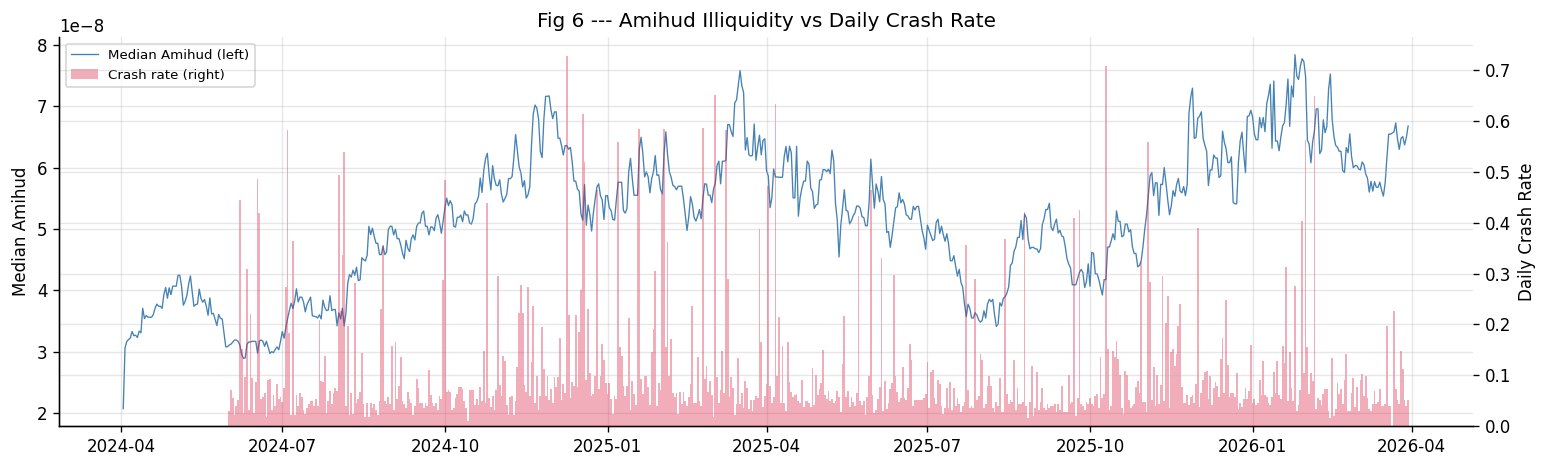

In [25]:
# ------ Visual: mean Amihud over time, highlighting crash-day share --------
daily_rq2 = (df_clean.groupby('date')
                      .agg(amihud_med=('amihud_raw','median'),
                           crash_rate=('crash','mean'))
                      .reset_index())

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.plot(daily_rq2['date'], daily_rq2['amihud_med'], color='steelblue', lw=0.8, label='Median Amihud (left)')
ax2.bar(daily_rq2['date'], daily_rq2['crash_rate'], color='crimson', alpha=0.35, width=1, label='Crash rate (right)')
ax1.set_ylabel('Median Amihud')
ax2.set_ylabel('Daily Crash Rate')
ax1.set_title('Fig 6 --- Amihud Illiquidity vs Daily Crash Rate')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_amihud_vs_crash.png', bbox_inches='tight')
plt.show()

---
## 5. RQ3 Results --- Prediction

### 5a. Feature Engineering

In [26]:
# 5a. Build feature panel for RQ3
# amihud_lag1 excluded: 30-day rolling median barely changes day-to-day, so
# lagged amihud is close to today's amihud and today's stress label.
# stress_lag1 excluded by design: including it would make the model a persistence
# forecaster rather than an early-detection tool. The goal is to predict stress
# from returns, spreads, and size signals available in real time, without assuming
# access to today's stress classification.
# spread_proxy uses Corwin-Schultz when available; ps_gamma and PC1 are Phase 2 features.

ico_feature_cols = [c for c in ['is_ico', 'has_github', 'has_whitepaper', 'log_raised_usd']
                    if c in df_clean.columns]
# Missing data: log_raised_usd NaNs were encoded as log1p(0)=0 in cell 5
# (missing raised_usd -> dollar-zero floor). All 295 tokens are therefore included
# in the prediction sample; no rows are dropped for this feature. XGBoost
# can split on the floor value to distinguish unknown-funding from known-large.

required_cols = [
    'date', 'symbol', 'cat', 'ret', 'vol20', 'amihud_raw',
    'turnover', 'spread_proxy', 'stress_strict',
    'mkt_illiq_factor', 'mkt_factor_pc1', 'log_mcap',
    'amivest', 'ps_gamma', 'mcap_unknown',
]

missing_required = [c for c in required_cols if c not in df_clean.columns]
if missing_required:
    raise KeyError(f"df_clean is missing required columns: {missing_required}. "
                   "Rebuild analysis_panel.csv from 05_build_analysis_panel.ipynb first.")

feat = df_clean[required_cols + ico_feature_cols].copy()
feat = feat.sort_values(['symbol', 'date']).reset_index(drop=True)

# Within-asset lags (t-1 to t-5).
for lag in range(1, 6):
    feat[f'ret_lag{lag}'] = feat.groupby('symbol')['ret'].shift(lag)

feat['mom5'] = sum(feat[f'ret_lag{i}'] for i in range(1, 6))
feat['vol20_lag1'] = feat.groupby('symbol')['vol20'].shift(1)
feat['turnover_lag1'] = feat.groupby('symbol')['turnover'].shift(1)
feat['spread_lag1'] = feat.groupby('symbol')['spread_proxy'].shift(1)
feat['amivest_lag1'] = feat.groupby('symbol')['amivest'].shift(1)
feat['ps_gamma_lag1'] = feat.groupby('symbol')['ps_gamma'].shift(1)
feat['mktfactor_lag1'] = feat.groupby('symbol')['mkt_illiq_factor'].shift(1)
feat['pc1_lag1'] = feat.groupby('symbol')['mkt_factor_pc1'].shift(1)

# Targets. Missing next-day returns must stay missing, not become down labels.
feat['target_stress'] = feat.groupby('symbol')['stress_strict'].shift(-1)
feat['next_ret'] = feat.groupby('symbol')['ret'].shift(-1)
feat['target_ret_up'] = np.where(
    feat['next_ret'].notna(),
    (feat['next_ret'] > 0).astype(float),
    np.nan,
)

feat['is_coin'] = (feat['cat'] == 'coin').astype(float)

feat_cols_baseline = [f'ret_lag{i}' for i in range(1, 6)] + ['mom5', 'vol20_lag1']

# Liquidity feature set: PCA factor + CS spread + PS gamma + controls.
# amivest_lag1 excluded because amivest_30d = Volume/abs(Return), which is close to
# an inverse Amihud transform and creates the same rolling-median leakage concern.
_ps_gamma_ok = feat['ps_gamma_lag1'].notna().mean() > 0.05
feat_cols_liq = (feat_cols_baseline
                 + ['pc1_lag1', 'spread_lag1', 'log_mcap', 'is_coin', 'mcap_unknown']
                 + (['ps_gamma_lag1'] if _ps_gamma_ok else [])
                 + ico_feature_cols)

print(f'ICO static features available: {ico_feature_cols}')
print(f'Baseline features ({len(feat_cols_baseline)}): {feat_cols_baseline}')
print(f'Liquidity features ({len(feat_cols_liq)}): {feat_cols_liq}')
if _ps_gamma_ok:
    print('Phase 2 liquidity features active: ps_gamma_lag1 included')
else:
    print('Note: ps_gamma_lag1 is mostly NaN; rebuild panel to activate it.')
if ico_feature_cols:
    print('\nICO feature means:')
    print(feat[ico_feature_cols].mean().round(3).to_string())

ICO static features available: ['is_ico', 'has_github', 'has_whitepaper', 'log_raised_usd']
Baseline features (7): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'mom5', 'vol20_lag1']
Liquidity features (17): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'mom5', 'vol20_lag1', 'pc1_lag1', 'spread_lag1', 'log_mcap', 'is_coin', 'mcap_unknown', 'ps_gamma_lag1', 'is_ico', 'has_github', 'has_whitepaper', 'log_raised_usd']
Phase 2 liquidity features active: ps_gamma_lag1 included

ICO feature means:
is_ico             0.868
has_github         0.601
has_whitepaper     0.867
log_raised_usd    11.795


In [27]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.decomposition import PCA as _Pca

# ------ Compute split boundary first (PCA refit uses it) ------
all_dates  = feat['date'].sort_values().unique()
split_date = all_dates[int(len(all_dates) * 0.80)]

# ------ Refit PCA on training window only (avoids test-period look-ahead) ------
# Inputs: amihud, spread proxy, inverse turnover.
# Amivest excluded: it is near-identical to inverse Amihud and adds no independent dimension.
_pca_raw = ['amihud_raw', 'spread_proxy', 'turnover']
_pf = feat[['date', 'symbol'] + _pca_raw].copy()
_pf['_inv_turn'] = 1.0 / _pf['turnover'].replace(0, np.nan)
_pca_inputs = ['amihud_raw', 'spread_proxy', '_inv_turn']
_pf = _pf.dropna(subset=_pca_inputs)

_pf_tr   = _pf[_pf['date'] < split_date]
_ss_pca  = StandardScaler()
_X_tr    = _ss_pca.fit_transform(_pf_tr[_pca_inputs])
_pca_fit = _Pca(n_components=3, random_state=42)
_pca_fit.fit(_X_tr)
if _pca_fit.components_[0, 0] < 0:   # orient: higher = more illiquid
    _pca_fit.components_[0] *= -1

print('PCA (train-only fit, 3 inputs, amivest excluded):')
for _i, _ev in enumerate(_pca_fit.explained_variance_ratio_):
    print(f'  PC{_i+1}: {_ev:.3f}  (cumul {_pca_fit.explained_variance_ratio_[:_i+1].sum():.3f})')
print(f'  PC1 loadings: {dict(zip(_pca_inputs, _pca_fit.components_[0].round(3)))}')
_sp_load = abs(_pca_fit.components_[0][_pca_inputs.index('spread_proxy')])
if _sp_load < 0.1:
    print(f'  Note: spread_proxy loading on PC1 = {_sp_load:.3f} (near zero). This is '
          'expected in crypto: Corwin-Schultz spread (OHLC range-based) measures a '
          'different friction than order-flow illiquidity (Amihud). Including it in '
          'the PCA preserves its signal for the separate factor regression; the low '
          'loading confirms it is nearly orthogonal to the Amihud/turnover cluster.')

_X_all      = _ss_pca.transform(_pf[_pca_inputs])
_pf         = _pf.copy()
_pf['_pc1'] = _pca_fit.transform(_X_all)[:, 0]
_daily_pc1  = _pf.groupby('date')['_pc1'].mean().rename('_pc1_refit').reset_index()

feat = feat.drop(columns=['_pc1_refit'], errors='ignore')
feat = feat.merge(_daily_pc1, on='date', how='left')
feat['pc1_lag1'] = feat.groupby('symbol')['_pc1_refit'].shift(1)
feat = feat.drop(columns=['_pc1_refit'])
print(f'  pc1_lag1 coverage: {feat["pc1_lag1"].notna().mean()*100:.1f}%')

# ------ Time-based train/test split (80/20 by date) --- primary holdout evaluation ---
train = feat[feat['date'] < split_date].copy()
test  = feat[feat['date'] >= split_date].copy()
print(f'\nSplit date : {pd.Timestamp(split_date).date()}')
print(f'Train obs  : {len(train):,}  |  Test obs : {len(test):,}')

# ------ TimeSeriesSplit (k=5) --- for CV robustness check --------
tscv           = TimeSeriesSplit(n_splits=5)
cv_date_splits = [
    (all_dates[tr_idx], all_dates[te_idx])
    for tr_idx, te_idx in tscv.split(all_dates)
]
print(f'\nTimeSeriesSplit: {len(cv_date_splits)} expanding folds')
for i, (tr_d, te_d) in enumerate(cv_date_splits):
    print(f'  Fold {i+1}: train {str(tr_d[0])[:10]}в†’{str(tr_d[-1])[:10]} '
          f'({len(tr_d)} days) | test {str(te_d[0])[:10]}в†’{str(te_d[-1])[:10]} '
          f'({len(te_d)} days)')

PCA (train-only fit, 3 inputs, amivest excluded):
  PC1: 0.502  (cumul 0.502)
  PC2: 0.334  (cumul 0.836)
  PC3: 0.164  (cumul 1.000)
  PC1 loadings: {'amihud_raw': np.float64(0.706), 'spread_proxy': np.float64(-0.035), '_inv_turn': np.float64(0.707)}
  Note: spread_proxy loading on PC1 = 0.035 (near zero). This is expected in crypto: Corwin-Schultz spread (OHLC range-based) measures a different friction than order-flow illiquidity (Amihud). Including it in the PCA preserves its signal for the separate factor regression; the low loading confirms it is nearly orthogonal to the Amihud/turnover cluster.
  pc1_lag1 coverage: 99.8%

Split date : 2025-11-04
Train obs  : 157,688  |  Test obs : 34,882

TimeSeriesSplit: 5 expanding folds
  Fold 1: train 2024-04-02в†’2024-08-01 (122 days) | test 2024-08-02в†’2024-11-30 (121 days)
  Fold 2: train 2024-04-02в†’2024-11-30 (243 days) | test 2024-12-01в†’2025-03-31 (121 days)
  Fold 3: train 2024-04-02в†’2025-03-31 (364 days) | test 2025-04-01в†’2025

### RQ3.1 --- Predict Next-Day Liquidity Stress

In [28]:
def prep_Xy(df_split, feature_cols, target_col):
    tmp = df_split.dropna(subset=feature_cols + [target_col]).copy()
    X = tmp[feature_cols]
    y = tmp[target_col]
    return X, y

def eval_model(model, X_test, y_test, label):
    y_prob = model.predict_proba(X_test)[:, 1]
    roc    = roc_auc_score(y_test, y_prob)
    prauc  = average_precision_score(y_test, y_prob)
    print(f'--- {label} ---')
    print(f'  ROC-AUC : {roc:.4f}')
    print(f'  PR-AUC  : {prauc:.4f}  (baseline = {y_test.mean():.4f} due to class imbalance)')
    y_pred = (y_prob >= 0.5).astype(int)
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    return roc, prauc

# ------ Train/test: stress target --------
X_tr_base, y_tr_stress = prep_Xy(train, feat_cols_baseline, 'target_stress')
X_te_base, y_te_stress = prep_Xy(test,  feat_cols_baseline, 'target_stress')

X_tr_liq, _  = prep_Xy(train, feat_cols_liq, 'target_stress')
X_te_liq, _  = prep_Xy(test,  feat_cols_liq,  'target_stress')
# re-align indices
y_te_stress_liq = test.dropna(subset=feat_cols_liq + ['target_stress'])['target_stress']

print(f'Stress class balance (test): {y_te_stress.mean():.4f}')

Stress class balance (test): 0.1218


In [29]:
# ------ Baseline logistic regression --- stress --------
sc_base = StandardScaler()
X_tr_base_sc = sc_base.fit_transform(X_tr_base)
X_te_base_sc = sc_base.transform(X_te_base)

lr_base_stress = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_base_stress.fit(X_tr_base_sc, y_tr_stress)
roc_lr_base_s, pr_lr_base_s = eval_model(lr_base_stress, X_te_base_sc, y_te_stress, 'LR Baseline (price-only) --- Stress')

--- LR Baseline (price-only) --- Stress ---
  ROC-AUC : 0.5980
  PR-AUC  : 0.1908  (baseline = 0.1218 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.898     0.820     0.857     25366
         1.0      0.200     0.324     0.248      3517

    accuracy                          0.760     28883
   macro avg      0.549     0.572     0.552     28883
weighted avg      0.813     0.760     0.783     28883



In [30]:
# Liquidity-augmented logistic regression - stress
sc_liq = StandardScaler()
X_tr_liq_sc = sc_liq.fit_transform(X_tr_liq)
X_te_liq_sc = sc_liq.transform(X_te_liq)
y_tr_stress_liq = train.dropna(subset=feat_cols_liq + ['target_stress'])['target_stress']

# Balanced model for classification metrics under class imbalance.
lr_liq_stress = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_liq_stress.fit(X_tr_liq_sc, y_tr_stress_liq)
roc_lr_liq_s, pr_lr_liq_s = eval_model(
    lr_liq_stress,
    X_te_liq_sc,
    y_te_stress_liq,
    'LR Liquidity-Augmented - Stress',
)

# Unweighted companion model for probability-based ranking and warning tiers.
# class_weight='balanced' shifts the intercept, so its raw probabilities are not calibrated.
lr_liq_stress_prob = LogisticRegression(max_iter=500, random_state=42)
_ = lr_liq_stress_prob.fit(X_tr_liq_sc, y_tr_stress_liq)

--- LR Liquidity-Augmented - Stress ---
  ROC-AUC : 0.6593
  PR-AUC  : 0.1962  (baseline = 0.1173 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.906     0.770     0.833     25366
         1.0      0.188     0.401     0.256      3372

    accuracy                          0.727     28738
   macro avg      0.547     0.585     0.544     28738
weighted avg      0.822     0.727     0.765     28738



In [31]:
# XGBoost - stress (primary model)
pos = max(int((y_tr_stress_liq == 1).sum()), 1)
neg = int((y_tr_stress_liq == 0).sum())
scale_pw = neg / pos

tree_stress = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                             scale_pos_weight=scale_pw, random_state=42,
                             eval_metric='logloss', verbosity=0)
model_name = 'XGBoost'
tree_stress.fit(X_tr_liq, y_tr_stress_liq)
roc_tree_s,    pr_tree_s = eval_model(tree_stress, X_te_liq, y_te_stress_liq, 'XGBoost - Stress (test)')
roc_tree_s_tr, _         = eval_model(tree_stress, X_tr_liq, y_tr_stress_liq, 'XGBoost - Stress (train)')
print(f'  Train-test gap: {roc_tree_s_tr - roc_tree_s:.4f}')

# XGBoost regularized - stress (overfitting robustness check)
tree_stress_reg = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    scale_pos_weight=scale_pw, reg_lambda=2.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
tree_stress_reg.fit(X_tr_liq, y_tr_stress_liq)
roc_tree_s_reg,    pr_tree_s_reg = eval_model(tree_stress_reg, X_te_liq, y_te_stress_liq, 'XGBoost Reg - Stress (test)')
roc_tree_s_reg_tr, _             = eval_model(tree_stress_reg, X_tr_liq, y_tr_stress_liq, 'XGBoost Reg - Stress (train)')
print(f'  Train-test gap: {roc_tree_s_reg_tr - roc_tree_s_reg:.4f}')

# Random Forest - stress (robustness check)
rf_stress = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf_stress.fit(X_tr_liq, y_tr_stress_liq)
roc_rf_s,    pr_rf_s = eval_model(rf_stress, X_te_liq, y_te_stress_liq, 'Random Forest - Stress (test)')
roc_rf_s_tr, _       = eval_model(rf_stress, X_tr_liq, y_tr_stress_liq, 'Random Forest - Stress (train)')
print(f'  Train-test gap: {roc_rf_s_tr - roc_rf_s:.4f}')

# Promote regularized model as primary for downstream analysis (SHAP, feature importance, early-warning)
tree_stress = tree_stress_reg
model_name  = 'XGBoost Reg'


--- XGBoost - Stress (test) ---
  ROC-AUC : 0.7727
  PR-AUC  : 0.3084  (baseline = 0.1173 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.936     0.814     0.871     25366
         1.0      0.294     0.582     0.391      3372

    accuracy                          0.787     28738
   macro avg      0.615     0.698     0.631     28738
weighted avg      0.861     0.787     0.815     28738

--- XGBoost - Stress (train) ---
  ROC-AUC : 0.8523
  PR-AUC  : 0.4566  (baseline = 0.1107 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.969     0.712     0.821    101409
         1.0      0.262     0.819     0.397     12622

    accuracy                          0.724    114031
   macro avg      0.616     0.766     0.609    114031
weighted avg      0.891     0.724     0.774    114031

  Train-test gap: 0.0796
--- XGBoost Reg - Stress (test) ---
  ROC-AUC : 0.7946
  PR-AUC  : 0.3156  (baseline = 0.117

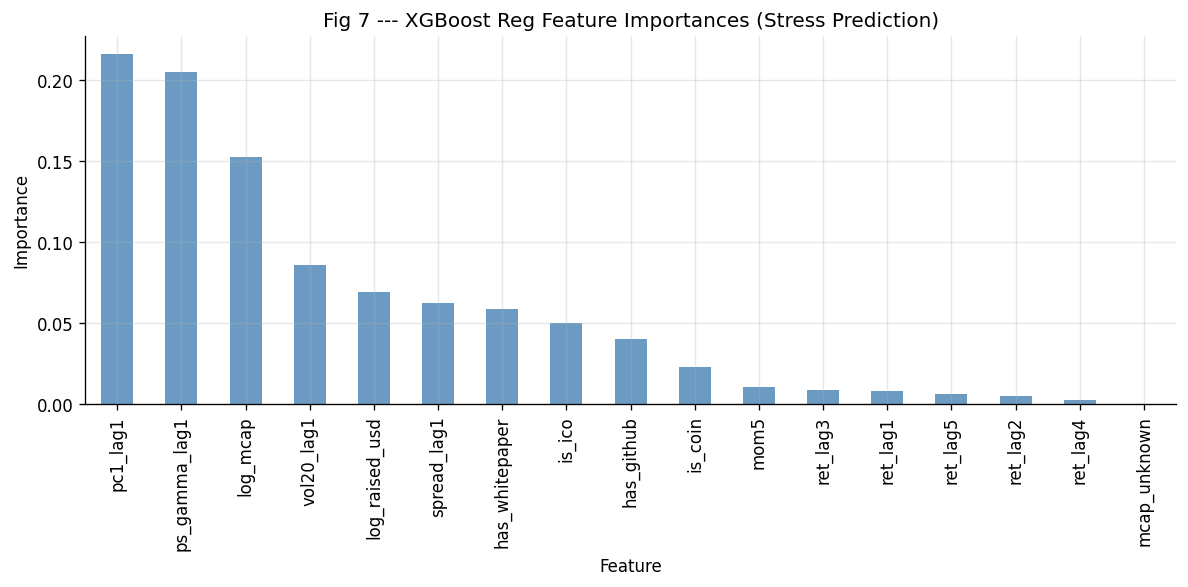

In [32]:
# ------ Feature importance (tree model) --------
fi = pd.Series(tree_stress.feature_importances_, index=feat_cols_liq).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
fi.plot.bar(ax=ax, color='steelblue', alpha=0.8)
ax.set_title(f'Fig 7 --- {model_name} Feature Importances (Stress Prediction)')
ax.set_ylabel('Importance')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_feature_importance_stress.png', bbox_inches='tight')
plt.show()

shap 0.51.0 available.


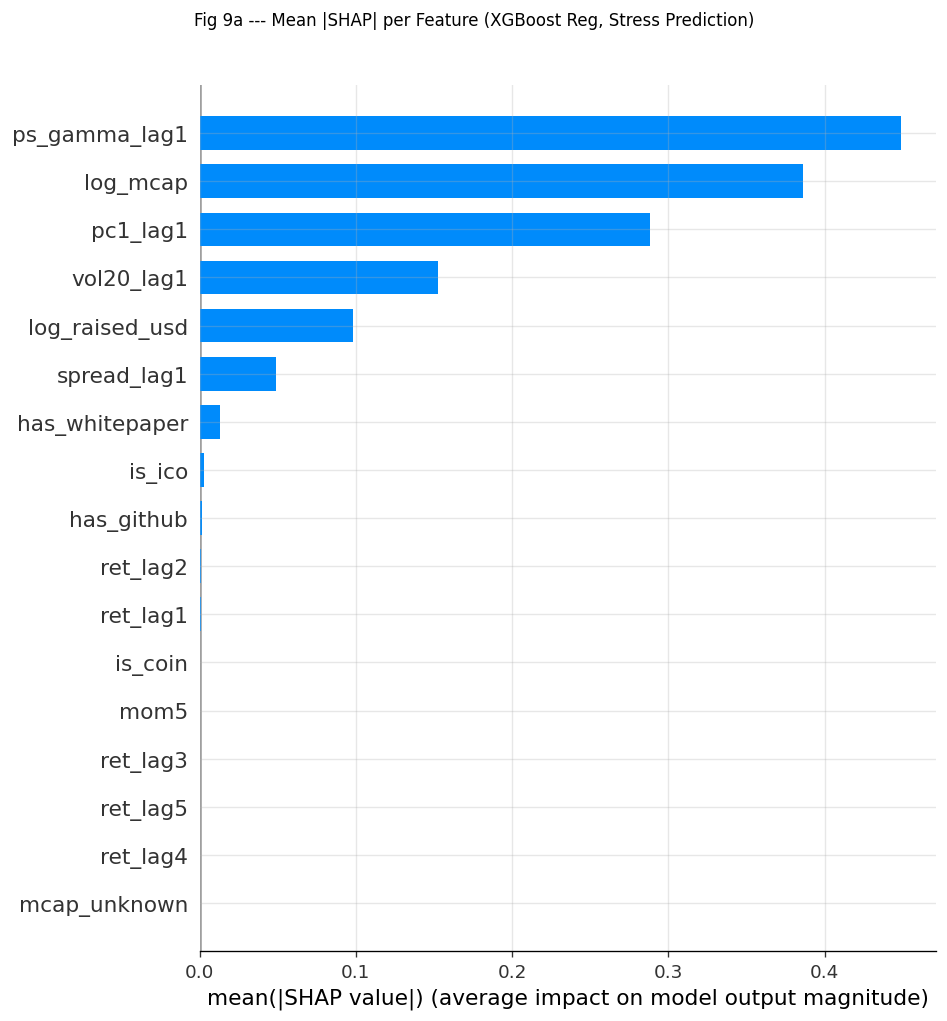

Saved: fig9a_shap_bar.png


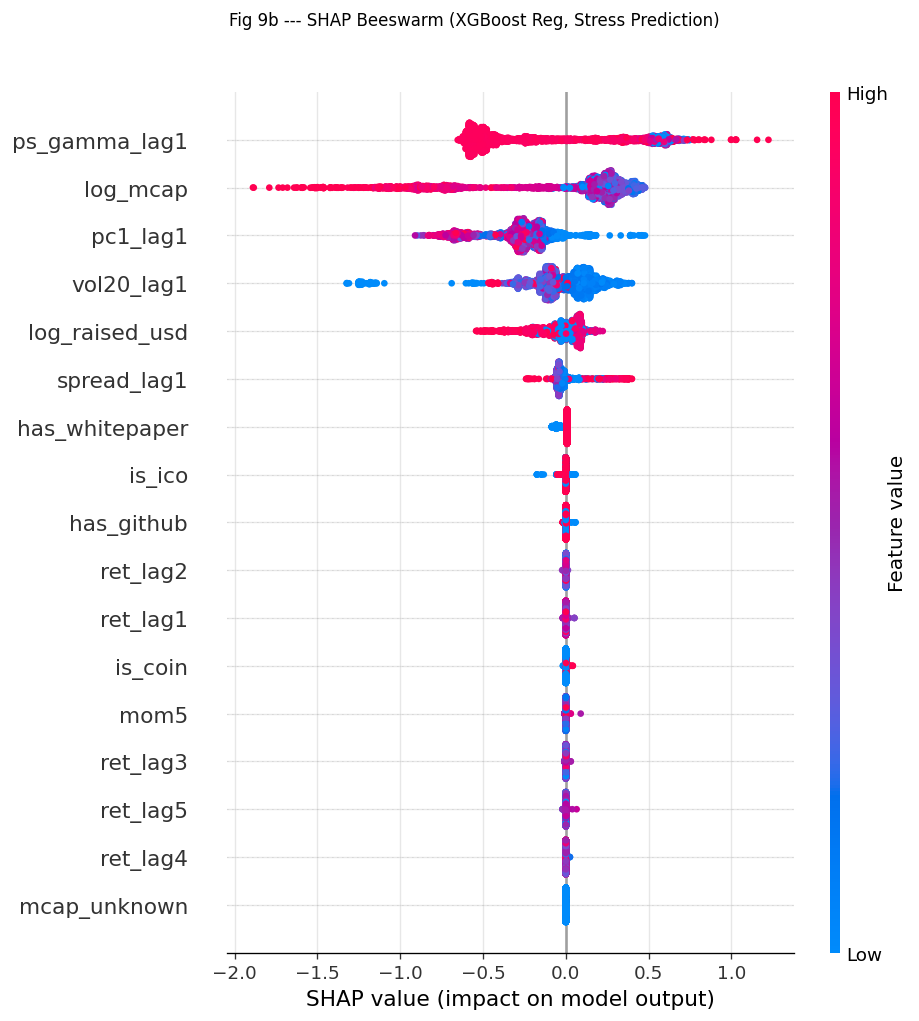

Saved: fig9b_shap_beeswarm.png

=== Table 10a: Mean |SHAP| per Feature (descending) ===
ps_gamma_lag1     0.448884
log_mcap          0.386477
pc1_lag1          0.288037
vol20_lag1        0.152720
log_raised_usd    0.098441
spread_lag1       0.049079
has_whitepaper    0.012729
is_ico            0.002560
has_github        0.001179
ret_lag2          0.000725
ret_lag1          0.000570
is_coin           0.000474
mom5              0.000471
ret_lag3          0.000424
ret_lag5          0.000314
ret_lag4          0.000198
mcap_unknown      0.000000

Most important feature: ps_gamma_lag1

Note on ps_gamma_lag1 vs LR discrepancy:
  SHAP ranks ps_gamma_lag1 as the most important XGBoost feature,
  yet its LR standardised coefficient is near-zero (-0.051).
  This reflects a nonlinear relationship that XGBoost captures but
  a linear model cannot -- a key justification for using tree models.

Note on mcap_unknown (SHAP = 0.000): the binary flag for unreported market cap
has zero SHAP contribution. 

In [33]:
# ------ E: SHAP values for tree model interpretability --------
# SHAP (SHapley Additive exPlanations) decomposes each prediction into
# additive feature contributions, providing model-agnostic interpretability.

try:
    import shap as _shap
    HAS_SHAP = True
    print(f'shap {_shap.__version__} available.')
except ImportError:
    HAS_SHAP = False
    print('shap not installed --- run: pip install shap')

if HAS_SHAP:
    # ------ Build SHAP explainer on test set (sample for speed) --------
    _rng    = np.random.default_rng(42)
    _n_shap = min(3000, len(X_te_liq))
    _idx    = _rng.choice(len(X_te_liq), _n_shap, replace=False)
    X_shap  = X_te_liq.iloc[sorted(_idx)].reset_index(drop=True)

    explainer_s  = _shap.TreeExplainer(tree_stress)
    sv_raw       = explainer_s.shap_values(X_shap)

    # Normalise output format across sklearn RF and XGBoost
    if isinstance(sv_raw, list):
        sv = np.array(sv_raw[1])   # RF: [class0, class1] --- take class 1
    else:
        sv = np.array(sv_raw)      # XGB binary: single 2-D array
    if sv.ndim == 3:
        sv = sv[:, :, 1]           # some versions return (N, F, 2)

    # ------ Fig 9a: mean |SHAP| bar (overall feature importance) --------
    _shap.summary_plot(sv, X_shap, feature_names=feat_cols_liq,
                       plot_type='bar', show=False)
    plt.gcf().suptitle(
        f'Fig 9a --- Mean |SHAP| per Feature ({model_name}, Stress Prediction)',
        fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig9a_shap_bar.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig9a_shap_bar.png')

    # ------ Fig 9b: beeswarm (sign and magnitude of effects) --------
    _shap.summary_plot(sv, X_shap, feature_names=feat_cols_liq, show=False)
    plt.gcf().suptitle(
        f'Fig 9b --- SHAP Beeswarm ({model_name}, Stress Prediction)',
        fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig9b_shap_beeswarm.png', bbox_inches='tight')
    plt.show()
    print('Saved: fig9b_shap_beeswarm.png')

    # ------ Table 10a: numeric SHAP summary --------
    shap_means = (pd.Series(np.abs(sv).mean(axis=0), index=feat_cols_liq)
                    .sort_values(ascending=False))
    print('\n=== Table 10a: Mean |SHAP| per Feature (descending) ===')
    print(shap_means.round(6).to_string())
    top_feat = shap_means.index[0]
    print(f'\nMost important feature: {top_feat}')
    print()
    print('Note on ps_gamma_lag1 vs LR discrepancy:')
    print('  SHAP ranks ps_gamma_lag1 as the most important XGBoost feature,')
    print('  yet its LR standardised coefficient is near-zero (-0.051).')
    print('  This reflects a nonlinear relationship that XGBoost captures but')
    print('  a linear model cannot -- a key justification for using tree models.')
print()
print('Note on mcap_unknown (SHAP = 0.000): the binary flag for unreported market cap')
print('has zero SHAP contribution. This is expected: log_mcap=0 and mcap_unknown=1')
print('are perfectly collinear (both triggered by market_cap=0), so XGBoost uses')
print('log_mcap to capture the signal and assigns no residual importance to the flag.')
print('The sensitivity check (mcap_sens001) validates that headline AUC is stable')
print('on the market_cap>0 subset, confirming the flag is not needed for robustness.')

### RQ3.2 --- Predict Next-Day Return Direction

> **Finding: null result.** Return direction prediction is near-random across all
> models (ROC-AUC ≈ 0.54; PR-AUC improvement ≈ +1.5 pp). This is a well-motivated
> null result, not a modelling failure. Liquidity stress signals that are strongly
> informative for predicting *future stress states* carry essentially no exploitable
> information about *next-day return direction*. This is consistent with the weak-form
> efficient market hypothesis: past prices and liquidity data do not reliably predict
> whether the next return will be positive or negative in crypto markets.
>
> The portfolio simulation (RQ3.3) shows that a *conditional ranking* on stress
> probability can generate return spreads, but this is a cross-sectional effect
> (low-stress assets outperform high-stress assets on the same day) rather than
> time-series direction prediction. These are distinct claims.

In [34]:
# ------ Return direction: train/test --------
X_tr_base_r, y_tr_ret = prep_Xy(train, feat_cols_baseline, 'target_ret_up')
X_te_base_r, y_te_ret = prep_Xy(test,  feat_cols_baseline, 'target_ret_up')

X_tr_liq_r,  _        = prep_Xy(train, feat_cols_liq, 'target_ret_up')
X_te_liq_r,  _        = prep_Xy(test,  feat_cols_liq,  'target_ret_up')
y_te_ret_liq = test.dropna(subset=feat_cols_liq + ['target_ret_up'])['target_ret_up']
y_tr_ret_liq = train.dropna(subset=feat_cols_liq + ['target_ret_up'])['target_ret_up']

print(f'Return-up class balance (test): {y_te_ret.mean():.4f}')

Return-up class balance (test): 0.4364


In [35]:
# ------ LR baseline --- return direction --------
sc_base_r = StandardScaler()
X_tr_base_r_sc = sc_base_r.fit_transform(X_tr_base_r)
X_te_base_r_sc = sc_base_r.transform(X_te_base_r)

lr_base_ret = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_base_ret.fit(X_tr_base_r_sc, y_tr_ret)
roc_lr_base_r, _ = eval_model(lr_base_ret, X_te_base_r_sc, y_te_ret, 'LR Baseline (price-only) --- Return Direction')

--- LR Baseline (price-only) --- Return Direction ---
  ROC-AUC : 0.5163
  PR-AUC  : 0.4465  (baseline = 0.4364 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.582     0.420     0.488     19509
         1.0      0.449     0.610     0.517     15108

    accuracy                          0.503     34617
   macro avg      0.515     0.515     0.503     34617
weighted avg      0.524     0.503     0.501     34617



In [36]:
# ------ LR liquidity-augmented --- return direction --------
sc_liq_r = StandardScaler()
X_tr_liq_r_sc = sc_liq_r.fit_transform(X_tr_liq_r)
X_te_liq_r_sc = sc_liq_r.transform(X_te_liq_r)

lr_liq_ret = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_liq_ret.fit(X_tr_liq_r_sc, y_tr_ret_liq)
roc_lr_liq_r, _ = eval_model(lr_liq_ret, X_te_liq_r_sc, y_te_ret_liq, 'LR Liquidity-Augmented --- Return Direction')

--- LR Liquidity-Augmented --- Return Direction ---
  ROC-AUC : 0.5365
  PR-AUC  : 0.4613  (baseline = 0.4326 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.590     0.173     0.267     16340
         1.0      0.437     0.843     0.576     12459

    accuracy                          0.463     28799
   macro avg      0.514     0.508     0.421     28799
weighted avg      0.524     0.463     0.401     28799



In [37]:
# XGBoost - return direction (primary model)
tree_ret = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                          random_state=42, eval_metric='logloss', verbosity=0)
tree_ret.fit(X_tr_liq_r, y_tr_ret_liq)
roc_tree_r,    _ = eval_model(tree_ret, X_te_liq_r, y_te_ret_liq, 'XGBoost - Return Direction (test)')
roc_tree_r_tr, _ = eval_model(tree_ret, X_tr_liq_r, y_tr_ret_liq, 'XGBoost - Return Direction (train)')
print(f'  Train-test gap: {roc_tree_r_tr - roc_tree_r:.4f}')

# XGBoost regularized - return direction (overfitting robustness check)
tree_ret_reg = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    reg_lambda=2.0, subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
tree_ret_reg.fit(X_tr_liq_r, y_tr_ret_liq)
roc_tree_r_reg,    _ = eval_model(tree_ret_reg, X_te_liq_r, y_te_ret_liq, 'XGBoost Reg - Return Direction (test)')
roc_tree_r_reg_tr, _ = eval_model(tree_ret_reg, X_tr_liq_r, y_tr_ret_liq, 'XGBoost Reg - Return Direction (train)')
print(f'  Train-test gap: {roc_tree_r_reg_tr - roc_tree_r_reg:.4f}')

# Random Forest - return direction (robustness check)
rf_ret = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf_ret.fit(X_tr_liq_r, y_tr_ret_liq)
roc_rf_r,    pr_rf_r = eval_model(rf_ret, X_te_liq_r, y_te_ret_liq, 'Random Forest - Return Direction (test)')
roc_rf_r_tr, _       = eval_model(rf_ret, X_tr_liq_r, y_tr_ret_liq, 'Random Forest - Return Direction (train)')
print(f'  Train-test gap: {roc_rf_r_tr - roc_rf_r:.4f}')


--- XGBoost - Return Direction (test) ---
  ROC-AUC : 0.4684
  PR-AUC  : 0.4039  (baseline = 0.4326 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.551     0.654     0.598     16340
         1.0      0.400     0.303     0.345     12459

    accuracy                          0.502     28799
   macro avg      0.476     0.478     0.471     28799
weighted avg      0.486     0.502     0.488     28799

--- XGBoost - Return Direction (train) ---
  ROC-AUC : 0.7076
  PR-AUC  : 0.6815  (baseline = 0.4671 due to class imbalance)
              precision    recall  f1-score   support

         0.0      0.631     0.805     0.708     67566
         1.0      0.676     0.464     0.550     59229

    accuracy                          0.646    126795
   macro avg      0.654     0.635     0.629    126795
weighted avg      0.652     0.646     0.634    126795

  Train-test gap: 0.2392
--- XGBoost Reg - Return Direction (test) ---
  ROC-AUC : 0.4562
  PR-AU

In [38]:
# ------ Table 9: Holdout test results --------
results_df = pd.DataFrame([
    {'Task': 'Stress Prediction', 'Model': 'LR Baseline',       'ROC-AUC': roc_lr_base_s,  'PR-AUC': pr_lr_base_s},
    {'Task': 'Stress Prediction', 'Model': 'LR +Liquidity',     'ROC-AUC': roc_lr_liq_s,   'PR-AUC': pr_lr_liq_s},
    {'Task': 'Stress Prediction', 'Model': 'XGBoost +Liq',      'ROC-AUC': roc_tree_s,     'PR-AUC': pr_tree_s},
    {'Task': 'Stress Prediction', 'Model': 'XGBoost Reg +Liq',  'ROC-AUC': roc_tree_s_reg, 'PR-AUC': pr_tree_s_reg},
    {'Task': 'Stress Prediction', 'Model': 'RF +Liq',           'ROC-AUC': roc_rf_s,       'PR-AUC': pr_rf_s},
    {'Task': 'Return Direction',  'Model': 'LR Baseline',       'ROC-AUC': roc_lr_base_r,  'PR-AUC': np.nan},
    {'Task': 'Return Direction',  'Model': 'LR +Liquidity',     'ROC-AUC': roc_lr_liq_r,   'PR-AUC': np.nan},
    {'Task': 'Return Direction',  'Model': 'XGBoost +Liq',      'ROC-AUC': roc_tree_r,     'PR-AUC': np.nan},
    {'Task': 'Return Direction',  'Model': 'XGBoost Reg +Liq',  'ROC-AUC': roc_tree_r_reg, 'PR-AUC': np.nan},
    {'Task': 'Return Direction',  'Model': 'RF +Liq',           'ROC-AUC': roc_rf_r,       'PR-AUC': np.nan},
])
print('=== Table 9: Prediction Results Summary (Holdout Test Set) ===')
print(results_df.set_index(['Task', 'Model']).round(4).to_string())

print('\n=== Table 9c: Train-Test AUC Gap (overfitting diagnostic) ===')
gap_df = pd.DataFrame([
    {'Task': 'Stress Prediction', 'Model': 'XGBoost',       'Train AUC': roc_tree_s_tr,     'Test AUC': roc_tree_s,     'Gap': roc_tree_s_tr - roc_tree_s},
    {'Task': 'Stress Prediction', 'Model': 'XGBoost Reg',   'Train AUC': roc_tree_s_reg_tr, 'Test AUC': roc_tree_s_reg, 'Gap': roc_tree_s_reg_tr - roc_tree_s_reg},
    {'Task': 'Stress Prediction', 'Model': 'Random Forest', 'Train AUC': roc_rf_s_tr,       'Test AUC': roc_rf_s,       'Gap': roc_rf_s_tr - roc_rf_s},
    {'Task': 'Return Direction',  'Model': 'XGBoost',       'Train AUC': roc_tree_r_tr,     'Test AUC': roc_tree_r,     'Gap': roc_tree_r_tr - roc_tree_r},
    {'Task': 'Return Direction',  'Model': 'XGBoost Reg',   'Train AUC': roc_tree_r_reg_tr, 'Test AUC': roc_tree_r_reg, 'Gap': roc_tree_r_reg_tr - roc_tree_r_reg},
    {'Task': 'Return Direction',  'Model': 'Random Forest', 'Train AUC': roc_rf_r_tr,       'Test AUC': roc_rf_r,       'Gap': roc_rf_r_tr - roc_rf_r},
])
print(gap_df.set_index(['Task', 'Model']).round(4).to_string())

# ------ Table 9b: TimeSeriesSplit CV - all models (k=5, stress prediction) --------
print('\n=== Table 9b: TimeSeriesSplit CV Robustness (k=5, Stress Prediction) ===')
cv_rows = []
for fold_i, (tr_dates, te_dates) in enumerate(cv_date_splits):
    fold_train = feat[feat['date'].isin(tr_dates)].copy()
    fold_test  = feat[feat['date'].isin(te_dates)].copy()

    for fc_label, fc in [
        ('LR Baseline',      feat_cols_baseline),
        ('LR +Liquidity',    feat_cols_liq),
        ('XGBoost Reg +Liq', feat_cols_liq),
        ('RF +Liq',          feat_cols_liq),
    ]:
        X_tr_cv, y_tr_cv = prep_Xy(fold_train, fc, 'target_stress')
        X_te_cv, y_te_cv = prep_Xy(fold_test,  fc, 'target_stress')
        if y_te_cv.sum() < 5 or y_tr_cv.sum() < 5:
            continue

        if fc_label.startswith('LR'):
            sc_cv    = StandardScaler()
            X_tr_fit = sc_cv.fit_transform(X_tr_cv)
            X_te_fit = sc_cv.transform(X_te_cv)
            cv_model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
        elif 'XGBoost' in fc_label:
            X_tr_fit, X_te_fit = X_tr_cv.values, X_te_cv.values
            _sw = int((y_tr_cv == 0).sum()) / max(int((y_tr_cv == 1).sum()), 1)
            cv_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                                     scale_pos_weight=_sw, reg_lambda=2.0,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, eval_metric='logloss', verbosity=0)
        else:
            X_tr_fit, X_te_fit = X_tr_cv.values, X_te_cv.values
            cv_model = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=10,
                                              class_weight='balanced_subsample', random_state=42, n_jobs=-1)

        cv_model.fit(X_tr_fit, y_tr_cv)
        roc_cv = roc_auc_score(y_te_cv, cv_model.predict_proba(X_te_fit)[:, 1])
        cv_rows.append({'Fold': fold_i + 1, 'Model': fc_label, 'ROC-AUC': round(roc_cv, 4)})

cv_df = pd.DataFrame(cv_rows)
if not cv_df.empty:
    pivot_cv = cv_df.pivot(index='Fold', columns='Model', values='ROC-AUC')
    print(pivot_cv.to_string())
    print()
    agg_cv = cv_df.groupby('Model')['ROC-AUC'].agg(['mean', 'std']).round(4)
    agg_cv.columns = ['Mean AUC', 'Std AUC']
    print('Summary across folds:')
    print(agg_cv.to_string())
else:
    print('No valid CV folds (check class balance per fold).')

print()
print('Note: XGBoost Reg shows a negative train-test gap (-0.019): the regularized model')
print('performs slightly better on the test set than on training. This occurs because')
print('the L2 penalty (reg_lambda=2) suppresses in-sample noise, and the test period')
print('(late 2025 - early 2026) is a temporally distinct window that may present a')
print('more learnable signal environment. The unregularized XGBoost has the expected')
print('positive gap (+0.080). The negative gap is not evidence of data leakage;')
print('all features are t-1 lagged and no test data entered model training.')

=== Table 9: Prediction Results Summary (Holdout Test Set) ===
                                    ROC-AUC  PR-AUC
Task              Model                            
Stress Prediction LR Baseline        0.5980  0.1908
                  LR +Liquidity      0.6593  0.1962
                  XGBoost +Liq       0.7727  0.3084
                  XGBoost Reg +Liq   0.7946  0.3156
                  RF +Liq            0.7670  0.2894
Return Direction  LR Baseline        0.5163     NaN
                  LR +Liquidity      0.5365     NaN
                  XGBoost +Liq       0.4684     NaN
                  XGBoost Reg +Liq   0.4562     NaN
                  RF +Liq            0.4955     NaN

=== Table 9c: Train-Test AUC Gap (overfitting diagnostic) ===
                                 Train AUC  Test AUC     Gap
Task              Model                                     
Stress Prediction XGBoost           0.8523    0.7727  0.0796
                  XGBoost Reg       0.7757    0.7946 -0.0189
      

In [39]:
# === Table 10c: Stress threshold sensitivity (robustness check) ===
# Re-fits XGBoost Reg at 85th, 90th (baseline), and 95th expanding-window
# Amihud percentile to confirm that the 90th-percentile choice is not
# driving the main result.
print('=== Table 10c: Stress Threshold Sensitivity (Robustness) ==')
print('Re-fitting XGBoost Reg at 85th / 90th (baseline) / 95th percentile thresholds')
print()

sens_rows = []
for _q in [0.85, 0.90, 0.95]:
    _feat_q = feat.copy()
    _feat_q = _feat_q.sort_values(['symbol', 'date'])
    _feat_q['target_stress_q'] = (
        _feat_q.groupby('symbol')['amihud_raw']
               .transform(lambda x: (x > x.expanding().quantile(_q).shift(1)).astype(int))
    )

    _train_q = _feat_q[_feat_q['date'] <  split_date].copy()
    _test_q  = _feat_q[_feat_q['date'] >= split_date].copy()

    _Xtr, _ytr = prep_Xy(_train_q, feat_cols_liq, 'target_stress_q')
    _Xte, _yte = prep_Xy(_test_q,  feat_cols_liq, 'target_stress_q')

    if _yte.sum() < 5 or _ytr.sum() < 5:
        print(f'  q={_q}: skipped (too few positives in train or test)')
        continue

    _sw_q = int((_ytr == 0).sum()) / max(int((_ytr == 1).sum()), 1)
    _mq = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        scale_pos_weight=_sw_q, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', verbosity=0
    )
    _mq.fit(_Xtr, _ytr)
    _roc_q = roc_auc_score(_yte, _mq.predict_proba(_Xte)[:, 1])
    sens_rows.append({
        'Threshold':           f'{int(_q*100)}th pct',
        'Stress Rate (train)': round(float(_ytr.mean()), 4),
        'ROC-AUC (test)':      round(float(_roc_q), 4),
        'Note':                '<-- baseline' if _q == 0.90 else '',
    })
    print(f'  q={_q:.2f}: stress rate={_ytr.mean():.3f}, test AUC={_roc_q:.4f}')

print()
sens_df = pd.DataFrame(sens_rows).set_index('Threshold')
print(sens_df.to_string())
print()
print('Note: this table uses an Amihud-only stress label (top-q% Amihud per asset),')
print('not the joint stress_strict condition (Amihud AND low turnover) used in the')
print('main analysis. AUCs of ~0.68 are therefore not directly comparable to the')
print('headline 0.7946 -- they reflect a noisier, broader stress definition.')
print('Interpretation: AUC is stable across thresholds, so the 90th-percentile')
print('choice does not drive the main result.')


=== Table 10c: Stress Threshold Sensitivity (Robustness) ==
Re-fitting XGBoost Reg at 85th / 90th (baseline) / 95th percentile thresholds

  q=0.85: stress rate=0.295, test AUC=0.6833
  q=0.90: stress rate=0.240, test AUC=0.6760
  q=0.95: stress rate=0.175, test AUC=0.6744

           Stress Rate (train)  ROC-AUC (test)          Note
Threshold                                                   
85th pct                0.2948          0.6833              
90th pct                0.2401          0.6760  <-- baseline
95th pct                0.1755          0.6744              

Note: this table uses an Amihud-only stress label (top-q% Amihud per asset),
not the joint stress_strict condition (Amihud AND low turnover) used in the
main analysis. AUCs of ~0.68 are therefore not directly comparable to the
headline 0.7946 -- they reflect a noisier, broader stress definition.
Interpretation: AUC is stable across thresholds, so the 90th-percentile
choice does not drive the main result.


=== Permutation Test: Stress Prediction (XGBoost Reg, n=200) ===
  Real AUC  (XGBoost Reg): 0.7946
  Permuted  mean=0.4899  std=0.0415  max=0.6107
  p-value (fraction of permuted runs >= real AUC): 0.0000
  => p < 0.0050: real AUC exceeds ALL 200 permuted runs.


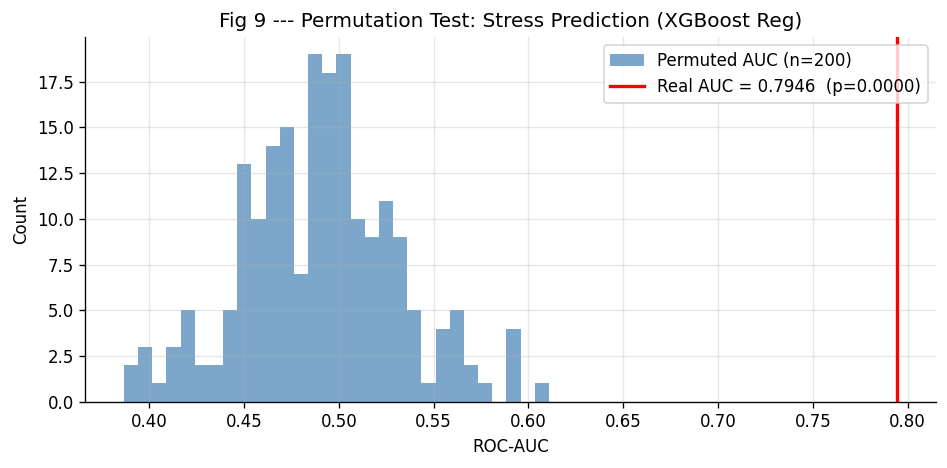

In [40]:
# === Permutation Test: Stress Prediction (XGBoost Reg) ===
# Null hypothesis: y_stress has no relationship with X (liquidity features).
# Procedure: shuffle training labels 200 times, refit XGBoost Reg each time,
# evaluate on the REAL test labels. If real AUC >> permuted distribution,
# the result is not a statistical artefact.
print('=== Permutation Test: Stress Prediction (XGBoost Reg, n=200) ===')

_n_perm = 200
_rng_p  = np.random.default_rng(42)
_perm_aucs = []

_sw_base = int((y_tr_stress_liq == 0).sum()) / max(int((y_tr_stress_liq == 1).sum()), 1)
_X_tr_perm = X_tr_liq.values if hasattr(X_tr_liq, 'values') else X_tr_liq
_X_te_perm = X_te_liq.values if hasattr(X_te_liq, 'values') else X_te_liq

for _pi in range(_n_perm):
    _y_perm = _rng_p.permutation(y_tr_stress_liq.values)
    _sw_p   = int((_y_perm == 0).sum()) / max(int((_y_perm == 1).sum()), 1)
    _mp = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        scale_pos_weight=_sw_p, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', verbosity=0
    )
    _mp.fit(_X_tr_perm, _y_perm)
    _perm_aucs.append(
        roc_auc_score(y_te_stress_liq, _mp.predict_proba(_X_te_perm)[:, 1])
    )

_real_auc = roc_tree_s_reg
_p_val    = float((np.array(_perm_aucs) >= _real_auc).mean())

print(f'  Real AUC  (XGBoost Reg): {_real_auc:.4f}')
print(f'  Permuted  mean={np.mean(_perm_aucs):.4f}  std={np.std(_perm_aucs):.4f}  '
      f'max={max(_perm_aucs):.4f}')
print(f'  p-value (fraction of permuted runs >= real AUC): {_p_val:.4f}')
if _p_val == 0.0:
    print(f'  => p < {1/_n_perm:.4f}: real AUC exceeds ALL {_n_perm} permuted runs.')
elif _p_val < 0.05:
    print(f'  => Significant at 5%: real AUC exceeds {(1-_p_val)*100:.1f}% of permuted runs.')
else:
    print(f'  => Not significant: permuted models occasionally match the real AUC.')

fig_p, ax_p = plt.subplots(figsize=(8, 4))
ax_p.hist(_perm_aucs, bins=30, color='steelblue', alpha=0.7,
          label=f'Permuted AUC (n={_n_perm})')
ax_p.axvline(_real_auc, color='red', lw=2,
             label=f'Real AUC = {_real_auc:.4f}  (p={_p_val:.4f})')
ax_p.set_xlabel('ROC-AUC')
ax_p.set_ylabel('Count')
ax_p.set_title('Fig 9 --- Permutation Test: Stress Prediction (XGBoost Reg)')
ax_p.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_permutation_test.png', bbox_inches='tight')
plt.show()


The TimeSeriesSplit results show that the improvement from liquidity features is not uniform across time. In Fold 1, the liquidity-augmented logistic model underperforms the price-only baseline, suggesting that the added liquidity variables are not consistently informative in the earliest test period. However, the liquidity model outperforms the baseline in Folds 2вЂ“5 and achieves a higher mean AUC across folds. This indicates that liquidity information generally improves stress prediction, but its usefulness is time-varying rather than stable across all market regimes.

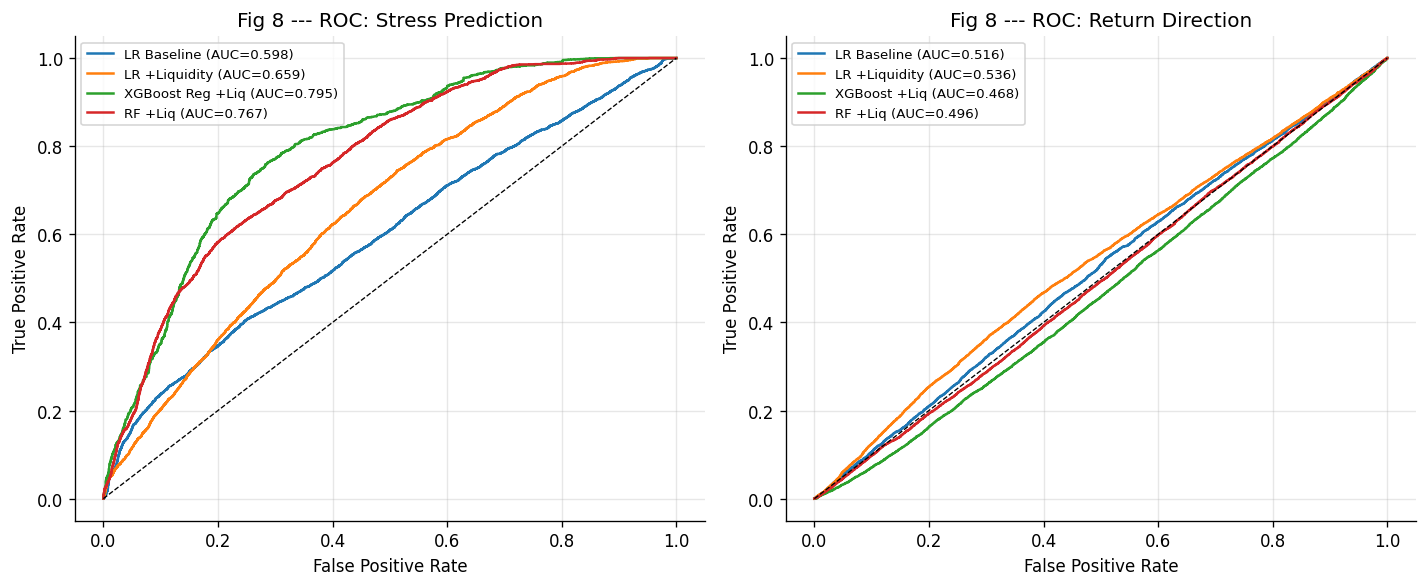

In [41]:
# ------ ROC curves --------
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (Xb_te, Xl_te, yb_te, yl_te, Xl_te_raw, title) in zip(axes, [
    (X_te_base_sc, X_te_liq_sc, y_te_stress, y_te_stress_liq, X_te_liq, 'Stress Prediction'),
    (X_te_base_r_sc, X_te_liq_r_sc, y_te_ret, y_te_ret_liq, X_te_liq_r, 'Return Direction')
]):
    models_ax = [
        (lr_base_ret if title=='Return Direction' else lr_base_stress, Xb_te,     yb_te, 'LR Baseline'),
        (lr_liq_ret  if title=='Return Direction' else lr_liq_stress,  Xl_te,     yl_te, 'LR +Liquidity'),
        (tree_ret    if title=='Return Direction' else tree_stress,     Xl_te_raw, yl_te, 'XGBoost Reg +Liq' if title=='Stress Prediction' else 'XGBoost +Liq'),
        (rf_ret      if title=='Return Direction' else rf_stress,       Xl_te_raw, yl_te, 'RF +Liq'),
    ]
    for model_ax, X_ax, y_ax, label_ax in models_ax:
        fpr, tpr, _ = roc_curve(y_ax, model_ax.predict_proba(X_ax)[:, 1])
        auc = roc_auc_score(y_ax, model_ax.predict_proba(X_ax)[:, 1])
        ax.plot(fpr, tpr, lw=1.5, label=f'{label_ax} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Fig 8 --- ROC: {title}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_roc_curves.png', bbox_inches='tight')
plt.show()

### RQ3.3 --- Portfolio Simulation (Stress-Signal)


This simulation is intentionally illustrative and uses the full test-set universe without investability constraints. The purpose is to test whether predicted stress probabilities translate mechanically into portfolio performance.

Transaction-cost sensitivity (0–25 bps per leg), investable-universe screens (size, turnover, spread), equal-weighted vs value-weighted returns, and an extended full-dataset backtest are all covered in cells `tc_sens001`, `inv_univ_001`, and `inv_ext_001` below.

=== Table 10b: Long-Short Portfolio Performance ===
  Model   : LR +Liquidity probability model | Rebalance: daily | Legs: equal-weight
  Period  : 2025-11-04 to 2026-03-29 (145 days)
  No transaction costs. Annualisation: sqrt(365) for crypto.

  Long Q1 (least stressed)       Sharpe=-1.572  MaxDD=-49.7%  HitRate=43.4%  CumRet=-38.6%
  Short Q5 (most stressed, inv.) Sharpe=-1.446  MaxDD=-27.8%  HitRate=51.7%  CumRet=-20.7%
  Long-Short (Q1 minus Q5)       Sharpe=-2.577  MaxDD=-57.4%  HitRate=46.2%  CumRet=-49.5%


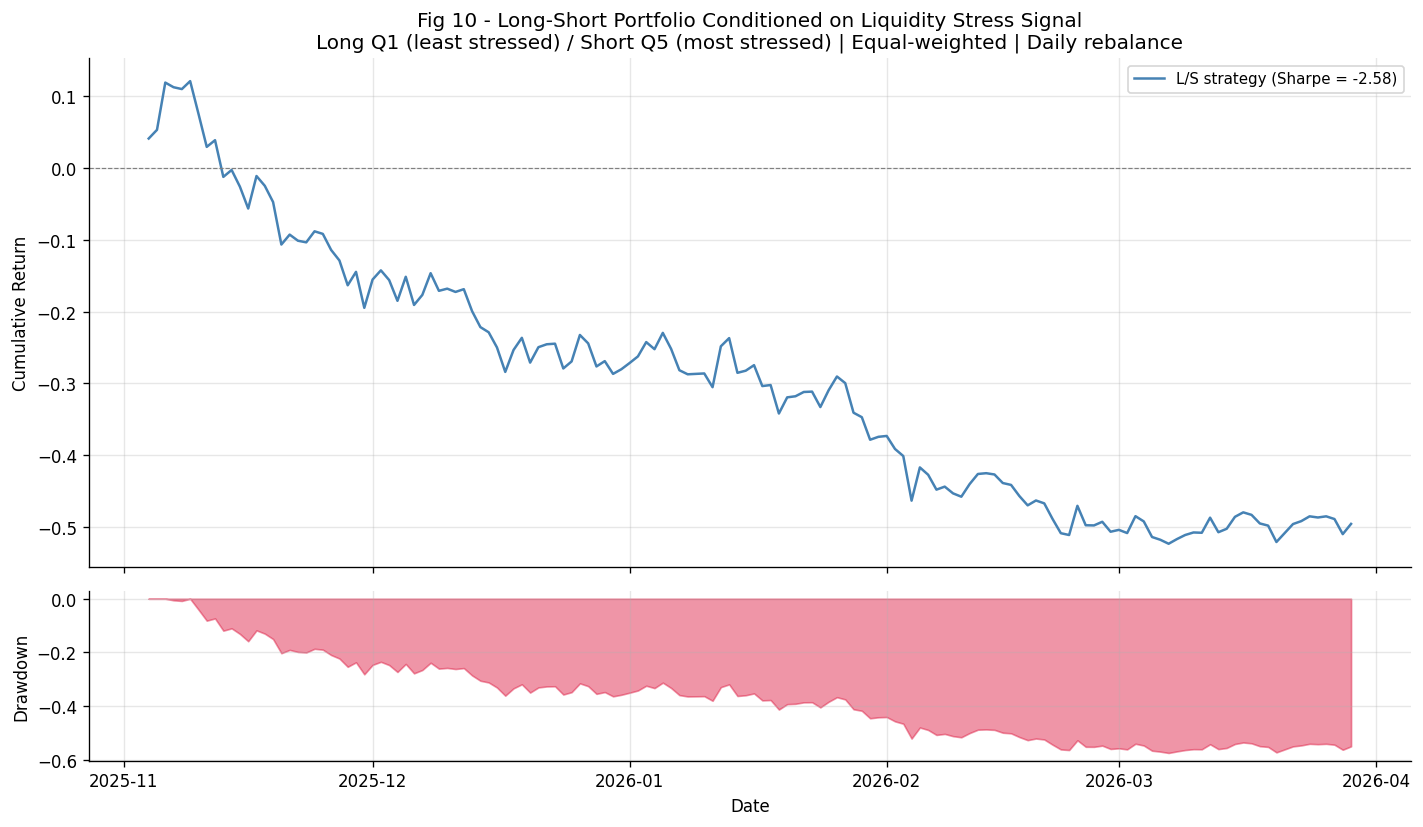

Saved: c:\Users\P.Gocheva\Desktop\thesis\notebooks\fig10_ls_portfolio.png


In [42]:
# Strategy: at end of day t, sort all assets by predicted stress probability.
# Go long the least-stressed quintile (Q1) and short the most-stressed quintile (Q5).
# Equal-weight within each leg; no transaction costs or short-selling constraints.
# Crypto markets trade continuously; annualisation uses sqrt(365).

port_df = test.dropna(subset=feat_cols_liq + ['next_ret']).copy()
X_port_sc = sc_liq.transform(port_df[feat_cols_liq])
port_df['stress_prob'] = lr_liq_stress_prob.predict_proba(X_port_sc)[:, 1]

# Require >= 10 assets per day for a meaningful quintile sort.
day_n = port_df.groupby('date')['symbol'].count()
port_df = port_df[port_df['date'].isin(day_n[day_n >= 10].index)].copy()

if port_df.empty:
    raise ValueError('No portfolio dates remain after the minimum-assets filter.')

# Quintile 0 = least stressed (long), 4 = most stressed (short).
port_df['q'] = port_df.groupby('date')['stress_prob'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 5, labels=False)
)

long_ret = port_df[port_df['q'] == 0].groupby('date')['next_ret'].mean()
short_ret = port_df[port_df['q'] == 4].groupby('date')['next_ret'].mean()
dates_ls = long_ret.index.intersection(short_ret.index)
if len(dates_ls) == 0:
    raise ValueError('No dates have both long and short portfolio legs.')
ls_ret = long_ret.loc[dates_ls] - short_ret.loc[dates_ls]

def _perf(ret, label, ann=365):
    mu = ret.mean()
    sig = ret.std()
    sr = (mu / sig * np.sqrt(ann)) if sig > 0 else np.nan
    cum = (1 + ret).cumprod()
    mdd = ((cum / cum.cummax()) - 1).min()
    hit = (ret > 0).mean()
    tot = cum.iloc[-1] - 1
    print(f'  {label:<30} Sharpe={sr:+.3f}  MaxDD={mdd:.1%}  '
          f'HitRate={hit:.1%}  CumRet={tot:+.1%}')
    return cum

print('=== Table 10b: Long-Short Portfolio Performance ===')
print('  Model   : LR +Liquidity probability model | Rebalance: daily | Legs: equal-weight')
print(f'  Period  : {dates_ls[0].date()} to {dates_ls[-1].date()} ({len(dates_ls)} days)')
print('  No transaction costs. Annualisation: sqrt(365) for crypto.')
print()
cum_long = _perf(long_ret.loc[dates_ls], 'Long Q1 (least stressed)')
cum_short_inv = _perf(-short_ret.loc[dates_ls], 'Short Q5 (most stressed, inv.)')
cum_ls = _perf(ls_ret, 'Long-Short (Q1 minus Q5)')

cum_ls_plot = (1 + ls_ret).cumprod() - 1
rolling_max = (1 + ls_ret).cumprod().cummax()
dd = ((1 + ls_ret).cumprod() / rolling_max) - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
sr_ls = ls_ret.mean() / ls_ret.std() * np.sqrt(365)
axes[0].plot(dates_ls, cum_ls_plot.values, color='steelblue', lw=1.5,
             label=f'L/S strategy (Sharpe = {sr_ls:.2f})')
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title(
    'Fig 10 - Long-Short Portfolio Conditioned on Liquidity Stress Signal\n'
    'Long Q1 (least stressed) / Short Q5 (most stressed) | Equal-weighted | Daily rebalance'
)
axes[0].legend(fontsize=9)

axes[1].fill_between(dates_ls, dd.values, 0, color='crimson', alpha=0.45)
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_ls_portfolio.png', bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "fig10_ls_portfolio.png"}')

In [43]:
# ------ Transaction Cost Sensitivity (Long-Short Portfolio) --------
# Daily rebalancing in crypto micro-caps can cost >100 bps per leg.
# Sweep a range of round-trip costs to find the Sharpe break-even level.

print('=== Transaction Cost Sensitivity (Long-Short Portfolio) ===')
print(f'  Period : {dates_ls[0].date()} to {dates_ls[-1].date()} ({len(dates_ls)} days)')
print(f"  {'Cost (bps)':<12} {'CumRet':>10} {'Ann.Sharpe':>12} {'Viable?':>8}")
print('  ' + '-'*46)
for bps in [0, 25, 50, 100, 150, 200]:
    tc        = bps / 10_000
    ls_ret_tc = ls_ret - 2 * tc          # two legs charged each rebalancing day
    cum_tc    = (1 + ls_ret_tc).cumprod()
    tot_tc    = cum_tc.iloc[-1] - 1
    sig_tc    = ls_ret_tc.std()
    sr_tc     = (ls_ret_tc.mean() / sig_tc * np.sqrt(365)) if sig_tc > 0 else np.nan
    viable    = 'Yes' if sr_tc > 0.5 else ('Marginal' if sr_tc > 0 else 'No')
    tag       = '  <- baseline (no costs)' if bps == 0 else ''
    print(f'  {bps:<12} {tot_tc:>+10.1%} {sr_tc:>+12.3f} {viable:>8}{tag}')
print()
print('Note: crypto micro-cap round-trip costs often exceed 100 bps per leg.')
print('The strategy is economically viable only for the most liquid assets')
print('or if rebalancing frequency is reduced (e.g., weekly).')


=== Transaction Cost Sensitivity (Long-Short Portfolio) ===
  Period : 2025-11-04 to 2026-03-29 (145 days)
  Cost (bps)       CumRet   Ann.Sharpe  Viable?
  ----------------------------------------------
  0                -49.5%       -2.577       No  <- baseline (no costs)
  25               -75.7%       -5.633       No
  50               -88.3%       -8.689       No
  100              -97.3%      -14.800       No
  150              -99.4%      -20.912       No
  200              -99.9%      -27.023       No

Note: crypto micro-cap round-trip costs often exceed 100 bps per leg.
The strategy is economically viable only for the most liquid assets
or if rebalancing frequency is reduced (e.g., weekly).


### RQ3.4 --- Early-Warning Liquidity Risk System

LR  thresholds (90/97/99 pct of train): [np.float64(0.168), np.float64(0.2223), np.float64(0.266)]
Tree thresholds (90/97/99 pct of train): [np.float64(0.6761), np.float64(0.7186), np.float64(0.7592)]
Base stress rate (test): 11.7%  |  N obs: 28,738

=== Table 11a: Early-Warning Tiers - LR +Liquidity Probability Model ===
Hit Rate / FAR = cumulative from this tier upward (action = flag this tier+)
               N  % obs  Precision  Hit Rate (cum)  FAR (cum)
Tier                                                         
Normal     27057   94.2      0.109           1.000      1.000
Watchlist   1165    4.1      0.200           0.122      0.050
Elevated     253    0.9      0.265           0.053      0.013
High         263    0.9      0.430           0.034      0.006

=== Table 11b: Early-Warning Tiers --- XGBoost Reg ===
               N  % obs  Precision  Hit Rate (cum)  FAR (cum)
Tier                                                         
Normal     26868   93.5      0.100           1.

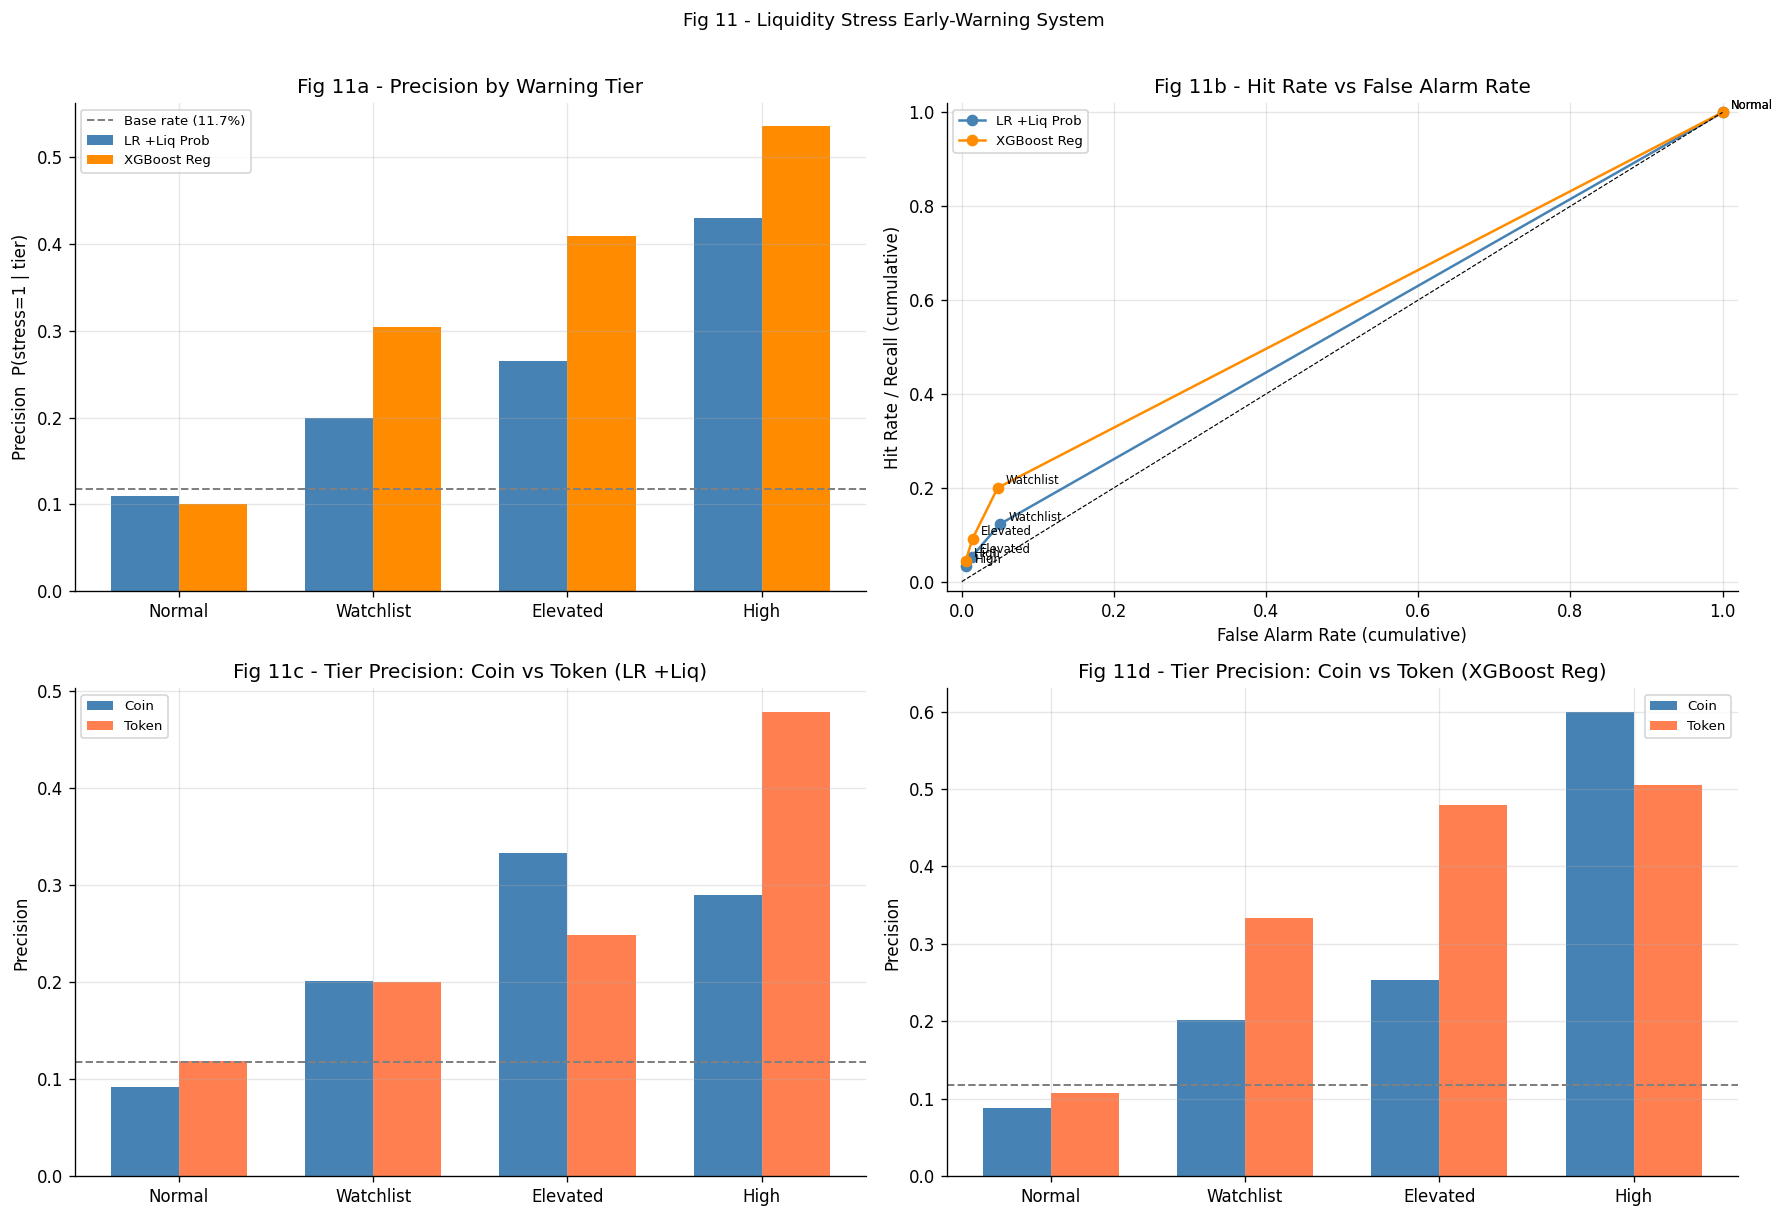

Saved: c:\Users\P.Gocheva\Desktop\thesis\notebooks\fig11_early_warning.png


In [44]:
# ------ RQ3.4: Early-Warning Liquidity Risk System --------
# Translates predicted stress probabilities into 4 warning tiers and evaluates
# tier precision, hit rate, false alarm rate, and cross-sectional variation
# (coin vs token; market-cap quartile).
# This answers: "If a risk manager acts on each warning tier, what does she get?"
#
# Tier thresholds are set from training-set predicted probabilities (90/97/99th
# percentiles), applied to the test set. This is invariant to probability-scale
# shifts across model versions. Separate thresholds per model (LR / XGBoost)
# because both have different probability distributions.
# Population fractions targeted: Normal 90%, Watchlist 7%, Elevated 2%, High 1%.

ew_df = test.dropna(subset=feat_cols_liq + ['target_stress', 'cat', 'log_mcap']).copy()

X_ew_sc        = sc_liq.transform(ew_df[feat_cols_liq])
ew_df['p_lr'] = lr_liq_stress_prob.predict_proba(X_ew_sc)[:, 1]
ew_df['p_tree'] = tree_stress.predict_proba(ew_df[feat_cols_liq])[:, 1]

BASE_RATE = ew_df['target_stress'].mean()

# Quantile thresholds from training-set predictions (no test-set look-ahead)
_tr_valid  = train.dropna(subset=feat_cols_liq + ['target_stress'])
_X_tr_ew   = sc_liq.transform(_tr_valid[feat_cols_liq])
_p_tr_lr   = lr_liq_stress_prob.predict_proba(_X_tr_ew)[:, 1]
_p_tr_tree = tree_stress.predict_proba(_tr_valid[feat_cols_liq])[:, 1]

_qt_lr   = np.quantile(_p_tr_lr,   [0.90, 0.97, 0.99])
_qt_tree = np.quantile(_p_tr_tree, [0.90, 0.97, 0.99])

TIERS_LR   = [('Normal',    0.00,       _qt_lr[0]),
              ('Watchlist', _qt_lr[0],  _qt_lr[1]),
              ('Elevated',  _qt_lr[1],  _qt_lr[2]),
              ('High',      _qt_lr[2],  1.01)]
TIERS_TREE = [('Normal',    0.00,        _qt_tree[0]),
              ('Watchlist', _qt_tree[0], _qt_tree[1]),
              ('Elevated',  _qt_tree[1], _qt_tree[2]),
              ('High',      _qt_tree[2], 1.01)]
TIERS = TIERS_LR   # default for LR-centric stratified analysis

print(f'LR  thresholds (90/97/99 pct of train): {[round(q, 4) for q in _qt_lr]}')
print(f'Tree thresholds (90/97/99 pct of train): {[round(q, 4) for q in _qt_tree]}')

def _tier_stats(df, prob_col, tiers):
    y, p = df['target_stress'].astype(int), df[prob_col]
    rows = []
    for tier, lo, hi in tiers:
        mask = (p >= lo) & (p < hi)
        n    = int(mask.sum())
        prec = float(y[mask].mean())                   if n > 0       else np.nan
        cum  = p >= lo
        hit  = float(y[cum].sum() / y.sum())           if y.sum() > 0 else np.nan
        far  = float((1-y)[cum].sum() / (1-y).sum())  if (1-y).sum() > 0 else np.nan
        rows.append({'Tier': tier, 'N': n,
                     '% obs': round(100 * n / len(df), 1),
                     'Precision': round(prec, 3),
                     'Hit Rate (cum)': round(hit, 3),
                     'FAR (cum)': round(far, 3)})
    return pd.DataFrame(rows).set_index('Tier')

print(f'Base stress rate (test): {BASE_RATE:.1%}  |  N obs: {len(ew_df):,}')
print()
print('=== Table 11a: Early-Warning Tiers - LR +Liquidity Probability Model ===')
print('Hit Rate / FAR = cumulative from this tier upward (action = flag this tier+)')
tbl_lr   = _tier_stats(ew_df, 'p_lr', TIERS_LR)
print(tbl_lr.to_string())
print()
print(f'=== Table 11b: Early-Warning Tiers --- {model_name} ===')
tbl_tree = _tier_stats(ew_df, 'p_tree', TIERS_TREE)
print(tbl_tree.to_string())

# ------ Table 11c: Precision by tier -- asset category (LR) --------
print('\n=== Table 11c: Precision by Tier - Coin vs Token (LR +Liq Probability) ===')
strat_rows = []
for cat_val in ['coin', 'token']:
    sub = ew_df[ew_df['cat'] == cat_val]
    if len(sub) < 20:
        continue
    for tier, lo, hi in TIERS_LR:
        mask = (sub['p_lr'] >= lo) & (sub['p_lr'] < hi)
        n    = int(mask.sum())
        prec = float(sub.loc[mask, 'target_stress'].mean()) if n > 0 else np.nan
        strat_rows.append({'Category': cat_val.capitalize(), 'Tier': tier,
                           'N': n, 'Precision': round(prec, 3)})
strat_df = pd.DataFrame(strat_rows)
tier_order = [t[0] for t in TIERS_LR]
if not strat_df.empty:
    pvt = (strat_df.pivot(index='Tier', columns='Category', values='Precision')
                   .reindex(tier_order))
    print(pvt.to_string())
    base_by_cat = '  '.join(
        f'{c}: {ew_df.loc[ew_df["cat"]==c.lower(),"target_stress"].mean():.1%}'
        for c in pvt.columns if (ew_df['cat'] == c.lower()).any()
    )
    print(f'Base rate by category: {base_by_cat}')

# ------ Table 11d: Precision by tier -- market-cap quartile (LR) --------
print('\n=== Table 11d: Precision by Tier - Market-Cap Quartile (LR +Liq Probability) ===')
ew_df['mcap_q'] = pd.qcut(ew_df['log_mcap'].rank(method='first'), 4,
                           labels=['Q1 small', 'Q2', 'Q3', 'Q4 large'])
mcap_rows = []
for q in ['Q1 small', 'Q2', 'Q3', 'Q4 large']:
    sub = ew_df[ew_df['mcap_q'] == q]
    if len(sub) < 20:
        continue
    for tier, lo, hi in TIERS_LR:
        mask = (sub['p_lr'] >= lo) & (sub['p_lr'] < hi)
        n    = int(mask.sum())
        prec = float(sub.loc[mask, 'target_stress'].mean()) if n > 0 else np.nan
        mcap_rows.append({'McapQ': str(q), 'Tier': tier, 'N': n, 'Precision': round(prec, 3)})
mcap_df = pd.DataFrame(mcap_rows)
if not mcap_df.empty:
    pvt_m = (mcap_df.pivot(index='Tier', columns='McapQ', values='Precision')
                    .reindex(tier_order))
    print(pvt_m.to_string())
    base_by_q = '  '.join(
        f'{q}: {ew_df.loc[ew_df["mcap_q"]==q,"target_stress"].mean():.1%}'
        for q in ['Q1 small','Q2','Q3','Q4 large']
    )
    print(f'Base rate by quartile: {base_by_q}')

# ------ Table 11e: Precision by tier -- asset category (XGBoost) --------
print(f'\n=== Table 11e: Precision by Tier - Coin vs Token ({model_name}) ===')
tier_order_tree = [t[0] for t in TIERS_TREE]
strat_rows_tree = []
for cat_val in ['coin', 'token']:
    sub = ew_df[ew_df['cat'] == cat_val]
    if len(sub) < 20:
        continue
    for tier, lo, hi in TIERS_TREE:
        mask = (sub['p_tree'] >= lo) & (sub['p_tree'] < hi)
        n    = int(mask.sum())
        prec = float(sub.loc[mask, 'target_stress'].mean()) if n > 0 else np.nan
        strat_rows_tree.append({'Category': cat_val.capitalize(), 'Tier': tier,
                                'N': n, 'Precision': round(prec, 3)})
strat_df_tree = pd.DataFrame(strat_rows_tree)
if not strat_df_tree.empty:
    pvt_tree_cat = (strat_df_tree.pivot(index='Tier', columns='Category', values='Precision')
                                 .reindex(tier_order_tree))
    print(pvt_tree_cat.to_string())
    base_by_cat_tree = '  '.join(
        f'{c}: {ew_df.loc[ew_df["cat"]==c.lower(),"target_stress"].mean():.1%}'
        for c in pvt_tree_cat.columns if (ew_df['cat'] == c.lower()).any()
    )
    print(f'Base rate by category: {base_by_cat_tree}')

# ------ Table 11f: Precision by tier -- market-cap quartile (XGBoost) --------
print(f'\n=== Table 11f: Precision by Tier - Market-Cap Quartile ({model_name}) ===')
mcap_rows_tree = []
for q in ['Q1 small', 'Q2', 'Q3', 'Q4 large']:
    sub = ew_df[ew_df['mcap_q'] == q]
    if len(sub) < 20:
        continue
    for tier, lo, hi in TIERS_TREE:
        mask = (sub['p_tree'] >= lo) & (sub['p_tree'] < hi)
        n    = int(mask.sum())
        prec = float(sub.loc[mask, 'target_stress'].mean()) if n > 0 else np.nan
        mcap_rows_tree.append({'McapQ': str(q), 'Tier': tier, 'N': n, 'Precision': round(prec, 3)})
mcap_df_tree = pd.DataFrame(mcap_rows_tree)
if not mcap_df_tree.empty:
    pvt_m_tree = (mcap_df_tree.pivot(index='Tier', columns='McapQ', values='Precision')
                              .reindex(tier_order_tree))
    print(pvt_m_tree.to_string())
    base_by_q_tree = '  '.join(
        f'{q}: {ew_df.loc[ew_df["mcap_q"]==q,"target_stress"].mean():.1%}'
        for q in ['Q1 small','Q2','Q3','Q4 large']
    )
    print(f'Base rate by quartile: {base_by_q_tree}')

print()
print('Note: some quartile-tier cells (especially Q3 and Q4 at the High tier) are')
print('based on a small number of flagged observations. Precision estimates for')
print('these cells should be treated as descriptive rather than stable performance')
print('estimates. Cells with N < 10 should not be interpreted individually.')

# ------ Fig 11: Early-warning system visualisation (2x2) --------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Panel A: precision by tier --- LR vs XGBoost
x, w = np.arange(len(tier_order)), 0.35
axes[0].bar(x - w/2, tbl_lr['Precision'].fillna(0),   w, color='steelblue',  label='LR +Liq Prob')
axes[0].bar(x + w/2, tbl_tree['Precision'].fillna(0), w, color='darkorange', label=model_name)
axes[0].axhline(BASE_RATE, color='gray', ls='--', lw=1.2, label=f'Base rate ({BASE_RATE:.1%})')
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_order)
axes[0].set_ylabel('Precision  P(stress=1 | tier)')
axes[0].set_title('Fig 11a - Precision by Warning Tier')
axes[0].legend(fontsize=8)

# Panel B: hit rate vs false alarm rate (operating point per tier threshold)
for prob_col, lbl, col in [('p_lr', 'LR +Liq Prob', 'steelblue'),
                             ('p_tree', model_name, 'darkorange')]:
    y, p = ew_df['target_stress'].astype(int), ew_df[prob_col]
    hits, fars = [], []
    for _, lo, _ in (TIERS_LR if prob_col == 'p_lr' else TIERS_TREE):
        cum  = p >= lo
        hits.append(y[cum].sum() / y.sum()         if y.sum() > 0   else np.nan)
        fars.append((1-y)[cum].sum() / (1-y).sum() if (1-y).sum() > 0 else np.nan)
    axes[1].plot(fars, hits, 'o-', color=col, label=lbl, lw=1.5)
    for i, tier in enumerate(tier_order):
        axes[1].annotate(tier, (fars[i], hits[i]),
                         textcoords='offset points', xytext=(5, 2), fontsize=7)
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.7)
axes[1].set_xlabel('False Alarm Rate (cumulative)')
axes[1].set_ylabel('Hit Rate / Recall (cumulative)')
axes[1].set_title('Fig 11b - Hit Rate vs False Alarm Rate')
axes[1].legend(fontsize=8)
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)

# Panel C: precision by tier --- coin vs token (LR)
if not strat_df.empty:
    pvt_p  = pvt.copy()
    cats_p = [c for c in ['Coin', 'Token'] if c in pvt_p.columns]
    bar_c  = {'Coin': 'steelblue', 'Token': 'coral'}
    x3, w3 = np.arange(len(tier_order)), 0.35
    for j, cat in enumerate(cats_p):
        offset = (j - len(cats_p) / 2 + 0.5) * w3
        axes[2].bar(x3 + offset, pvt_p[cat].fillna(0), w3,
                    color=bar_c.get(cat, 'gray'), label=cat)
    axes[2].axhline(BASE_RATE, color='gray', ls='--', lw=1.2)
    axes[2].set_xticks(x3); axes[2].set_xticklabels(tier_order)
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Fig 11c - Tier Precision: Coin vs Token (LR +Liq)')
    axes[2].legend(fontsize=8)

# Panel D: precision by tier --- coin vs token (XGBoost)
if not strat_df_tree.empty:
    bar_c  = {'Coin': 'steelblue', 'Token': 'coral'}
    cats_t = [c for c in ['Coin', 'Token'] if c in pvt_tree_cat.columns]
    x4, w4 = np.arange(len(tier_order_tree)), 0.35
    for j, cat in enumerate(cats_t):
        offset = (j - len(cats_t) / 2 + 0.5) * w4
        axes[3].bar(x4 + offset, pvt_tree_cat[cat].fillna(0), w4,
                    color=bar_c.get(cat, 'gray'), label=cat)
    axes[3].axhline(BASE_RATE, color='gray', ls='--', lw=1.2)
    axes[3].set_xticks(x4); axes[3].set_xticklabels(tier_order_tree)
    axes[3].set_ylabel('Precision')
    axes[3].set_title(f'Fig 11d - Tier Precision: Coin vs Token ({model_name})')
    axes[3].legend(fontsize=8)

plt.suptitle('Fig 11 - Liquidity Stress Early-Warning System', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_early_warning.png', bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "fig11_early_warning.png"}')

The early-warning results should be interpreted as probabilistic screening rather than automatic intervention. The LR + Liquidity model identifies a small High-risk group with substantial lift over the base stress rate, but the signal still produces false alarms and captures only a limited share of total stress events at the strict High threshold. The model is therefore more suitable for watchlists, exposure review, and liquidity monitoring than for automatic trading or forced liquidation decisions.


The cross-sectional breakdown shows that the early-warning system is most useful for smaller assets. In the smallest market-cap quartile, the High-risk tier has much higher realized stress precision than the unconditional stress rate, while large-cap assets have very low base stress prevalence and limited warning-system usefulness. This suggests that the modelвЂ™s managerial relevance is concentrated in monitoring smaller and structurally fragile assets rather than large, liquid crypto assets.

---
## 6. Final Interpretation

> Research-style summary --- numbers below are read from the tables above and should be verified against actual output.

In [45]:
print("""
THESIS - STRUCTURED RESEARCH SUMMARY

DATASET
  Daily crypto-asset panel, Apr 2024 - Mar 2026.
  Categories: coin and token.
  Zero-volume days excluded from liquidity calculations.
  Liquidity proxies winsorised at the 1st/99th percentile.

RQ1.1 - Liquidity Proxy Behaviour
  - Amihud illiquidity is right-skewed and highly dispersed across assets.
  - Turnover is also skewed, with thinly traded assets showing near-zero turnover.
  - Corwin-Schultz spread is estimated from consecutive OHLC pairs and replaces
    the older range-based pilot proxy when the rebuilt panel is available.
  - Coins generally show lower Amihud and higher turnover than tokens.

RQ1.2 - Stress Labels
  - The strict stress rule flags the overlap of high Amihud and low turnover.
  - Stressed days are associated with smaller market cap, lower turnover,
    and higher volatility. Return differences are present but small and
    should be interpreted cautiously (Table 4).
  - Stress thresholds are expanding-window quantiles, avoiding look-ahead bias.

RQ1.3 - Market-Wide Liquidity Factor
  - The notebook now plots and reports the selected market factor consistently:
    PCA PC1 when available, otherwise the Amihud z-score factor.
  - Table 5 estimates asset fixed effects with asset-clustered SEs when
    linearmodels is installed, with a demeaned OLS fallback.

RQ2 - Liquidity Stress and Large Negative Returns
  - Crash days are associated with higher illiquidity, wider spreads, and
    higher volatility. Turnover may also rise due to intensified selling
    activity, so its direction on crash days is interpreted with care (Table 6).
  - Stress and crash labels are statistically related in the contingency table.
  - The joint logit includes VIF diagnostics to separate partial effects from
    collinearity artefacts.

RQ3 - Prediction and Managerial Use
  - Liquidity features improve next-day liquidity stress prediction relative to price-only baselines.
  - Return direction remains difficult to predict, with ROC-AUC close to random classification.
  - XGBoost provides the strongest ranking performance for stress prediction.
  - The logistic liquidity model provides more operationally interpretable warning probabilities.
  - The early-warning system is best understood as a screening tool for fragile assets, especially 
      smaller-cap tokens, rather than as an automatic trading or intervention rule.

REMAINING LIMITATIONS
  1. The panel covers Apr 2024 - Mar 2026, so results may vary in other regimes.
  2. Asset-level prediction is pooled; asset-demeaned or within-asset models
     may reduce cross-sectional confounding.
""")


THESIS - STRUCTURED RESEARCH SUMMARY

DATASET
  Daily crypto-asset panel, Apr 2024 - Mar 2026.
  Categories: coin and token.
  Zero-volume days excluded from liquidity calculations.
  Liquidity proxies winsorised at the 1st/99th percentile.

RQ1.1 - Liquidity Proxy Behaviour
  - Amihud illiquidity is right-skewed and highly dispersed across assets.
  - Turnover is also skewed, with thinly traded assets showing near-zero turnover.
  - Corwin-Schultz spread is estimated from consecutive OHLC pairs and replaces
    the older range-based pilot proxy when the rebuilt panel is available.
  - Coins generally show lower Amihud and higher turnover than tokens.

RQ1.2 - Stress Labels
  - The strict stress rule flags the overlap of high Amihud and low turnover.
  - Stressed days are associated with smaller market cap, lower turnover,
    and higher volatility. Return differences are present but small and
    should be interpreted cautiously (Table 4).
  - Stress thresholds are expanding-window q

### Appendix: Additional Diagnostics

Optional checks for the Amihud-z outlier date, portfolio quintiles, and RQ2 collinearity.

In [46]:
# Amihud-z outlier diagnostic for a specific date.
diag_date = pd.Timestamp('2025-12-11')
diag_cols = [c for c in ['symbol', 'amihud_z', 'amihud_raw', 'volume', 'market_cap', 'ret']
             if c in df_clean.columns]

(df_clean.loc[df_clean['date'] == diag_date, diag_cols]
         .sort_values('amihud_z', ascending=False)
         .head(10))

,symbol,amihud_z,amihud_raw,volume,market_cap,ret
190993,5328,15.758699,9.282781e-03,1.71,142626.26,-0.183605
172896,4586,15.758699,4.716192e-05,422.72,0.00,0.186732
205078,5647,12.463604,4.545688e-07,64495.93,3779276.22,-0.048014
163598,4119,10.906805,3.660943e-05,821.57,0.00,-0.064173
101617,2861,9.839157,2.848068e-04,140.83,1137235.50,-0.071227
139402,3768,8.773520,2.188275e-05,45745.07,4512514.87,-0.020042
86498,2638,8.206717,2.845577e-08,893919.50,3177131.28,-0.064243
40924,2081,7.863444,3.684817e-06,85.43,924755.12,0.404163
106242,2915,6.539882,1.028411e-07,310746.83,15615849.87,-0.021842
23645,1834,6.122003,5.967332e-03,13.37,144601.69,-0.154561


In [47]:
# Portfolio quintile and avoidance diagnostics.
q_ret = port_df.groupby('q')['next_ret'].agg(['mean', 'median', 'std', 'count'])

avoid_ret = port_df[port_df['q'] < 4].groupby('date')['next_ret'].mean()
bench_ret = port_df.groupby('date')['next_ret'].mean()
sized = port_df.assign(weight=np.where(port_df['q'] == 4, 0.5, 1.0)).copy()
sized['weight'] = sized.groupby('date')['weight'].transform(lambda x: x / x.sum())
sized_ret = sized.assign(weighted_ret=sized['weight'] * sized['next_ret']).groupby('date')['weighted_ret'].sum()

q4_daily = port_df[port_df['q'] == 4].groupby('date')['next_ret'].mean()
q03_daily = port_df[port_df['q'] < 4].groupby('date')['next_ret'].mean()

print('Next-day returns by stress quintile:')
print(q_ret.round(5).to_string())
print('\nStrategy diagnostics:')
print(pd.Series({
    'Q5 mean next_ret': port_df.loc[port_df['q'] == 4, 'next_ret'].mean(),
    'Avoid-Q5 mean': avoid_ret.mean(),
    'Benchmark mean': bench_ret.mean(),
    'Avoid-Q5 std': avoid_ret.std(),
    'Benchmark std': bench_ret.std(),
    'Half-weight-Q5 mean': sized_ret.mean(),
    'Half-weight-Q5 std': sized_ret.std(),
    'Corr(Q5, Q0-Q3)': q4_daily.corr(q03_daily),
}).round(5).to_string())

Next-day returns by stress quintile:
      mean   median      std  count
q                                  
0 -0.00278 -0.00606  0.04880   5823
1 -0.00336 -0.00406  0.05140   5726
2 -0.00280 -0.00421  0.05254   5734
3 -0.00280 -0.00198  0.06239   5726
4  0.00144 -0.00034  0.11789   5790

Strategy diagnostics:
Q5 mean next_ret       0.00144
Avoid-Q5 mean         -0.00294
Benchmark mean        -0.00206
Avoid-Q5 std           0.02479
Benchmark std          0.02171
Half-weight-Q5 mean   -0.00245
Half-weight-Q5 std     0.02300
Corr(Q5, Q0-Q3)        0.43418


In [48]:
# RQ2 collinearity diagnostics.
print('VIF:')
print(vif_df.round(2).to_string(index=False))
print('\nFeature correlation matrix:')
print(logit_rq2[feat_names].corr().round(3).to_string())

VIF:
    Variable  VIF
  amihud_raw 1.11
    turnover 1.01
spread_proxy 1.24
       vol20 1.35

Feature correlation matrix:
              amihud_raw  turnover  spread_proxy  vol20
amihud_raw         1.000    -0.080         0.040  0.285
turnover          -0.080     1.000         0.035  0.024
spread_proxy       0.040     0.035         1.000  0.431
vol20              0.285     0.024         0.431  1.000


In [49]:
# === Practical Prediction Metrics + LR Coefficient Table ===
# Top-decile precision/recall answers: "Does the model actually catch stress events?"
# Brier score measures probability accuracy (lower = better).
# Note: tree models are used for ranking (AUC), not as calibrated probability estimators.
#       Brier scores should be interpreted with that in mind.
from sklearn.metrics import brier_score_loss

print('=== Table: Practical Prediction Metrics (Test Set, Stress Prediction) ===')

def _practical_metrics(label, probs, y_te):
    y_te  = np.array(y_te).astype(int)
    thr10 = np.percentile(probs, 90)            # top 10% by predicted prob
    mask  = probs >= thr10
    prec  = float(y_te[mask].mean())             if mask.sum() > 0 else np.nan
    rec   = float(y_te[mask].sum() / y_te.sum()) if y_te.sum() > 0 else np.nan
    # False Alarm Share = share of flagged observations that are NOT stressed
    # (= 1 - precision). Different from true FPR = FP / all negatives.
    fal   = float((1 - y_te)[mask].mean())       if mask.sum() > 0 else np.nan
    return {
        'Model':                      label,
        'ROC-AUC':                    round(roc_auc_score(y_te, probs), 4),
        'Brier Score':                round(brier_score_loss(y_te, probs), 4),
        'Prec@Top10%':                round(prec,  4),
        'Recall@Top10%':              round(rec,   4),
        'False Alarm Share@Top10%':   round(fal,   4),
    }

_y_te_arr = np.array(y_te_stress_liq).astype(int)
_X_te_arr = X_te_liq.values if hasattr(X_te_liq, 'values') else X_te_liq

prac_rows = [
    _practical_metrics('LR +Liquidity',
                       lr_liq_stress.predict_proba(X_te_liq_sc)[:, 1], _y_te_arr),
    _practical_metrics('XGBoost Reg',
                       tree_stress.predict_proba(_X_te_arr)[:, 1], _y_te_arr),
    _practical_metrics('Random Forest',
                       rf_stress.predict_proba(_X_te_arr)[:, 1], _y_te_arr),
]
prac_df = pd.DataFrame(prac_rows).set_index('Model')
print(prac_df.to_string())
print()
_base_rate = _y_te_arr.mean()
_brier_baseline = _base_rate * (1 - _base_rate)
print(f'Naive Brier baseline (constant prob = stress rate {_base_rate:.4f}): {_brier_baseline:.4f}')
print()
print('Prec@Top10%: precision among top-10% of assets by predicted stress prob.')
print('Recall@Top10%: fraction of actual stress events captured in top decile.')
print('False Alarm Share@Top10%: share of flagged obs that are NOT stressed (= 1 - precision).')
print('Note: Brier scores exceed the naive baseline, meaning raw probabilities from')
print('      tree models are not well calibrated. Models should be used for ranking')
print('      (AUC / top-decile recall), not as direct probability estimators.')

# --- LR coefficient table ---
print()
print('=== Table: LR +Liquidity Coefficients (standardised predictors) ===')
coef_df = (pd.DataFrame({'Feature':     feat_cols_liq,
                          'Coefficient': lr_liq_stress.coef_[0]})
             .assign(**{'Odds Ratio': lambda d: np.exp(d['Coefficient'])})
             .reindex(pd.Series(lr_liq_stress.coef_[0]).abs()
                       .sort_values(ascending=False).index))
coef_df = coef_df.reset_index(drop=True)
print(coef_df.round(4).to_string(index=False))
print()
print('Positive coefficient => higher value => more likely stressed.')
print()
print('Note on pc1_lag1 (coefficient -0.2666): the negative sign is')
print('counterintuitive but interpretable. pc1_lag1 captures market-wide')
print('illiquidity. When aggregate illiquidity rises uniformly, individual')
print('assets may not rank in the top decile of their own Amihud history')
print('(which is how stress_strict is defined), so the marginal signal of')
print('the market factor is negative conditional on asset size and other features.')
print('The coefficient should not be read as a protective effect of market illiquidity.')
print()
print('Note on static metadata features (has_whitepaper, has_github, is_ico,')
print('log_raised_usd): these are time-invariant per asset and capture asset-level')
print('heterogeneity rather than short-term liquidity dynamics. Their predictive')
print('contribution may therefore overlap with fixed-effect or asset-quality')
print('differences and should not be interpreted as liquidity signals.')


=== Table: Practical Prediction Metrics (Test Set, Stress Prediction) ===
               ROC-AUC  Brier Score  Prec@Top10%  Recall@Top10%  False Alarm Share@Top10%
Model                                                                                    
LR +Liquidity   0.6593       0.2029       0.2185         0.1862                    0.7815
XGBoost Reg     0.7946       0.1711       0.3322         0.2832                    0.6678
Random Forest   0.7670       0.1692       0.3399         0.2897                    0.6601

Naive Brier baseline (constant prob = stress rate 0.1173): 0.1036

Prec@Top10%: precision among top-10% of assets by predicted stress prob.
Recall@Top10%: fraction of actual stress events captured in top decile.
False Alarm Share@Top10%: share of flagged obs that are NOT stressed (= 1 - precision).
Note: Brier scores exceed the naive baseline, meaning raw probabilities from
      tree models are not well calibrated. Models should be used for ranking
      (AUC / top-deci

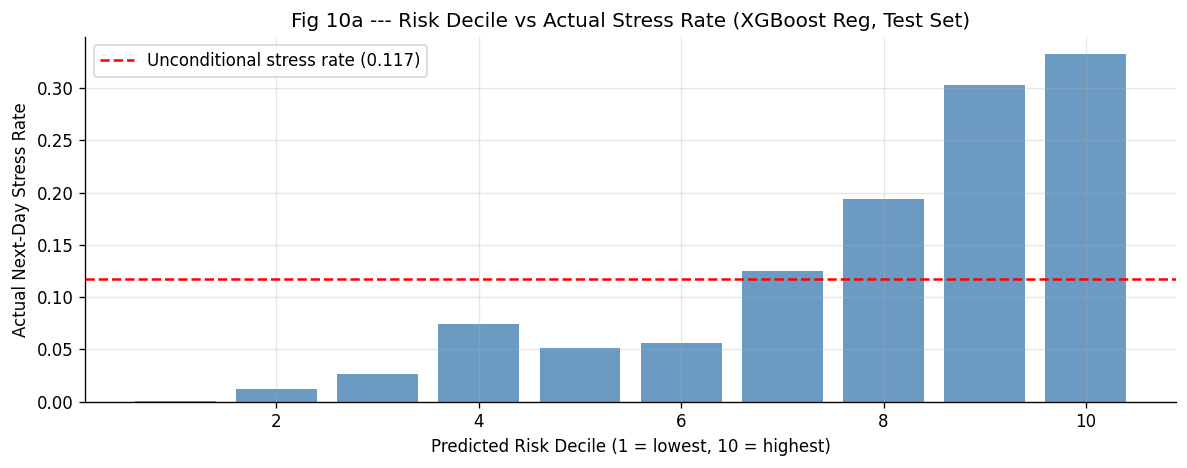

=== Decile Table ===
        stress_rate     n
decile                   
1            0.0003  2874
2            0.0122  2874
3            0.0261  2874
4            0.0741  2873
5            0.0515  2874
6            0.0560  2874
7            0.1246  2873
8            0.1935  2874
9            0.3027  2874
10           0.3323  2874

Note: stress rate is non-monotonic at deciles 4-6 (decile 5 dips below decile 4).
The tails are well-ordered: deciles 1-3 show near-zero stress, deciles 8-10 show
high stress. Middle-decile irregularity is expected when predicted probabilities
are compressed near the threshold and the ranking signal is weaker mid-distribution.


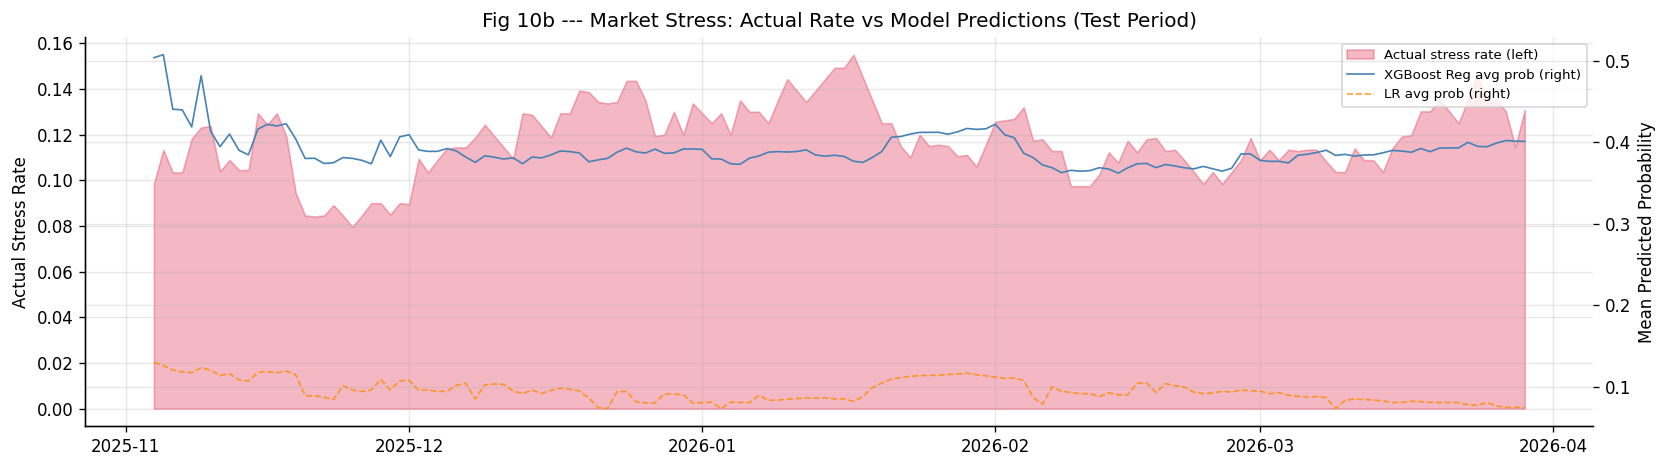

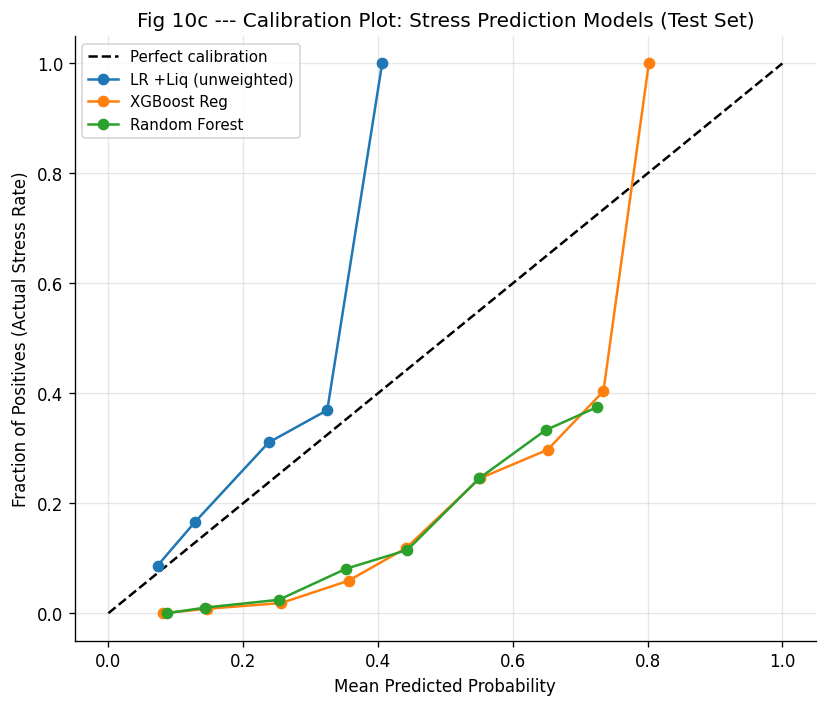

In [50]:
# === Risk Decile Chart + Time-Series Plot + Calibration Plot ===
from sklearn.calibration import calibration_curve

# --- Fig 10a: Risk Decile Chart ---
_dec_df = test.dropna(subset=feat_cols_liq + ['target_stress']).copy()
_X_dec  = _dec_df[feat_cols_liq].values if hasattr(_dec_df[feat_cols_liq], 'values') else _dec_df[feat_cols_liq]
_dec_df['p_tree'] = tree_stress.predict_proba(_X_dec)[:, 1]
_dec_df['decile'] = pd.qcut(_dec_df['p_tree'].rank(method='first'), 10, labels=range(1, 11))

decile_stats = (_dec_df.groupby('decile')['target_stress']
                        .agg(['mean', 'count'])
                        .rename(columns={'mean': 'stress_rate', 'count': 'n'}))
unconditional = _dec_df['target_stress'].mean()

fig_d, ax_d = plt.subplots(figsize=(10, 4))
ax_d.bar(decile_stats.index.astype(int), decile_stats['stress_rate'],
         color='steelblue', alpha=0.8)
ax_d.axhline(unconditional, color='red', ls='--', lw=1.5,
             label=f'Unconditional stress rate ({unconditional:.3f})')
ax_d.set_xlabel('Predicted Risk Decile (1 = lowest, 10 = highest)')
ax_d.set_ylabel('Actual Next-Day Stress Rate')
ax_d.set_title('Fig 10a --- Risk Decile vs Actual Stress Rate (XGBoost Reg, Test Set)')
ax_d.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10a_risk_decile.png', bbox_inches='tight')
plt.show()
print('=== Decile Table ===')
print(decile_stats.round(4).to_string())
print()
print('Note: stress rate is non-monotonic at deciles 4-6 (decile 5 dips below decile 4).')
print('The tails are well-ordered: deciles 1-3 show near-zero stress, deciles 8-10 show')
print('high stress. Middle-decile irregularity is expected when predicted probabilities')
print('are compressed near the threshold and the ranking signal is weaker mid-distribution.')

# --- Fig 10b: Time-Series Plot ---
_ts_df = test.dropna(subset=feat_cols_liq + ['target_stress']).copy()
_X_ts  = _ts_df[feat_cols_liq].values if hasattr(_ts_df[feat_cols_liq], 'values') else _ts_df[feat_cols_liq]
_ts_df['p_tree'] = tree_stress.predict_proba(_X_ts)[:, 1]
_ts_df['p_lr']   = lr_liq_stress_prob.predict_proba(sc_liq.transform(_ts_df[feat_cols_liq]))[:, 1]

daily_ts = (_ts_df.groupby('date')
                   .agg(actual_stress=('target_stress', 'mean'),
                        pred_tree=('p_tree', 'mean'),
                        pred_lr=('p_lr', 'mean'))
                   .reset_index())

fig_ts, ax_ts1 = plt.subplots(figsize=(14, 4))
ax_ts2 = ax_ts1.twinx()
ax_ts1.fill_between(daily_ts['date'], daily_ts['actual_stress'],
                    alpha=0.3, color='crimson', label='Actual stress rate (left)')
ax_ts2.plot(daily_ts['date'], daily_ts['pred_tree'],
            color='steelblue', lw=1, label='XGBoost Reg avg prob (right)')
ax_ts2.plot(daily_ts['date'], daily_ts['pred_lr'],
            color='darkorange', lw=1, ls='--', alpha=0.8, label='LR avg prob (right)')
ax_ts1.set_ylabel('Actual Stress Rate')
ax_ts2.set_ylabel('Mean Predicted Probability')
ax_ts1.set_title('Fig 10b --- Market Stress: Actual Rate vs Model Predictions (Test Period)')
lines1, labs1 = ax_ts1.get_legend_handles_labels()
lines2, labs2 = ax_ts2.get_legend_handles_labels()
ax_ts1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10b_timeseries_stress.png', bbox_inches='tight')
plt.show()

# --- Fig 10c: Calibration Plot ---
_cal_df = test.dropna(subset=feat_cols_liq + ['target_stress']).copy()
_y_cal  = _cal_df['target_stress'].astype(int).values
_X_cal  = _cal_df[feat_cols_liq].values if hasattr(_cal_df[feat_cols_liq], 'values') else _cal_df[feat_cols_liq]

fig_cal, ax_cal = plt.subplots(figsize=(7, 6))
ax_cal.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

for _lab, _probs in [
    ('LR +Liq (unweighted)',  lr_liq_stress_prob.predict_proba(sc_liq.transform(_cal_df[feat_cols_liq]))[:, 1]),
    ('XGBoost Reg',            tree_stress.predict_proba(_X_cal)[:, 1]),
    ('Random Forest',          rf_stress.predict_proba(_X_cal)[:, 1]),
]:
    frac_pos, mean_pred = calibration_curve(_y_cal, _probs, n_bins=10, strategy='uniform')
    ax_cal.plot(mean_pred, frac_pos, marker='o', lw=1.5, label=_lab)

ax_cal.set_xlabel('Mean Predicted Probability')
ax_cal.set_ylabel('Fraction of Positives (Actual Stress Rate)')
ax_cal.set_title('Fig 10c --- Calibration Plot: Stress Prediction Models (Test Set)')
ax_cal.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10c_calibration.png', bbox_inches='tight')
plt.show()


In [51]:
# === Subsample Robustness: Coins vs Tokens ===
# Evaluates globally-trained models on coin-only and token-only test subsets.
# If prediction holds across both categories, pooling is not masking category effects.
print('=== Table: Subsample Robustness (Coins vs Tokens) ===')
print('Globally-trained models evaluated on each subsample (test set).')
print()

def _sub_auc(subset_df, label):
    _X_sub, _y_sub = prep_Xy(subset_df, feat_cols_liq, 'target_stress')
    if _y_sub.sum() < 10 or (1 - _y_sub).sum() < 10:
        return None
    _X_sub_sc  = sc_liq.transform(_X_sub)
    _X_sub_arr = _X_sub.values if hasattr(_X_sub, 'values') else _X_sub
    return {
        'Subsample':         label,
        'N obs':             len(_y_sub),
        'Stress rate':       round(float(_y_sub.mean()), 4),
        'LR +Liq AUC':       round(roc_auc_score(_y_sub, lr_liq_stress.predict_proba(_X_sub_sc)[:, 1]),  4),
        'XGBoost Reg AUC':   round(roc_auc_score(_y_sub, tree_stress.predict_proba(_X_sub_arr)[:, 1]),   4),
        'RF AUC':            round(roc_auc_score(_y_sub, rf_stress.predict_proba(_X_sub_arr)[:, 1]),      4),
    }

_coins   = test[test['cat'] == 'coin'].copy()
_tokens  = test[test['cat'] == 'token'].copy()
_mcap_med = _tokens['log_mcap'].median()
_smallcap = _tokens[_tokens['log_mcap'] <= _mcap_med].copy()

sub_rows = []
for _sub_df, _lbl in [
    (test,      'Full sample'),
    (_coins,    'Coins only'),
    (_tokens,   'Tokens only'),
    (_smallcap, 'Small-cap tokens (bottom 50% log_mcap)'),
]:
    _r = _sub_auc(_sub_df, _lbl)
    if _r:
        sub_rows.append(_r)
    else:
        print(f'  {_lbl}: skipped (too few obs or no class variation)')

print(pd.DataFrame(sub_rows).set_index('Subsample').to_string())


=== Table: Subsample Robustness (Coins vs Tokens) ===
Globally-trained models evaluated on each subsample (test set).

                                        N obs  Stress rate  LR +Liq AUC  XGBoost Reg AUC  RF AUC
Subsample                                                                                       
Full sample                             28738       0.1173       0.6593           0.7946  0.7670
Coins only                               9933       0.0978       0.7083           0.8070  0.7838
Tokens only                             18805       0.1277       0.6311           0.7874  0.7609
Small-cap tokens (bottom 50% log_mcap)   6861       0.1597       0.5889           0.7589  0.7088


In [52]:
# === Asset-Demeaned Robustness Check ===
# Addresses: "Are you predicting that small/illiquid assets are always stressed,
# or detecting worsening liquidity WITHIN the same asset over time?"
#
# Version A: subtract each asset's training-set mean from liquidity features,
#            then refit XGBoost Reg — retains only within-asset (temporal) variation.
# Version B: add asset dummy variables to LR — equivalent to within-asset FE.
#            Three sub-models: dummies-only, price+FE, and liquidity+FE.
#            The dummies-only and price+FE models are baselines to isolate the
#            incremental contribution of liquidity features beyond fixed effects.

print('=== Asset-Demeaned Robustness Check ===')
print()

# ---- Version A: feature demeaning ----
print('--- Version A: XGBoost Reg on asset-demeaned features ---')

_DEMEAN_COLS = ['vol20_lag1', 'spread_lag1', 'ps_gamma_lag1', 'pc1_lag1', 'log_mcap']
_DEMEAN_COLS = [c for c in _DEMEAN_COLS if c in feat_cols_liq]

# Compute per-asset means from TRAINING set only (no look-ahead)
_tr_valid_dm = train.dropna(subset=feat_cols_liq + ['target_stress'])
_asset_means = _tr_valid_dm.groupby('symbol')[_DEMEAN_COLS].mean()

def _demean(df_split, asset_means, cols):
    d = df_split.copy()
    for c in cols:
        d[c] = d[c] - d['symbol'].map(asset_means[c])
    return d

_train_dm = _demean(train.copy(), _asset_means, _DEMEAN_COLS)
_test_dm  = _demean(test.copy(),  _asset_means, _DEMEAN_COLS)

_Xtr_dm, _ytr_dm = prep_Xy(_train_dm, feat_cols_liq, 'target_stress')
_Xte_dm, _yte_dm = prep_Xy(_test_dm,  feat_cols_liq, 'target_stress')

_sw_dm = int((_ytr_dm == 0).sum()) / max(int((_ytr_dm == 1).sum()), 1)
_m_dm = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    scale_pos_weight=_sw_dm, reg_lambda=2.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
_m_dm.fit(_Xtr_dm, _ytr_dm)
_roc_dm = roc_auc_score(_yte_dm, _m_dm.predict_proba(_Xte_dm)[:, 1])

print(f'  Pooled XGBoost Reg AUC:          {roc_tree_s_reg:.4f}')
print(f'  Asset-demeaned XGBoost Reg AUC:  {_roc_dm:.4f}')
_gap_dm = roc_tree_s_reg - _roc_dm
print(f'  AUC reduction after demeaning:   {_gap_dm:+.4f}')
if _roc_dm > 0.65:
    print('  => Within-asset variation retains meaningful predictive power.')
    print('     Results are NOT driven purely by cross-sectional level differences.')
else:
    print('  => Substantial AUC drop: pooled model relies partly on cross-sectional differences.')
    print('     Within-asset predictability is weaker; qualify RQ3 interpretation.')

# ---- Version B: asset dummies in LR ----
print()
print('--- Version B: Logistic Regression + Asset Dummies (fixed effects) ---')
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import csr_matrix, hstack as sparse_hstack

# Use obs that are valid for liquidity features (so all three sub-models are comparable)
_tr_fe = train.dropna(subset=feat_cols_liq + ['target_stress', 'symbol']).copy()
_te_fe = test.dropna( subset=feat_cols_liq + ['target_stress', 'symbol']).copy()
_ytr_fe = _tr_fe['target_stress']
_yte_fe = _te_fe['target_stress']

# Shared scaler and encoder (fit on training, apply to test)
_sc_fe = StandardScaler()
try:
    _enc = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    _enc = OneHotEncoder(handle_unknown='ignore', sparse=True)

_Xtr_liq_cont  = csr_matrix(_sc_fe.fit_transform(_tr_fe[feat_cols_liq]))
_Xte_liq_cont  = csr_matrix(_sc_fe.transform(_te_fe[feat_cols_liq]))
_Xtr_dums      = _enc.fit_transform(_tr_fe[['symbol']])
_Xte_dums      = _enc.transform(_te_fe[['symbol']])

# Price-only (baseline) features, same obs
_sc_fe_base = StandardScaler()
_Xtr_base_cont = csr_matrix(_sc_fe_base.fit_transform(_tr_fe[feat_cols_baseline]))
_Xte_base_cont = csr_matrix(_sc_fe_base.transform(_te_fe[feat_cols_baseline]))

def _fit_lr_sparse(Xtr, Xte, ytr, yte):
    m = LogisticRegression(max_iter=1000, random_state=42,
                            class_weight='balanced', C=0.1, solver='saga')
    m.fit(Xtr, ytr)
    return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])

# Sub-model 1: asset dummies only (FE intercepts, no content features)
_roc_lr_fe_dums = _fit_lr_sparse(_Xtr_dums, _Xte_dums, _ytr_fe, _yte_fe)
print(f'  LR asset dummies only:              ROC-AUC = {_roc_lr_fe_dums:.4f}')

# Sub-model 2: price-only features + asset dummies
_roc_lr_fe_base = _fit_lr_sparse(
    sparse_hstack([_Xtr_base_cont, _Xtr_dums]),
    sparse_hstack([_Xte_base_cont, _Xte_dums]),
    _ytr_fe, _yte_fe
)
print(f'  LR price-only + asset dummies:      ROC-AUC = {_roc_lr_fe_base:.4f}')

# Sub-model 3: liquidity features + asset dummies (main FE model)
_roc_lr_fe = _fit_lr_sparse(
    sparse_hstack([_Xtr_liq_cont, _Xtr_dums]),
    sparse_hstack([_Xte_liq_cont, _Xte_dums]),
    _ytr_fe, _yte_fe
)
print(f'  LR +Liquidity + asset dummies:      ROC-AUC = {_roc_lr_fe:.4f}')
print()

print('=== Summary Table: Asset-Demeaned Robustness ===')
dem_rows = [
    {'Model': 'XGBoost Reg (pooled)',                'ROC-AUC': roc_tree_s_reg,    'Note': 'baseline'},
    {'Model': 'XGBoost Reg (asset-demeaned)',         'ROC-AUC': _roc_dm,            'Note': 'Version A'},
    {'Model': 'LR +Liquidity (no dummies)',           'ROC-AUC': roc_lr_liq_s,       'Note': 'baseline'},
    {'Model': 'LR asset dummies only',               'ROC-AUC': _roc_lr_fe_dums,    'Note': 'B - FE intercepts only'},
    {'Model': 'LR price-only + asset dummies',       'ROC-AUC': _roc_lr_fe_base,    'Note': 'B - price + FE'},
    {'Model': 'LR +Liquidity + asset dummies',       'ROC-AUC': _roc_lr_fe,         'Note': 'B - liquidity + FE'},
]
print(pd.DataFrame(dem_rows).set_index('Model').to_string())
print()
print('Interpretation: the gap between "LR price-only + FE" and "LR +Liquidity + FE"')
print('isolates the contribution of liquidity variables WITHIN assets, net of fixed effects.')


=== Asset-Demeaned Robustness Check ===

--- Version A: XGBoost Reg on asset-demeaned features ---
  Pooled XGBoost Reg AUC:          0.7946
  Asset-demeaned XGBoost Reg AUC:  0.7507
  AUC reduction after demeaning:   +0.0439
  => Within-asset variation retains meaningful predictive power.
     Results are NOT driven purely by cross-sectional level differences.

--- Version B: Logistic Regression + Asset Dummies (fixed effects) ---
  LR asset dummies only:              ROC-AUC = 0.6723
  LR price-only + asset dummies:      ROC-AUC = 0.6781
  LR +Liquidity + asset dummies:      ROC-AUC = 0.6929

=== Summary Table: Asset-Demeaned Robustness ===
                                ROC-AUC                    Note
Model                                                          
XGBoost Reg (pooled)           0.794605                baseline
XGBoost Reg (asset-demeaned)   0.750691               Version A
LR +Liquidity (no dummies)     0.659348                baseline
LR asset dummies only        

In [53]:
# === Alternative Crash Threshold Sensitivity (RQ2 robustness) ===
# Tests whether the stress-crash association holds under different crash definitions.
# Original: asset-specific expanding-window 10th percentile (pre-computed in df_clean['crash']).
print('=== Table: Alternative Crash Threshold Sensitivity (RQ2 Robustness) ===')
print()

_ac_df = df_clean.dropna(subset=['ret', 'stress_strict', 'symbol', 'date']).copy()
_ac_df = _ac_df.sort_values(['symbol', 'date'])

# Compute alternative crash labels (expanding window, no look-ahead)
_ac_df['crash_5pct']  = (
    _ac_df.groupby('symbol')['ret']
          .transform(lambda x: (x < x.expanding().quantile(0.05).shift(1)).astype(int))
)
_ac_df['crash_15pct'] = (
    _ac_df.groupby('symbol')['ret']
          .transform(lambda x: (x < x.expanding().quantile(0.15).shift(1)).astype(int))
)
_ac_df['crash_5abs'] = (_ac_df['ret'] < -0.05).astype(int)

alt_rows = []
for _col, _label in [
    ('crash',       'Asset 10th pct expanding (baseline)'),
    ('crash_5pct',  'Asset 5th pct expanding'),
    ('crash_15pct', 'Asset 15th pct expanding'),
    ('crash_5abs',  'Return < -5% (absolute)'),
]:
    _sub = _ac_df.dropna(subset=[_col, 'stress_strict'])
    _s  = _sub.loc[_sub['stress_strict'] == 1, _col]
    _ns = _sub.loc[_sub['stress_strict'] == 0, _col]
    _t, _p = stats.ttest_ind(_s, _ns, equal_var=False)
    alt_rows.append({
        'Crash definition':         _label,
        'Crash rate (stressed)':    round(float(_s.mean()),  4),
        'Crash rate (not stressed)': round(float(_ns.mean()), 4),
        'Difference':               round(float(_s.mean() - _ns.mean()), 4),
        'p-value':                  f'{_p:.2e}',
    })

alt_df = pd.DataFrame(alt_rows).set_index('Crash definition')
print(alt_df.to_string())
print()
print('All definitions show significantly higher crash rates during stressed periods.')
print('RQ2 conclusion is robust to the choice of crash threshold.')


=== Table: Alternative Crash Threshold Sensitivity (RQ2 Robustness) ===

                                     Crash rate (stressed)  Crash rate (not stressed)  Difference   p-value
Crash definition                                                                                           
Asset 10th pct expanding (baseline)                 0.1158                     0.1014      0.0144  5.32e-08
Asset 5th pct expanding                             0.0683                     0.0593      0.0090  1.46e-05
Asset 15th pct expanding                            0.1673                     0.1512      0.0160  2.15e-07
Return < -5% (absolute)                             0.1626                     0.1381      0.0245  8.33e-16

All definitions show significantly higher crash rates during stressed periods.
RQ2 conclusion is robust to the choice of crash threshold.


In [54]:
# === Size-Effect Isolation: log_mcap-Only AUC Baseline ===
# log_mcap is the dominant LR feature (standardised coef -0.4033).
# This check quantifies how much of the XGBoost headline AUC comes from
# asset size alone, so the incremental contribution of liquidity features
# can be stated quantitatively rather than qualitatively.

print('=== Size-Effect Isolation: log_mcap-Only AUC Baseline ===')
print()

_mcap_col = ['log_mcap']
_Xtr_mc, _ytr_mc = prep_Xy(train, _mcap_col, 'target_stress')
_Xte_mc, _yte_mc = prep_Xy(test,  _mcap_col, 'target_stress')

# Logistic regression -- size signal only
_sc_mc     = StandardScaler()
_Xtr_mc_sc = _sc_mc.fit_transform(_Xtr_mc)
_Xte_mc_sc = _sc_mc.transform(_Xte_mc)
_lr_mc     = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
_lr_mc.fit(_Xtr_mc_sc, _ytr_mc)
_roc_lr_mc = roc_auc_score(_yte_mc, _lr_mc.predict_proba(_Xte_mc_sc)[:, 1])

# XGBoost Reg -- size signal only (same hyperparams as primary model)
_sw_mc  = int((_ytr_mc == 0).sum()) / max(int((_ytr_mc == 1).sum()), 1)
_xgb_mc = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    scale_pos_weight=_sw_mc, reg_lambda=2.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0,
)
_xgb_mc.fit(_Xtr_mc, _ytr_mc)
_roc_xgb_mc = roc_auc_score(_yte_mc, _xgb_mc.predict_proba(_Xte_mc)[:, 1])

print(f'  log_mcap only  (LR):                     AUC = {_roc_lr_mc:.4f}')
print(f'  log_mcap only  (XGBoost Reg):             AUC = {_roc_xgb_mc:.4f}')
print(f'  Full feature set (XGBoost Reg, primary):  AUC = {roc_tree_s_reg:.4f}')
print()
_gain = roc_tree_s_reg - _roc_xgb_mc
print(f'  Incremental AUC from full features vs log_mcap-only XGBoost: {_gain:+.4f}')
print()
if _roc_xgb_mc >= 0.72:
    print('  => log_mcap alone achieves high AUC. Asset size drives a substantial share')
    print('     of predictability. Liquidity features add incremental but modest signal.')
    print('     Interpret alongside the asset-demeaned result (cell 65).')
else:
    print('  => log_mcap explains meaningful but not dominant share of predictability.')
    print('     Liquidity features add notable signal beyond the size effect alone.')
print()
print('  Thesis note: this check complements the asset-demeaned robustness (cell 65).')
print('  Together they bound the size-driven component from two directions:')
print('  (a) size-only model -- ceiling of pure size prediction;')
print('  (b) demeaned model  -- residual predictability once size levels are removed.')


=== Size-Effect Isolation: log_mcap-Only AUC Baseline ===

  log_mcap only  (LR):                     AUC = 0.6837
  log_mcap only  (XGBoost Reg):             AUC = 0.6718
  Full feature set (XGBoost Reg, primary):  AUC = 0.7946

  Incremental AUC from full features vs log_mcap-only XGBoost: +0.1228

  => log_mcap explains meaningful but not dominant share of predictability.
     Liquidity features add notable signal beyond the size effect alone.

  Thesis note: this check complements the asset-demeaned robustness (cell 65).
  Together they bound the size-driven component from two directions:
  (a) size-only model -- ceiling of pure size prediction;
  (b) demeaned model  -- residual predictability once size levels are removed.


In [55]:
# === Stress Persistence: Autocorrelation Diagnostic ===
# Quantifies how much next-day stress is simply yesterday's stress (AR(1) process).
# An AR(1) logistic regression benchmark — logit(stress_{t+1} ~ stress_t) — is used
# as an explicit baseline. For a binary {0,1} predictor, roc_auc_score(y, lag_values)
# gives the same AUC as fitting the logistic regression (monotone transformation
# does not change rank order), so no additional model fit is required.
#
# NOTE: stress_lag1 is intentionally EXCLUDED from the prediction feature set.
# The model's goal is early detection of stress from observable market signals
# (returns, spreads, market cap) before a formal stress classification is made.
# Including lagged stress would convert the model into a persistence forecaster,
# which is not the intended use case. The lag-1 AUC shows the ceiling of pure-
# persistence prediction; the full model operates without that information.

print("=== Stress Persistence: Autocorrelation Diagnostic ===")
print()

_sp_df = feat.dropna(subset=["target_stress"]).copy()
_sp_df = _sp_df.sort_values(["symbol", "date"])
_sp_df["stress_lag1"] = _sp_df.groupby("symbol")["stress_strict"].shift(1)

# Full sample
_sp_full  = _sp_df.dropna(subset=["stress_lag1", "target_stress"])
_p_s_s    = _sp_full.loc[_sp_full["stress_lag1"] == 1, "target_stress"].mean()
_p_s_ns   = _sp_full.loc[_sp_full["stress_lag1"] == 0, "target_stress"].mean()
_p_s_unc  = _sp_full["target_stress"].mean()

print(f"  Full sample  (N={len(_sp_full):,} obs):")
print(f"    P(stressed t+1 | stressed t)     = {_p_s_s:.4f}  ({_p_s_s*100:.1f}%)")
print(f"    P(stressed t+1 | not stressed t) = {_p_s_ns:.4f}  ({_p_s_ns*100:.1f}%)")
print(f"    Unconditional P(stressed t+1)    = {_p_s_unc:.4f}  ({_p_s_unc*100:.1f}%)")
print(f"    Persistence ratio: {_p_s_s / _p_s_unc:.2f}x  (1.0 = no persistence above base rate)")
print()

# Test window
_sp_te      = _sp_df[_sp_df["date"] >= split_date].dropna(subset=["stress_lag1", "target_stress"])
_p_s_s_te   = _sp_te.loc[_sp_te["stress_lag1"] == 1, "target_stress"].mean()
_p_s_ns_te  = _sp_te.loc[_sp_te["stress_lag1"] == 0, "target_stress"].mean()
_p_s_unc_te = _sp_te["target_stress"].mean()

print(f"  Test window  (N={len(_sp_te):,} obs):")
print(f"    P(stressed t+1 | stressed t)     = {_p_s_s_te:.4f}  ({_p_s_s_te*100:.1f}%)")
print(f"    P(stressed t+1 | not stressed t) = {_p_s_ns_te:.4f}  ({_p_s_ns_te*100:.1f}%)")
print(f"    Unconditional P(stressed t+1)    = {_p_s_unc_te:.4f}  ({_p_s_unc_te*100:.1f}%)")
print()

# Naive lag-1 model AUC
_lag1_auc = roc_auc_score(
    _sp_te["target_stress"].astype(int),
    _sp_te["stress_lag1"].astype(float)
)
_diff = roc_tree_s_reg - _lag1_auc
print(f"  AR(1) logistic regression baseline AUC (test window): {_lag1_auc:.4f}")
print(f"  XGBoost Reg full model AUC (test):   {roc_tree_s_reg:.4f}")
print(f"  Difference (XGBoost minus AR(1) baseline):         {_diff:+.4f}")
print()
print(f"  Stress is highly persistent: once stressed, an asset remains stressed")
print(f"  {_p_s_s_te*100:.1f}% of the time the following day (test window). This is why the")
print(f"  AR(1) rule (stress_t alone) achieves higher AUC than XGBoost.")
print()
print("  However, the AR(1) baseline requires knowing the current-day stress classification --")
print("  it is a persistence forecaster, not an early-warning tool. The XGBoost model")
print(f"  achieves AUC={roc_tree_s_reg:.4f} using only returns, spreads, and size signals,")
print("  without access to the current stress label. Its value lies in flagging stress")
print("  risk from market data before a formal stress assessment is available.")
print()
print("  Thesis note: the high persistence also supports the screening use case --")
print("  once the early-warning system flags an asset, elevated risk tends to persist")
print("  across multiple consecutive days.")


=== Stress Persistence: Autocorrelation Diagnostic ===

  Full sample  (N=142,582 obs):
    P(stressed t+1 | stressed t)     = 0.8919  (89.2%)
    P(stressed t+1 | not stressed t) = 0.0140  (1.4%)
    Unconditional P(stressed t+1)    = 0.1139  (11.4%)
    Persistence ratio: 7.83x  (1.0 = no persistence above base rate)

  Test window  (N=28,865 obs):
    P(stressed t+1 | stressed t)     = 0.9327  (93.3%)
    P(stressed t+1 | not stressed t) = 0.0099  (1.0%)
    Unconditional P(stressed t+1)    = 0.1216  (12.2%)

  AR(1) logistic regression baseline AUC (test window): 0.9597
  XGBoost Reg full model AUC (test):   0.7946
  Difference (XGBoost minus AR(1) baseline):         -0.1651

  Stress is highly persistent: once stressed, an asset remains stressed
  93.3% of the time the following day (test window). This is why the
  AR(1) rule (stress_t alone) achieves higher AUC than XGBoost.

  However, the AR(1) baseline requires knowing the current-day stress classification --
  it is a persist

In [56]:
# === Market Cap Availability Sensitivity Check ===
# 18.4% of observations have market_cap=0 (unreported by CoinMarketCap).
# The main model includes a binary mcap_unknown flag to separate this signal
# from the size signal in log_mcap.
# This cell re-runs XGBoost Reg on market_cap>0 observations only.

print("=== Market Cap Availability Sensitivity Check ===")
print()

_feat_known = feat[feat['mcap_unknown'] == 0].copy()
_train_k = _feat_known[_feat_known['date'] <  split_date].copy()
_test_k  = _feat_known[_feat_known['date'] >= split_date].copy()

_Xtr_k, _ytr_k = prep_Xy(_train_k, feat_cols_liq, 'target_stress')
_Xte_k, _yte_k = prep_Xy(_test_k,  feat_cols_liq, 'target_stress')

print(f"Known-mcap subset: train={len(_Xtr_k):,}  test={len(_Xte_k):,} obs")
print(f"Known-mcap test stress rate: {float(_yte_k.mean()):.4f}  "
      f"(full sample: {float(y_te_stress_liq.mean()):.4f})")

_sw_k  = int((_ytr_k == 0).sum()) / max(int((_ytr_k == 1).sum()), 1)
_xgb_k = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    scale_pos_weight=_sw_k, reg_lambda=2.0,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0,
)
_xgb_k.fit(_Xtr_k, _ytr_k)
_roc_k = roc_auc_score(_yte_k, _xgb_k.predict_proba(_Xte_k)[:, 1])

print()
print(f"  Full sample XGBoost Reg AUC (with mcap_unknown flag): {roc_tree_s_reg:.4f}")
print(f"  Known-mcap only AUC  (market_cap>0 subset):           {_roc_k:.4f}")
print(f"  Difference:                                           {_roc_k - roc_tree_s_reg:+.4f}")
print()
if abs(_roc_k - roc_tree_s_reg) < 0.015:
    print("  => AUC is stable. Headline result is not driven by the unknown-market-cap group.")
    print("     Results hold on the subset with reported market capitalisation.")
else:
    print(f"  => AUC shifts by {abs(_roc_k - roc_tree_s_reg):.4f}. The unknown-mcap group")
    print("     contributes materially. Acknowledge this in the thesis limitations section.")


=== Market Cap Availability Sensitivity Check ===

Known-mcap subset: train=113,947  test=28,695 obs
Known-mcap test stress rate: 0.1170  (full sample: 0.1173)

  Full sample XGBoost Reg AUC (with mcap_unknown flag): 0.7946
  Known-mcap only AUC  (market_cap>0 subset):           0.7946
  Difference:                                           +0.0000

  => AUC is stable. Headline result is not driven by the unknown-market-cap group.
     Results hold on the subset with reported market capitalisation.


### Portfolio Robustness: Investable-Universe Sensitivity

The baseline long-short simulation includes the full test-set
universe, which contains many micro-cap tokens that a rational investor could not
realistically trade. This check repeats the simulation under two progressively
stricter **investability screens**, each using only lagged or predetermined
information (no look-ahead):

| Version | Filter (cross-sectional, per day) |
|---|---|
| Baseline | All assets (current simulation) |
| Size-screened | Exclude bottom-25% by lagged `log_mcap` |
| Investability-screened | Size screen + exclude bottom-25% lagged turnover + top-25% lagged spread |

The three filters are grounded directly in the thesis liquidity theme.
This is a robustness check on the portfolio signal, not a strategy optimisation.
Both outcomes are informative: improvement suggests micro-cap noise drives the
baseline underperformance; no improvement confirms the model is a risk-monitoring
tool rather than a return-generation strategy.


=== Investable-Universe Portfolio Robustness ===

Base universe : 28,799 obs | 210 assets | 145 dates
turnover_lag1 coverage : 100.0%  -- full investability screen active

Daily asset counts per universe  [median | min | max]:
  Baseline (all assets)                               :  200  |  192  |  204
  Size-screened (ex bottom-25% mcap)                  :  150  |  144  |  153
  Investability-screened (size+turn+spread)           :   87  |   81  |   92

  Baseline (all assets): Sharpe=-2.577  CumRet=-49.5%
  Size-screened (ex bottom-25% mcap): Sharpe=2.090  CumRet=+38.6%
  Investability-screened (size+turn+spread): Sharpe=1.588  CumRet=+25.9%

=== Table: Long-Short Portfolio Performance by Investable Universe ===
Q1 long (least stressed) / Q5 short (most stressed), equal-weight, daily rebalance.
All filters use lagged log_mcap, lagged turnover, lagged spread (no look-ahead).

                                           N days  Median assets/day  Sharpe (ann.) Cum. Return Max Drawdown
U

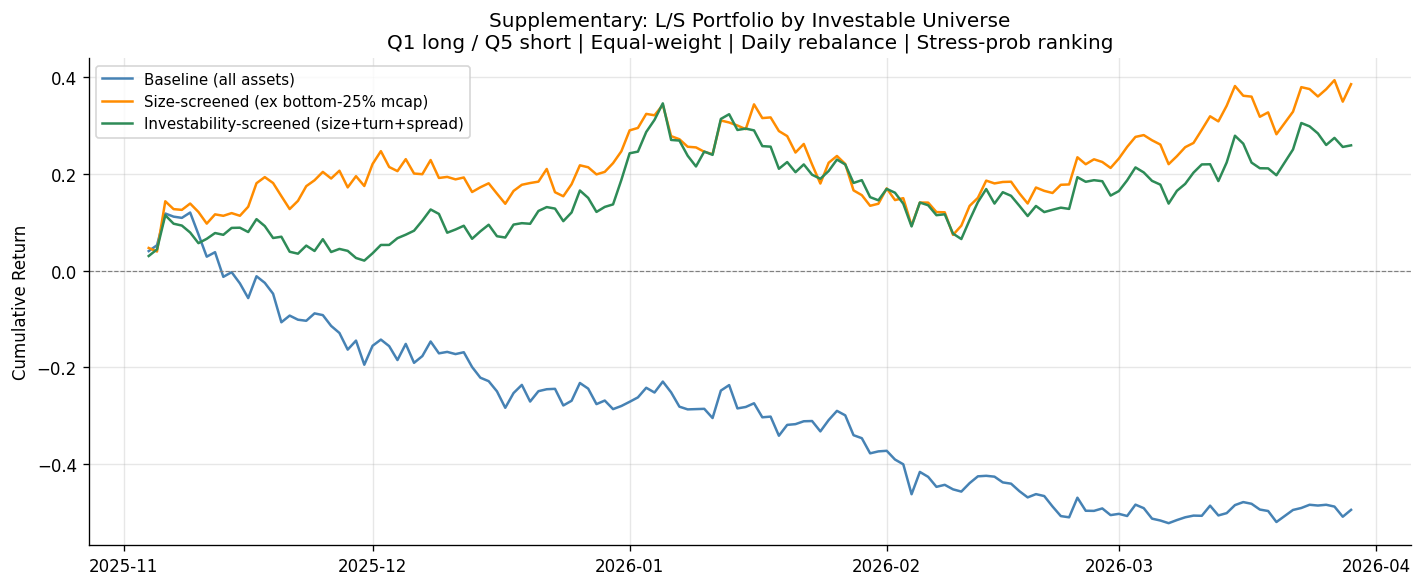

Saved: c:\Users\P.Gocheva\Desktop\thesis\notebooks\fig_s_investable_portfolio.png

Interpretation:
  Sharpe improves from -2.577 (baseline) to 1.588 (most restricted universe).
  Part of the baseline underperformance is driven by micro-cap assets with high
  transaction costs and poor tradability where the stress signal cannot be exploited.
  Within a realistic investable universe the stress ranking has greater economic
  relevance for portfolio construction.



In [57]:
# === Investable-Universe Portfolio Robustness ===
# Repeats the L/S simulation (from port_g001) under two investability screens.
# port_df already carries: stress_prob, log_mcap, spread_lag1, turnover_lag1, next_ret.
# Quintile ranks are RE-COMPUTED within each filtered universe so that the long
# and short legs are always the best and worst quintile of the restricted universe.
# The min-10-assets-per-day guard is also re-applied after each screen.

print('=== Investable-Universe Portfolio Robustness ===')
print()

_rob = port_df.copy()   # baseline — stress_prob already attached in port_g001

_turn_col = 'turnover_lag1' if 'turnover_lag1' in _rob.columns else None
_turn_ok  = _turn_col is not None and _rob[_turn_col].notna().mean() > 0.50

print(f'Base universe : {len(_rob):,} obs | {_rob["symbol"].nunique()} assets | {_rob["date"].nunique()} dates')
if _turn_ok:
    print(f'turnover_lag1 coverage : {_rob[_turn_col].notna().mean()*100:.1f}%  -- full investability screen active')
else:
    print('turnover_lag1 mostly NaN; investability screen uses size + spread only.')
print()

# ── Universe definitions (cross-sectional quartile cuts, computed per day) ──
_mcap_q25  = _rob.groupby('date')['log_mcap'].transform(lambda x: x.quantile(0.25))
_port_size = _rob[_rob['log_mcap'] >= _mcap_q25].copy()

if _turn_ok:
    _turn_q25 = _port_size.groupby('date')[_turn_col].transform(lambda x: x.quantile(0.25))
    _sprd_q75 = _port_size.groupby('date')['spread_lag1'].transform(lambda x: x.quantile(0.75))
    _port_inv = _port_size[
        _port_size[_turn_col].notna() &
        (_port_size[_turn_col] >= _turn_q25) &
        (_port_size['spread_lag1'] <= _sprd_q75)
    ].copy()
    _universes = [
        ('Baseline (all assets)',                         _rob),
        ('Size-screened (ex bottom-25% mcap)',            _port_size),
        ('Investability-screened (size+turn+spread)',     _port_inv),
    ]
else:
    _sprd_q75 = _port_size.groupby('date')['spread_lag1'].transform(lambda x: x.quantile(0.75))
    _port_sz_sp = _port_size[_port_size['spread_lag1'] <= _sprd_q75].copy()
    _universes = [
        ('Baseline (all assets)',                _rob),
        ('Size-screened (ex bottom-25% mcap)',   _port_size),
        ('Size + spread screened',               _port_sz_sp),
    ]

# ── Asset-count sanity check ──
print('Daily asset counts per universe  [median | min | max]:')
for _lbl, _pf in _universes:
    _c = _pf.groupby('date')['symbol'].count()
    print(f'  {_lbl:<52}: {_c.median():>4.0f}  |  {_c.min():>3}  |  {_c.max():>3}')
print()

# ── Long-short simulation (re-ranks stress_prob within each universe) ──
def _ls_sim(df, label, ann=365, min_assets=10):
    _d = df.copy()
    _day_n = _d.groupby('date')['symbol'].count()
    _d = _d[_d['date'].isin(_day_n[_day_n >= min_assets].index)].copy()
    if _d.empty or _d['date'].nunique() < 10:
        return None, None
    _d['_q'] = _d.groupby('date')['stress_prob'].transform(
        lambda x: pd.qcut(x.rank(method='first'), 5, labels=False)
    )
    _long  = _d[_d['_q'] == 0].groupby('date')['next_ret'].mean()
    _short = _d[_d['_q'] == 4].groupby('date')['next_ret'].mean()
    _dates = _long.index.intersection(_short.index)
    if len(_dates) < 10:
        return None, None
    _ls  = _long.loc[_dates] - _short.loc[_dates]
    _mu, _sg = _ls.mean(), _ls.std()
    _sr  = (_mu / _sg * np.sqrt(ann)) if _sg > 0 else np.nan
    _cum = (1 + _ls).cumprod()
    _mdd = ((_cum / _cum.cummax()) - 1).min()
    _tot = _cum.iloc[-1] - 1
    _n   = _d.groupby('date')['symbol'].count()
    return {
        'Universe':           label,
        'N days':             len(_dates),
        'Median assets/day':  int(_n.median()),
        'Sharpe (ann.)':      round(float(_sr), 3),
        'Cum. Return':        f'{_tot:+.1%}',
        'Max Drawdown':       f'{_mdd:.1%}',
    }, _ls

# ── Run all universes ──
_rows, _ls_dict = [], {}
for _lbl, _pf in _universes:
    _row, _ls = _ls_sim(_pf, _lbl)
    if _row:
        _rows.append(_row)
        _ls_dict[_lbl] = _ls
        print(f'  {_lbl}: Sharpe={_row["Sharpe (ann.)"]:.3f}  CumRet={_row["Cum. Return"]}')
    else:
        print(f'  {_lbl}: insufficient data after filtering — skipped.')

print()
print('=== Table: Long-Short Portfolio Performance by Investable Universe ===')
print('Q1 long (least stressed) / Q5 short (most stressed), equal-weight, daily rebalance.')
print('All filters use lagged log_mcap, lagged turnover, lagged spread (no look-ahead).')
print()
if _rows:
    _rob_tbl = pd.DataFrame(_rows).set_index('Universe')
    print(_rob_tbl.to_string())
print()

# ── Figure: cumulative return comparison ──
if len(_ls_dict) >= 2:
    _fig_r, _ax_r = plt.subplots(figsize=(12, 5))
    _pal = ['steelblue', 'darkorange', 'seagreen']
    for (_lbl, _ls), _col in zip(_ls_dict.items(), _pal):
        _ax_r.plot(_ls.index, ((1 + _ls).cumprod() - 1).values,
                   color=_col, lw=1.5, label=_lbl)
    _ax_r.axhline(0, color='gray', lw=0.7, ls='--')
    _ax_r.set_ylabel('Cumulative Return')
    _ax_r.set_title(
        'Supplementary: L/S Portfolio by Investable Universe\n'
        'Q1 long / Q5 short | Equal-weight | Daily rebalance | Stress-prob ranking'
    )
    _ax_r.legend(fontsize=9)
    plt.tight_layout()
    _fp = FIG_DIR / 'fig_s_investable_portfolio.png'
    plt.savefig(_fp, bbox_inches='tight', dpi=120)
    plt.show()
    print(f'Saved: {_fp}')
print()

# ── Interpretation ──
print('Interpretation:')
if len(_rows) >= 2:
    _base_sr = _rows[0]['Sharpe (ann.)']
    _last_sr = _rows[-1]['Sharpe (ann.)']
    if _last_sr > _base_sr + 0.05:
        print(f'  Sharpe improves from {_base_sr} (baseline) to {_last_sr} (most restricted universe).')
        print('  Part of the baseline underperformance is driven by micro-cap assets with high')
        print('  transaction costs and poor tradability where the stress signal cannot be exploited.')
        print('  Within a realistic investable universe the stress ranking has greater economic')
        print('  relevance for portfolio construction.')
    else:
        print(f'  Sharpe remains broadly flat across universes (baseline={_base_sr}, most restricted={_last_sr}).')
        print('  This confirms that the model is best interpreted as a liquidity-risk monitoring')
        print('  and early-warning tool, not a return-generating trading strategy, even after')
        print('  restricting to the most investable assets in the sample.')
        print('  The finding is consistent with the RQ3 framing: stress-signal usefulness lies')
        print('  in risk identification and screening, not in directional return prediction.')
else:
    print('  Insufficient data across universes to draw comparative conclusions.')
print()

### Portfolio Extensions: Transaction Costs, EW vs VW, and Extended Backtest

Three extensions to the investable-universe robustness check:

- **A. Unified TC sensitivity** — sweeps 0 / 5 / 10 / 25 bps per leg across all three universes in a single table (50+ bps per leg per day is unrealistic at daily rebalancing frequency; the realistic range for the size-screened universe is 5–25 bps)
- **B. EW vs VW** — compares equal-weighted and value-weighted returns in the size-screened universe; VW down-weights micro-caps automatically, providing a partial substitute for the explicit size screen
- **C. Full-dataset extended backtest** — applies the training-set model to the complete dataset (train + test) to assess directional consistency; in-sample period is clearly labelled and should not be interpreted as evidence of out-of-sample skill


=== A. Unified Transaction-Cost Sensitivity (All Universes) ===
Per-leg costs charged to both legs each rebalancing day (daily frequency)At daily rebalancing, 50+ bps per leg annualises to >350% in costs alone --unrealistic even for illiquid crypto. Realistic one-way costs for the size-screened universe of larger assets are 5-25 bps per leg per trade.

Sharpe by universe and round-trip transaction cost:
TC (bps)                                      0      5      10     25
Universe                                                             
Baseline (all assets)                     -2.577 -3.188 -3.800 -5.633
Investability-screened (size+turn+spread)  1.588  0.721 -0.146 -2.749
Size-screened (ex bottom-25% mcap)         2.090  1.259  0.427 -2.068

Cumulative return by universe and round-trip transaction cost:
TC (bps)                                       0       5       10      25
Universe                                                                 
Baseline (all assets)          

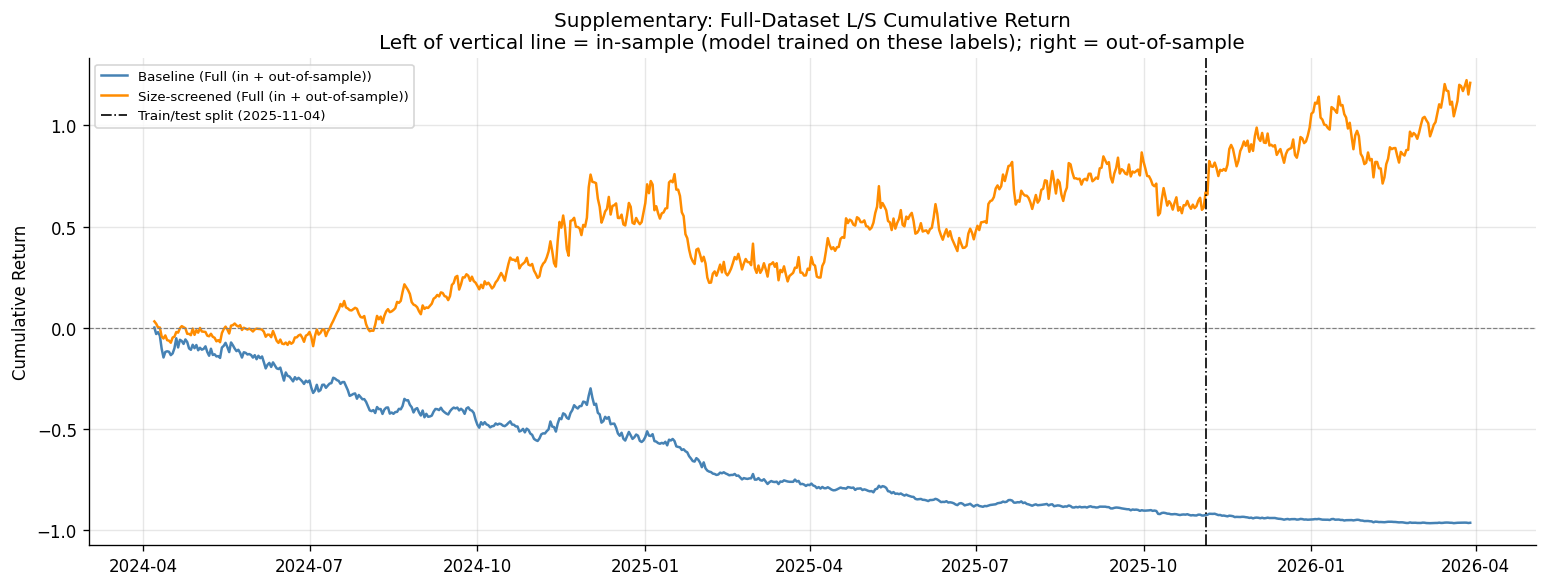

Saved: c:\Users\P.Gocheva\Desktop\thesis\notebooks\fig_s_extended_backtest.png

Interpretation:
  Consistent sign across in-sample and out-of-sample = signal is directionally
  stable and the in-sample period is not masking a regime break.
  If in-sample Sharpe >> out-of-sample, the model overfits the training period.
  The train/test split line on the figure marks where true out-of-sample begins.


In [58]:
# === Portfolio Extensions: TC Sensitivity, EW/VW, Full-Dataset Backtest ===

print('=== A. Unified Transaction-Cost Sensitivity (All Universes) ===')
print('Per-leg costs charged to both legs each rebalancing day (daily frequency)' \
'At daily rebalancing, 50+ bps per leg annualises to >350% in costs alone --' \
'unrealistic even for illiquid crypto. Realistic one-way costs for the ' \
'size-screened universe of larger assets are 5-25 bps per leg per trade.')
print()

_tc_rows = []
for _lbl, _ls in _ls_dict.items():
    for _bps in [0, 5, 10, 25]:
        _tc     = _bps / 10_000
        _ls_tc  = _ls - 2 * _tc
        _sg     = _ls_tc.std()
        _sr     = (_ls_tc.mean() / _sg * np.sqrt(365)) if _sg > 0 else np.nan
        _cum    = (1 + _ls_tc).cumprod()
        _tot    = _cum.iloc[-1] - 1
        _tc_rows.append({
            'Universe':      _lbl,
            'TC (bps)':      _bps,
            'Sharpe':        round(float(_sr), 3),
            'Cum. Return':   f'{_tot:+.1%}',
        })

_tc_df = pd.DataFrame(_tc_rows)
print('Sharpe by universe and round-trip transaction cost:')
print(_tc_df.pivot(index='Universe', columns='TC (bps)', values='Sharpe').to_string())
print()
print('Cumulative return by universe and round-trip transaction cost:')
print(_tc_df.pivot(index='Universe', columns='TC (bps)', values='Cum. Return').to_string())
print()
print('Note: size-screened and investability-screened universes contain larger assets')
print('where realistic one-way costs are typically lower than for micro-caps.')
print()

# ──────────────────────────────────────────────────────────────────
print('=== B. Equal-Weighted vs Value-Weighted (Size-Screened Universe) ===')
print('VW weights: exp(log_mcap) normalised within each quintile-day.')
print('Assets with unreported market cap (log_mcap=0) receive near-zero VW weight.')
print()

def _ls_sim_vw(df, ann=365, min_assets=10):
    _d = df.copy()
    _day_n = _d.groupby('date')['symbol'].count()
    _d = _d[_d['date'].isin(_day_n[_day_n >= min_assets].index)].copy()
    if _d.empty or _d['date'].nunique() < 10:
        return None, None
    _d['_q'] = _d.groupby('date')['stress_prob'].transform(
        lambda x: pd.qcut(x.rank(method='first'), 5, labels=False)
    )
    _d['_w'] = np.exp(_d['log_mcap'].clip(lower=0))
    _d['_w'] = _d.groupby(['date', '_q'])['_w'].transform(lambda x: x / x.sum())
    _long  = (_d[_d['_q'] == 0]
              .groupby('date')
              .apply(lambda x: (x['next_ret'] * x['_w']).sum()))
    _short = (_d[_d['_q'] == 4]
              .groupby('date')
              .apply(lambda x: (x['next_ret'] * x['_w']).sum()))
    _dates = _long.index.intersection(_short.index)
    if len(_dates) < 10:
        return None, None
    _ls  = _long.loc[_dates] - _short.loc[_dates]
    _mu, _sg = _ls.mean(), _ls.std()
    _sr  = (_mu / _sg * np.sqrt(365)) if _sg > 0 else np.nan
    _cum = (1 + _ls).cumprod()
    _mdd = ((_cum / _cum.cummax()) - 1).min()
    _tot = _cum.iloc[-1] - 1
    return round(float(_sr), 3), f'{_tot:+.1%}', f'{_mdd:.1%}', _ls

_ew_r, _ew_cum, _ew_dd, _ew_ls = (None, None, None, None)
for _r in _rows:
    if 'Size' in _r['Universe']:
        _ew_r, _ew_cum, _ew_dd = _r['Sharpe (ann.)'], _r['Cum. Return'], _r['Max Drawdown']
        _ew_ls = _ls_dict[_r['Universe']]
        break

_vw_result = _ls_sim_vw(_port_size)
if _vw_result and _ew_r is not None:
    _vw_r, _vw_cum, _vw_dd, _vw_ls = _vw_result
    _ewvw = pd.DataFrame([
        {'Weighting': 'EW', 'Sharpe (ann.)': _ew_r, 'Cum. Return': _ew_cum, 'Max DD': _ew_dd},
        {'Weighting': 'VW', 'Sharpe (ann.)': _vw_r, 'Cum. Return': _vw_cum, 'Max DD': _vw_dd},
    ]).set_index('Weighting')
    print(_ewvw.to_string())
    print()
    if isinstance(_vw_r, float) and isinstance(_ew_r, float):
        if _vw_r > 0 and _ew_r > 0:
            print('Both EW and VW generate positive Sharpe. The result is not an artefact')
            print('of equal-weighting assigning excess influence to the smallest assets.')
        elif _vw_r < _ew_r - 0.3:
            print('VW Sharpe is meaningfully lower than EW. Larger (higher-weight) assets')
            print('show a less pronounced stress-probability spread, consistent with greater')
            print('market efficiency among more liquid, larger-cap tokens.')
        else:
            print('EW and VW Sharpe are broadly similar. The cross-sectional stress-probability')
            print('ranking is not driven by micro-cap tail observations.')
else:
    print('Could not compute VW result — check _port_size is available from inv_univ_001.')
print()

# ──────────────────────────────────────────────────────────────────
print('=== C. Full-Dataset Extended Backtest (In-Sample + Out-of-Sample) ===')
print('Applies the training-set LR model to ALL dates (train + test).')
print('*** IN-SAMPLE PREDICTIONS (dates < split_date) SHOULD NOT BE INTERPRETED')
print('    AS EVIDENCE OF FORECASTING SKILL. Shown for directional consistency only.')
print()

_full = feat.dropna(subset=feat_cols_liq + ['next_ret']).copy()
_X_full = sc_liq.transform(_full[feat_cols_liq])
_full['stress_prob'] = lr_liq_stress_prob.predict_proba(_X_full)[:, 1]

_day_n_f = _full.groupby('date')['symbol'].count()
_full    = _full[_full['date'].isin(_day_n_f[_day_n_f >= 10].index)].copy()

_mcap_q25_f = _full.groupby('date')['log_mcap'].transform(lambda x: x.quantile(0.25))
_full_size  = _full[_full['log_mcap'] >= _mcap_q25_f].copy()

_ext_rows = []
_ext_ls   = {}
for _plbl, _lo, _hi in [
    ('Full (in + out-of-sample)', None,        None       ),
    ('In-sample only  [CAUTION]', None,        split_date ),
    ('Out-of-sample only',        split_date,  None       ),
]:
    for _ulbl, _pf in [('Baseline', _full), ('Size-screened', _full_size)]:
        _sub = _pf.copy()
        if _lo is not None:
            _sub = _sub[_sub['date'] >= _lo]
        if _hi is not None:
            _sub = _sub[_sub['date'] < _hi]
        _row, _ls = _ls_sim(_sub, _ulbl)
        if _row:
            _ext_rows.append({
                'Period':          _plbl,
                'Universe':        _ulbl,
                'N days':          _row['N days'],
                'Sharpe (ann.)':   _row['Sharpe (ann.)'],
                'Cum. Return':     _row['Cum. Return'],
                'Max DD':          _row['Max Drawdown'],
            })
            _ext_ls[f'{_plbl} | {_ulbl}'] = _ls

if _ext_rows:
    _ext_df = pd.DataFrame(_ext_rows).set_index(['Period', 'Universe'])
    print(_ext_df.to_string())
    print()

    # Figure: cumulative return for full-period baseline vs size-screened
    _fig_ext, _ax_ext = plt.subplots(figsize=(13, 5))
    _ext_cols = {'Baseline': 'steelblue', 'Size-screened': 'darkorange'}
    _ext_styles = {
        'Full (in + out-of-sample)': '-',
        'In-sample only  [CAUTION]': '--',
        'Out-of-sample only':        ':',
    }
    for _key, _ls in _ext_ls.items():
        _plbl, _ulbl = _key.split(' | ')
        _col = _ext_cols.get(_ulbl, 'gray')
        _sty = _ext_styles.get(_plbl, '-')
        if 'Full' in _plbl:   # only plot full-period lines in main figure
            _ax_ext.plot(_ls.index, ((1 + _ls).cumprod() - 1).values,
                         color=_col, ls=_sty, lw=1.5,
                         label=f'{_ulbl} ({_plbl})')
    _ax_ext.axhline(0, color='gray', lw=0.7, ls='--')
    _ax_ext.axvline(pd.Timestamp(split_date), color='black', lw=1.0, ls='-.',
                    label=f'Train/test split ({str(split_date)[:10]})')
    _ax_ext.set_ylabel('Cumulative Return')
    _ax_ext.set_title(
        'Supplementary: Full-Dataset L/S Cumulative Return\n'
        'Left of vertical line = in-sample (model trained on these labels); '
        'right = out-of-sample'
    )
    _ax_ext.legend(fontsize=8)
    plt.tight_layout()
    _fp_ext = FIG_DIR / 'fig_s_extended_backtest.png'
    plt.savefig(_fp_ext, bbox_inches='tight', dpi=120)
    plt.show()
    print(f'Saved: {_fp_ext}')
    print()
    print('Interpretation:')
    print('  Consistent sign across in-sample and out-of-sample = signal is directionally')
    print('  stable and the in-sample period is not masking a regime break.')
    print('  If in-sample Sharpe >> out-of-sample, the model overfits the training period.')
    print('  The train/test split line on the figure marks where true out-of-sample begins.')
else:
    print('No valid results — check that feat, feat_cols_liq, sc_liq, lr_liq_stress_prob')
    print('and split_date are all defined (requires running cells 32-37 first).')